## Project Summary

This project aimed to analyze factors influencing employee well-being, specifically focusing on burnout, work-life balance, social isolation, and thriving, based on a simulated 'Post-Pandemic Remote Work Health Impact 2025' dataset. The analysis addressed four key research questions (RQs) using various statistical and machine learning techniques.

### Data Preparation and Feature Engineering
The initial dataset was loaded and underwent significant feature engineering. This included:
- Type conversion for `Survey_Date`, numerical variables (`Age`, `Hours_Per_Week`), and categorical variables (e.g., `Gender`, `Region`).
- Creation of `Mental_Health_Flag` (binary indicator for any mental health condition).
- Derivation of `Burnout_Score` from the ordered `Burnout_Level` factor.
- Creation of `Physical_Issue_Flag` and `Physical_Issue_Count` from `Physical_Health_Issues`.
- Definition of a `Thriving` indicator based on `Burnout_Level`, `Work_Life_Balance_Score`, `Social_Isolation_Score`, and `Mental_Health_Status`.

The dataset was then transformed for modeling, including one-hot encoding for nominal variables, label encoding for ordinal variables, and standard scaling for numerical variables. Redundant features were dropped, and column names were cleaned. Finally, the data was split into 80% training and 20% testing sets.

### RQ 1: Which factors most strongly predict Burnout_Level?

**Methods:**
- **Feature Selection:** LASSO regression, Mutual Information (Information Gain), and Random Forest Variable Importance were used to identify key predictors of `Burnout_Score`.
- **Univariate Statistical Significance Tests:** Wilcoxon rank-sum tests for binary features and Spearman correlation for ordinal/numerical features were conducted against `Burnout_Score`.
- **Multivariate Statistical Significance Tests:** Ordinal Logistic Regression (`polr`) models were built using four different feature sets:
    1. LASSO-selected features
    2. Mutual Information-selected features
    3. Random Forest-selected features
    4. A combined set of all unique features from the above methods.

**Key Findings:**
- All four ordinal logistic regression models showed consistent and statistically significant predictors for `Burnout_Score`.
- The Brant test confirmed that the parallel regression assumption held for all models, indicating the appropriateness of the ordinal logistic regression.
- `Work_Arrangement_Onsite` consistently showed a significant negative association with burnout, meaning onsite workers had lower odds of being in a higher burnout category.
- `Work_Arrangement_Remote` consistently showed a significant positive association, indicating higher odds of burnout for remote workers.
- `Job_Role_Account_Manager` was found to reduce the odds of higher burnout.
- `Work_Life_Balance_Score` and `Salary_Range` showed small protective effects against higher burnout.
- `Social_Isolation_Score` and `Gender_Female` were associated with slightly higher odds of burnout.
- Model performance, measured by Accuracy and Kappa, was generally moderate, suggesting that while the identified factors are influential, other variables might also play a role.

### RQ 2: Which features identify employees at risk of burnout?

**Methods:**
- A binary `Burnout_Risk` variable was created (High Burnout = AtRisk, Low/Medium Burnout = NotAtRisk).
- Exploratory Data Analysis (EDA) was performed using group summaries and box plots to visualize differences between `AtRisk` and `NotAtRisk` groups for numerical variables (`Hours_Per_Week`, `Work_Life_Balance_Score`, `Social_Isolation_Score`, `Physical_Issue_Count`).
- Wilcoxon rank-sum tests were conducted to assess the statistical significance of these differences.
- Chi-square tests were used to examine the association between `Work_Arrangement` and `Burnout_Risk`.
- An ordinal logistic regression model was built to predict `Burnout_Level` based on key variables, and odds ratios were interpreted.

**Key Findings:**
- Employees at risk of high burnout reported significantly higher `Hours_Per_Week`, lower `Work_Life_Balance_Score`, higher `Social_Isolation_Score`, and more `Physical_Issue_Count`.
- `Work_Arrangement` was highly significantly associated with burnout risk. Remote workers showed a higher proportion of being 'AtRisk' compared to onsite workers.
- The ordinal logistic regression confirmed that `Hours_Per_Week`, `Work_Life_Balance_Score`, `Social_Isolation_Score`, `Physical_Issue_Count`, and `Work_Arrangement` are significant predictors of `Burnout_Level`.

### RQ 3: Does work arrangement influence work life balance and social isolation?

**Methods:**
- EDA using bar plots and box plots to visualize the distributions of `Social_Isolation_Score` and `Work_Life_Balance_Score` across different `Work_Arrangement` categories.
- **Kruskal–Wallis tests** were performed to determine if there were significant differences in `Work_Life_Balance_Score` and `Social_Isolation_Score` means across work arrangements.
- **Dunn Post-Hoc Test** was used following the Kruskal–Wallis test for `Social_Isolation_Score` to identify specific group differences.
- **Ordinal Logistic Regression** (`polr`) models were built to predict `Social_Isolation_Score` based on `Work_Arrangement`, and then with additional predictors (`Age`, `Gender`, `Hours_Per_Week`) for a multivariable analysis.

**Key Findings:**
- Kruskal–Wallis tests indicated significant differences in both `Work_Life_Balance_Score` and `Social_Isolation_Score` across `Work_Arrangement` categories.
- The Dunn test revealed specific differences in social isolation: Remote workers had significantly higher social isolation scores than both Hybrid and Onsite workers, and Hybrid workers had significantly higher scores than Onsite workers.
- Ordinal logistic regression confirmed that `Work_Arrangement` significantly predicted `Social_Isolation_Score`. Remote work increased the odds of higher social isolation, while onsite work decreased it.
- The multivariable model (including `Age`, `Gender`, `Hours_Per_Week`) further refined these relationships, showing that even after controlling for other factors, work arrangement remained a strong predictor of social isolation.

### RQ 4: Does the optimal number of working hours for job satisfaction differ by burnout level?

**Methods:**
- `Job_Satisfaction` was proxied by `Work_Life_Balance_Score`.
- A quadratic term (`Hours_Sq`) for `Hours_Per_Week` was introduced to capture non-linear relationships.
- Linear regression models were used to analyze:
    - `Job_Satisfaction` vs. `Hours_Per_Week` (with quadratic term).
    - `Job_Satisfaction` vs. `Hours_Per_Week` interacting with `Burnout_Level` (including quadratic interaction).
    - `Job_Satisfaction` vs. `Hours_Per_Week` interacting with `Work_Arrangement` (including quadratic interaction).
- Visualizations (scatter plots with smoothed lines) were used to illustrate the relationships.

**Key Findings:**
- The overall relationship between `Hours_Per_Week` and `Job_Satisfaction` (when ignoring burnout) showed a slight negative trend, but it masked important nuances.
- When considering `Burnout_Level`, the relationship significantly differed:
    - For employees with **Low Burnout**, job satisfaction remained relatively high even with increasing hours, showing a more resilient pattern.
    - For employees with **Medium** and **High Burnout**, job satisfaction decreased more sharply as hours increased, indicating that high work hours are detrimental to their satisfaction.
- This suggests that the 'optimal' number of working hours for job satisfaction is highly dependent on an individual's burnout level, with low-burnout individuals being more resilient to longer hours.

### RQ 5: Which factors predict whether employees thrive?

**Methods:**
- A binary `Thriving_bin` variable was created (Thriving = 1, NotThriving = 0).
- Two logistic regression models were built:
    - **Model A:** Used internal well-being factors (`Burnout_Score`, `Work_Life_Balance_Score`, `Social_Isolation_Score`, `Mental_Health_Flag`, `Hours_Per_Week`, `Age`, `Work_Arrangement`).
    - **Model B:** Used demographic and job context factors (`Age`, `Hours_Per_Week`, `Job_Role`, `Industry`, `Work_Arrangement`, `Gender`, `Region`, `Salary_Range`, `Physical_Issue_Count`).
- Both models were evaluated using confusion matrices, accuracy, Kappa, and ROC AUC.
- For Model B, a class-weighted logistic regression was also attempted due to class imbalance.

**Key Findings:**
- **Model A (Internal Well-being Factors):** Performed exceptionally well in predicting thriving. This was expected, as the `Thriving` variable was engineered directly from these same well-being metrics. This model primarily validated the internal consistency of the `Thriving` definition rather than providing external predictors.
- **Model B (Demographic and Job Context Factors):** Showed poor predictive performance for thriving. The AUC was only slightly better than random chance (around 0.56-0.58), and accuracy was low, especially for the 'Thriving' class.
- The weighted logistic regression for Model B also struggled to accurately identify thriving employees.
- This indicates that `Thriving` is not easily predictable from demographic and job-role variables alone. Instead, factors directly related to work-life balance, burnout, and social isolation are the most influential predictors, reinforcing the importance of addressing these core well-being aspects.

# Importing Data

In [ ]:
## load data
data <- read.csv("post_pandemic_remote_work_health_impact_2025.csv",
                 stringsAsFactors = FALSE)

# structure check
str(data)
summary(data)


'data.frame':	3157 obs. of  14 variables:
 $ Survey_Date            : chr  "2025-06-01" "2025-06-01" "2025-06-01" "2025-06-01" ...
 $ Age                    : int  27 37 32 40 30 52 50 63 30 37 ...
 $ Gender                 : chr  "Female" "Female" "Female" "Female" ...
 $ Region                 : chr  "Asia" "Asia" "Africa" "Europe" ...
 $ Industry               : chr  "Professional Services" "Professional Services" "Education" "Education" ...
 $ Job_Role               : chr  "Data Analyst" "Data Analyst" "Business Analyst" "Data Analyst" ...
 $ Work_Arrangement       : chr  "Onsite" "Onsite" "Onsite" "Onsite" ...
 $ Hours_Per_Week         : int  64 37 36 63 65 61 62 55 47 55 ...
 $ Mental_Health_Status   : chr  "Stress Disorder" "Stress Disorder" "ADHD" "ADHD" ...
 $ Burnout_Level          : chr  "High" "High" "High" "Medium" ...
 $ Work_Life_Balance_Score: int  3 4 3 1 5 4 4 3 2 5 ...
 $ Physical_Health_Issues : chr  "Shoulder Pain; Neck Pain" "Back Pain" "Shoulder Pain; Eye Strain"

 Survey_Date             Age           Gender             Region         
 Length:3157        Min.   :22.00   Length:3157        Length:3157       
 Class :character   1st Qu.:33.00   Class :character   Class :character  
 Mode  :character   Median :44.00   Mode  :character   Mode  :character  
                    Mean   :43.73                                        
                    3rd Qu.:55.00                                        
                    Max.   :65.00                                        
   Industry           Job_Role         Work_Arrangement   Hours_Per_Week
 Length:3157        Length:3157        Length:3157        Min.   :35.0  
 Class :character   Class :character   Class :character   1st Qu.:42.0  
 Mode  :character   Mode  :character   Mode  :character   Median :50.0  
                                                          Mean   :49.9  
                                                          3rd Qu.:57.0  
                                            

# Feature Engineering

In [ ]:
## Type conversion


data$Survey_Date <- as.Date(data$Survey_Date)


data$Age            <- as.numeric(data$Age)
data$Hours_Per_Week <- as.numeric(data$Hours_Per_Week)


data$Gender           <- factor(data$Gender)
data$Region           <- factor(data$Region)
data$Industry         <- factor(data$Industry)
data$Job_Role         <- factor(data$Job_Role)
data$Work_Arrangement <- factor(data$Work_Arrangement)
data$Mental_Health_Status <- factor(data$Mental_Health_Status)
data$Salary_Range     <- factor(data$Salary_Range)

data$Burnout_Level <- factor(
  data$Burnout_Level,
  levels  = c("Low", "Medium", "High"),
  ordered = TRUE
)

data$Work_Life_Balance_Score <- as.integer(data$Work_Life_Balance_Score)
data$Social_Isolation_Score  <- as.integer(data$Social_Isolation_Score)


In [ ]:
## Engineered variables
#Indicator for any mental health condition
data$Mental_Health_Flag <- ifelse(data$Mental_Health_Status == "None", 0, 1)
data$Mental_Health_Flag <- factor(data$Mental_Health_Flag,
                                  levels = c(0, 1),
                                  labels = c("NoCondition", "HasCondition"))


In [ ]:
# Numeric burnout score derived from ordered factor
data$Burnout_Score <- as.numeric(data$Burnout_Level)



In [ ]:
#Physical health indicators


clean_string <- function(x) {
  x <- ifelse(is.na(x), "", x)
  tolower(trimws(x))
}


data$Physical_Issue_Flag <- ifelse(
  clean_string(data$Physical_Health_Issues) %in% c("", "none", "no issues"),
  0, 1
)
data$Physical_Issue_Flag <- factor(data$Physical_Issue_Flag,
                                   levels = c(0, 1),
                                   labels = c("NoIssue", "HasIssue"))


count_issues <- function(x) {
  x_clean <- clean_string(x)
  if (x_clean == "" || x_clean == "none" || x_clean == "no issues") {
    return(0L)
  } else {

    return(length(strsplit(x_clean, ";")[[1]]))
  }
}

data$Physical_Issue_Count <- vapply(
  data$Physical_Health_Issues,
  count_issues,
  FUN.VALUE = integer(1)
)


In [ ]:
# Thriving definition

non_severe_conditions <- c("None", "Mild Anxiety", "Mild Stress", "Minor Stress")

data$Thriving <- ifelse(
  (data$Burnout_Level %in% c("Low", "Medium")) &
  (data$Work_Life_Balance_Score >= 3) &
  (data$Social_Isolation_Score <= 3) &
  (data$Mental_Health_Status %in% non_severe_conditions),
  1, 0
)

data$Thriving <- factor(data$Thriving,
                        levels = c(0, 1),
                        labels = c("NotThriving", "Thriving"))



In [ ]:
## Sanity checks

str(data)
table(data$Mental_Health_Flag)
table(data$Physical_Issue_Flag)
table(data$Overworked_Flag)
table(data$Thriving)
summary(data[, c("Age", "Hours_Per_Week",
                 "Burnout_Score", "Work_Life_Balance_Score",
                 "Social_Isolation_Score", "Physical_Issue_Count")])


'data.frame':	3157 obs. of  19 variables:
 $ Survey_Date            : Date, format: "2025-06-01" "2025-06-01" ...
 $ Age                    : num  27 37 32 40 30 52 50 63 30 37 ...
 $ Gender                 : Factor w/ 4 levels "Female","Male",..: 1 1 1 1 2 2 1 3 1 1 ...
 $ Region                 : Factor w/ 6 levels "Africa","Asia",..: 2 2 1 3 6 5 2 3 6 2 ...
 $ Industry               : Factor w/ 9 levels "Customer Service",..: 7 7 2 2 5 1 5 7 9 3 ...
 $ Job_Role               : Factor w/ 24 levels "Account Manager",..: 6 6 2 6 8 2 13 23 22 12 ...
 $ Work_Arrangement       : Factor w/ 3 levels "Hybrid","Onsite",..: 2 2 2 2 1 2 2 2 3 2 ...
 $ Hours_Per_Week         : num  64 37 36 63 65 61 62 55 47 55 ...
 $ Mental_Health_Status   : Factor w/ 7 levels "ADHD","Anxiety",..: 7 7 1 1 5 3 5 2 2 3 ...
 $ Burnout_Level          : Ord.factor w/ 3 levels "Low"<"Medium"<..: 3 3 3 2 2 2 2 3 2 2 ...
 $ Work_Life_Balance_Score: int  3 4 3 1 5 4 4 3 2 5 ...
 $ Physical_Health_Issues : chr  "Shoulder


 NoCondition HasCondition 
         799         2358 


 NoIssue HasIssue 
     280     2877 

< table of extent 0 >


NotThriving    Thriving 
       2885         272 

      Age        Hours_Per_Week Burnout_Score   Work_Life_Balance_Score
 Min.   :22.00   Min.   :35.0   Min.   :1.000   Min.   :1.000          
 1st Qu.:33.00   1st Qu.:42.0   1st Qu.:2.000   1st Qu.:2.000          
 Median :44.00   Median :50.0   Median :2.000   Median :3.000          
 Mean   :43.73   Mean   :49.9   Mean   :2.095   Mean   :2.997          
 3rd Qu.:55.00   3rd Qu.:57.0   3rd Qu.:3.000   3rd Qu.:4.000          
 Max.   :65.00   Max.   :65.0   Max.   :3.000   Max.   :5.000          
 Social_Isolation_Score Physical_Issue_Count
 Min.   :1.000          Min.   :0.000       
 1st Qu.:2.000          1st Qu.:1.000       
 Median :3.000          Median :2.000       
 Mean   :2.705          Mean   :1.881       
 3rd Qu.:4.000          3rd Qu.:3.000       
 Max.   :5.000          Max.   :5.000       

# EDA

In [ ]:

#BASIC STRUCTURE & SUMMARY
str(data)
summary(data)

# Check missing values
colSums(is.na(data))


'data.frame':	3157 obs. of  19 variables:
 $ Survey_Date            : Date, format: "2025-06-01" "2025-06-01" ...
 $ Age                    : num  27 37 32 40 30 52 50 63 30 37 ...
 $ Gender                 : Factor w/ 4 levels "Female","Male",..: 1 1 1 1 2 2 1 3 1 1 ...
 $ Region                 : Factor w/ 6 levels "Africa","Asia",..: 2 2 1 3 6 5 2 3 6 2 ...
 $ Industry               : Factor w/ 9 levels "Customer Service",..: 7 7 2 2 5 1 5 7 9 3 ...
 $ Job_Role               : Factor w/ 24 levels "Account Manager",..: 6 6 2 6 8 2 13 23 22 12 ...
 $ Work_Arrangement       : Factor w/ 3 levels "Hybrid","Onsite",..: 2 2 2 2 1 2 2 2 3 2 ...
 $ Hours_Per_Week         : num  64 37 36 63 65 61 62 55 47 55 ...
 $ Mental_Health_Status   : Factor w/ 7 levels "ADHD","Anxiety",..: 7 7 1 1 5 3 5 2 2 3 ...
 $ Burnout_Level          : Ord.factor w/ 3 levels "Low"<"Medium"<..: 3 3 3 2 2 2 2 3 2 2 ...
 $ Work_Life_Balance_Score: int  3 4 3 1 5 4 4 3 2 5 ...
 $ Physical_Health_Issues : chr  "Shoulder

  Survey_Date              Age                      Gender    
 Min.   :2025-06-01   Min.   :22.00   Female           :1500  
 1st Qu.:2025-06-07   1st Qu.:33.00   Male             :1535  
 Median :2025-06-14   Median :44.00   Non-binary       :  90  
 Mean   :2025-06-13   Mean   :43.73   Prefer not to say:  32  
 3rd Qu.:2025-06-20   3rd Qu.:55.00                           
 Max.   :2025-06-26   Max.   :65.00                           
                                                              
           Region                     Industry  
 Africa       :532   Professional Services:730  
 Asia         :517   Technology           :593  
 Europe       :513   Manufacturing        :370  
 North America:497   Finance              :367  
 Oceania      :523   Education            :287  
 South America:575   Healthcare           :247  
                     (Other)              :563  
                     Job_Role    Work_Arrangement Hours_Per_Week
 Research Scientist      : 151   Hybrid

Survey_Date                     Age                  Gender 
                      0                       0                       0 
                 Region                Industry                Job_Role 
                      0                       0                       0 
       Work_Arrangement          Hours_Per_Week    Mental_Health_Status 
                      0                       0                       0 
          Burnout_Level Work_Life_Balance_Score  Physical_Health_Issues 
                      0                       0                       0 
 Social_Isolation_Score            Salary_Range      Mental_Health_Flag 
                      0                       0                       0 
          Burnout_Score     Physical_Issue_Flag    Physical_Issue_Count 
                      0                       0                       0 
               Thriving 
                      0

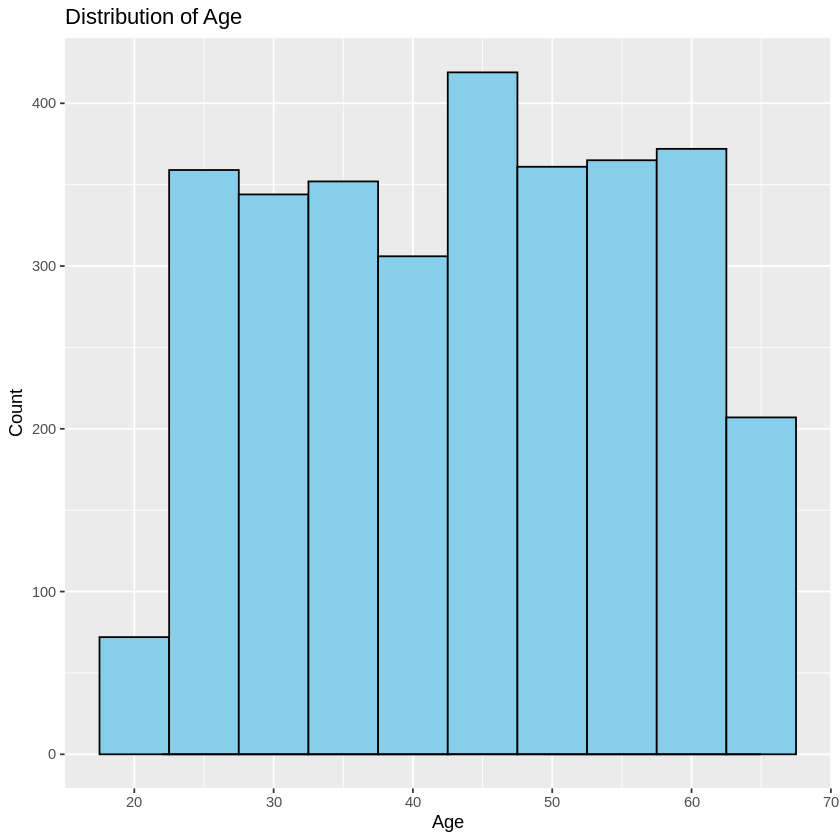

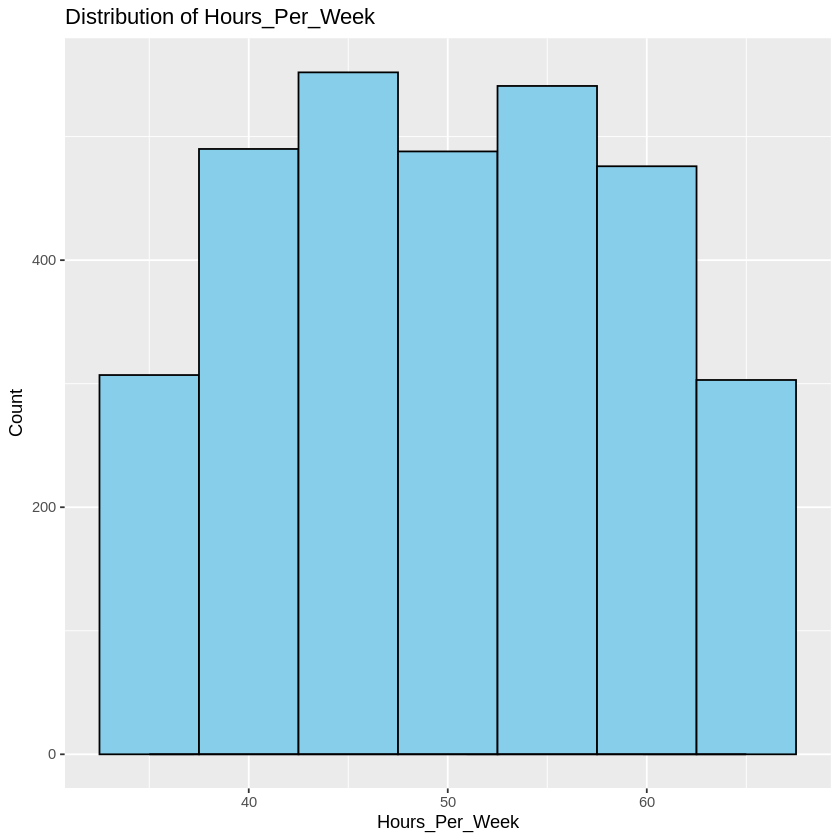

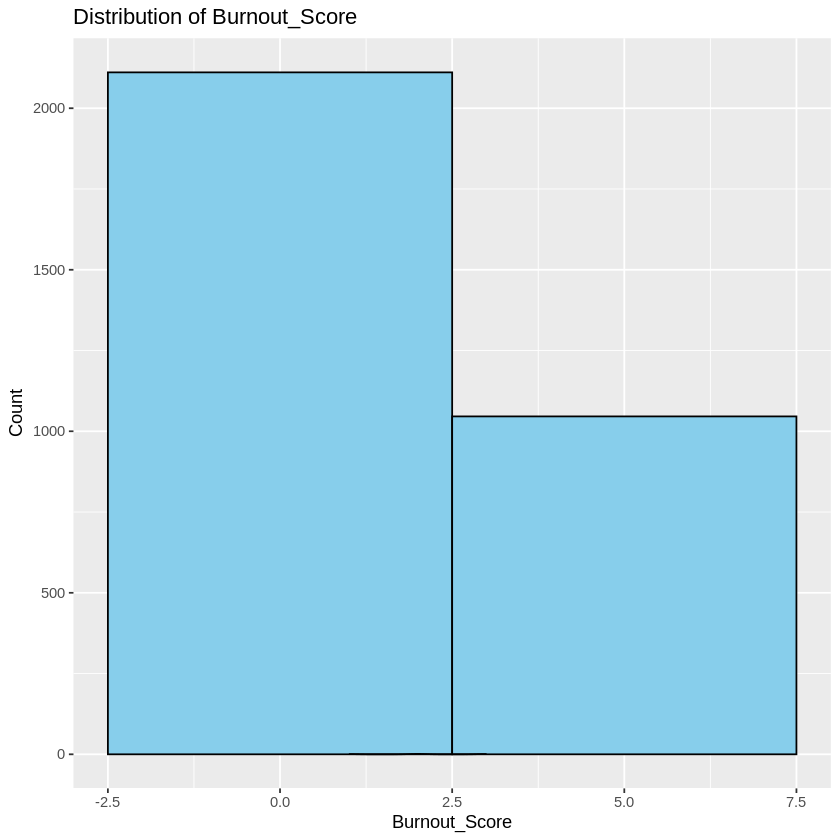

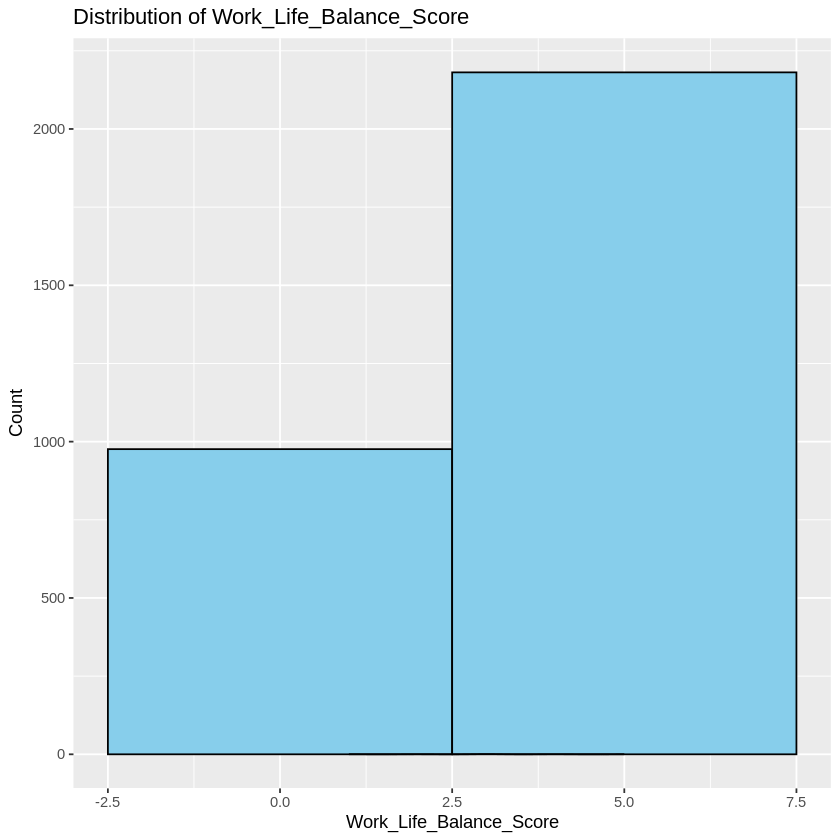

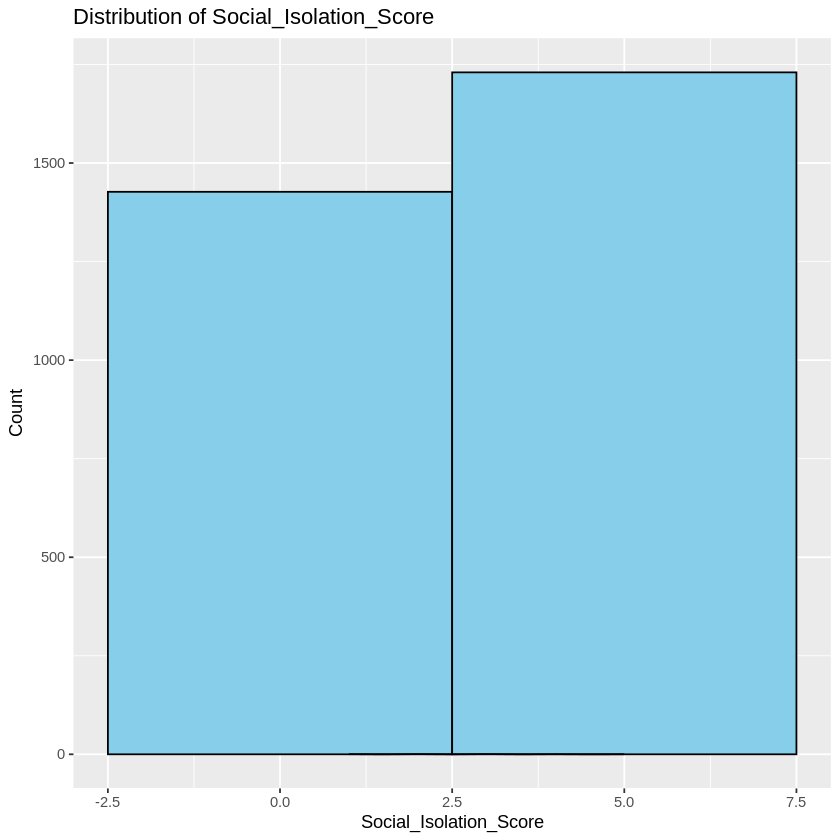

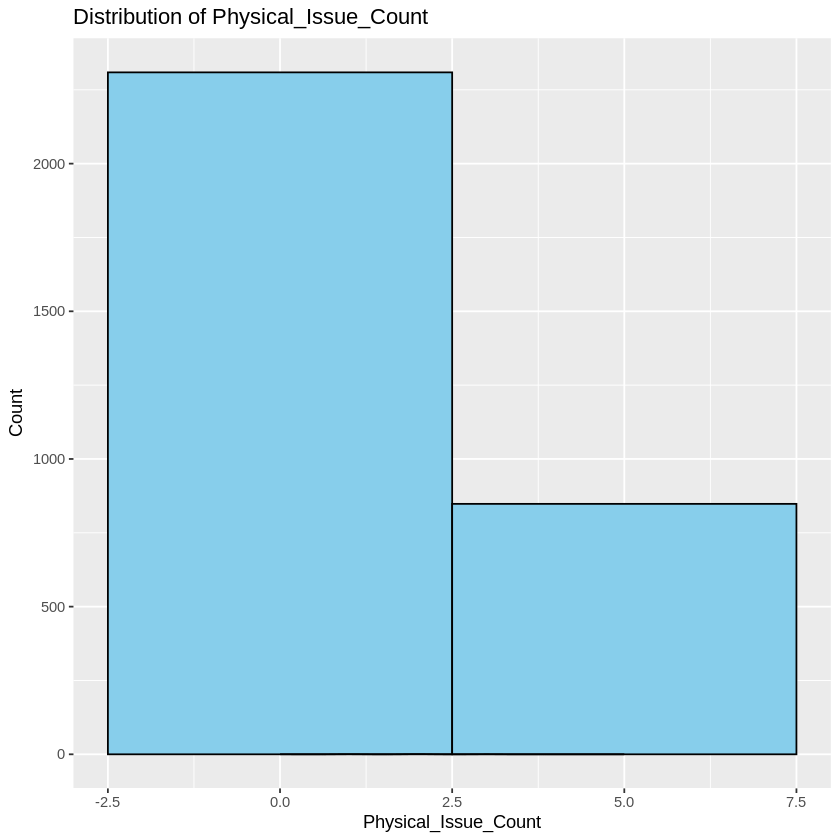

In [ ]:

#NUMERICAL DISTRIBUTIONS
numeric_vars <- c("Age", "Hours_Per_Week",
                  "Burnout_Score",
                  "Work_Life_Balance_Score",
                  "Social_Isolation_Score",
                  "Physical_Issue_Count")

library(ggplot2)

for (v in numeric_vars) {
  print(
    ggplot(data, aes_string(x = v)) +
      geom_histogram(binwidth = 5, color = "black", fill = "skyblue") +
      geom_density(alpha = 0.3, fill = "orange") +
      labs(title = paste("Distribution of", v),
           x = v, y = "Count")
  )
}


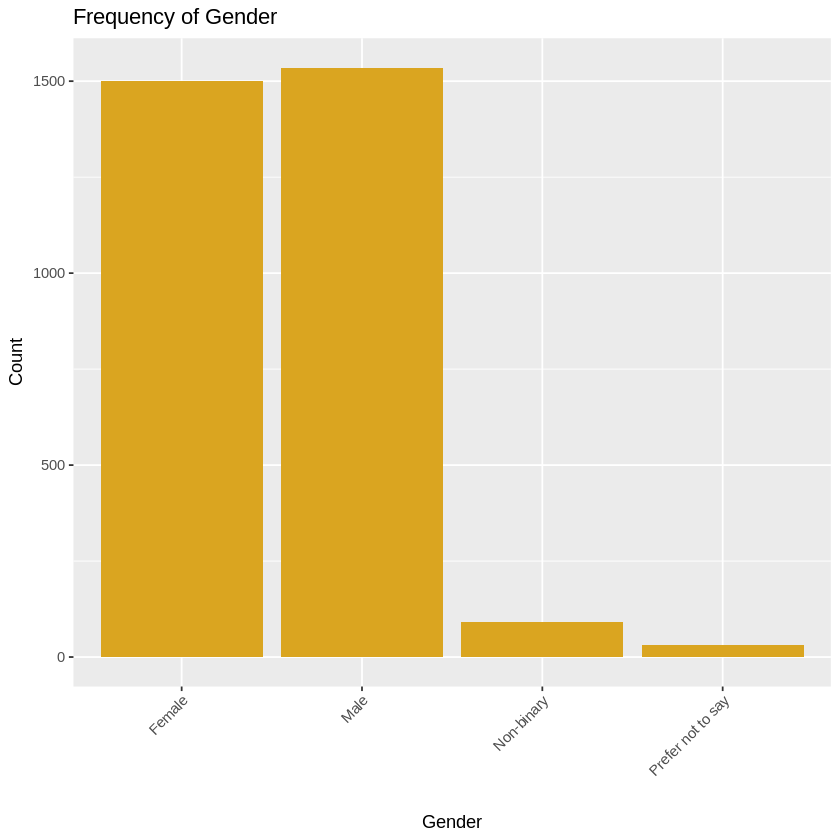

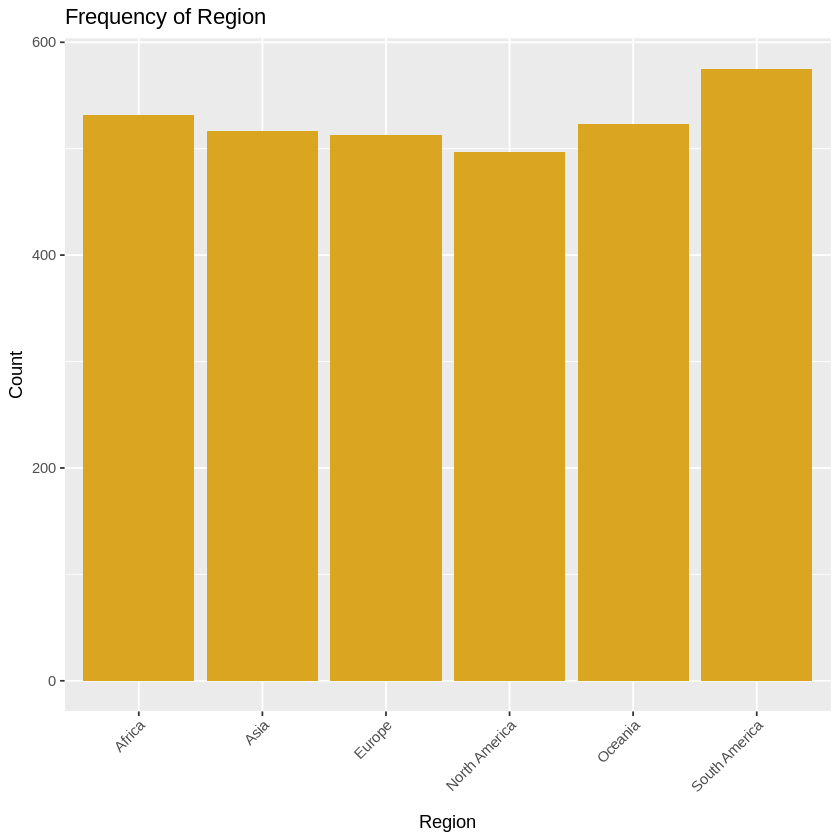

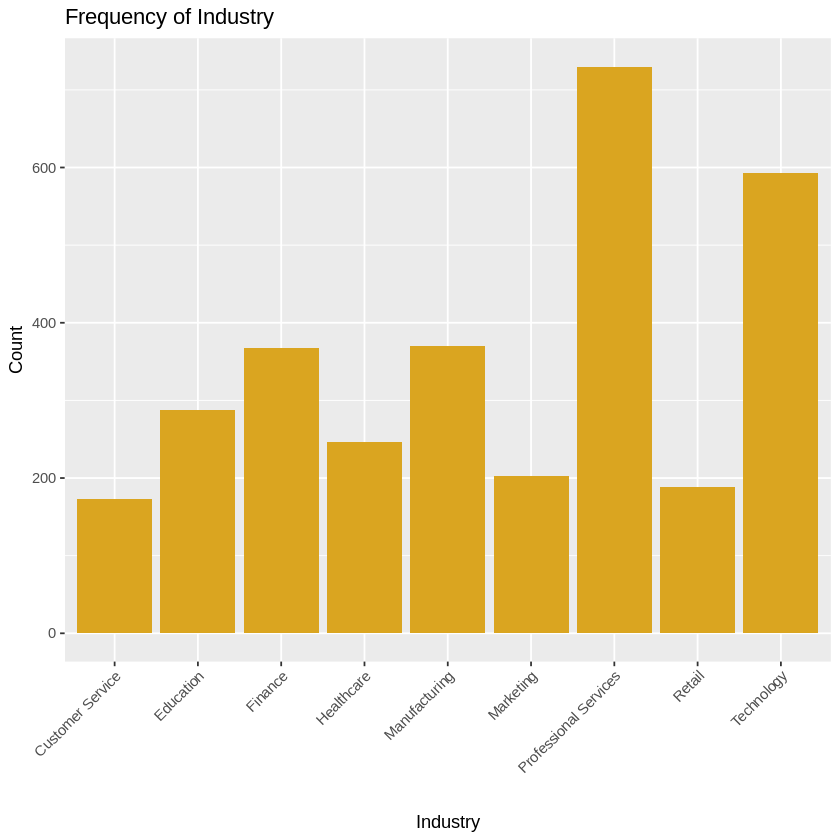

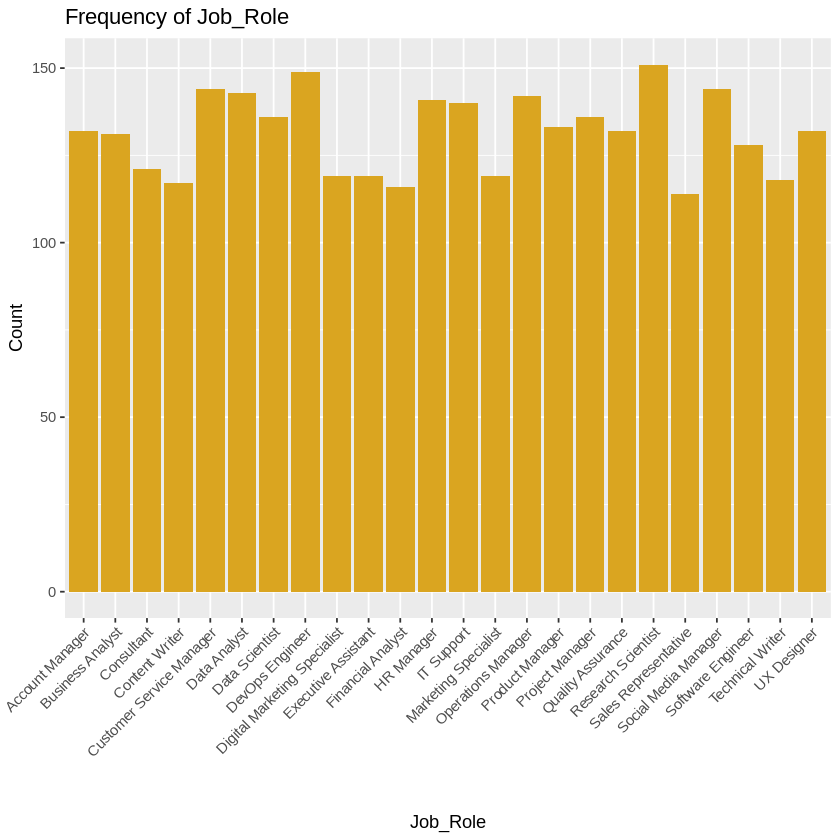

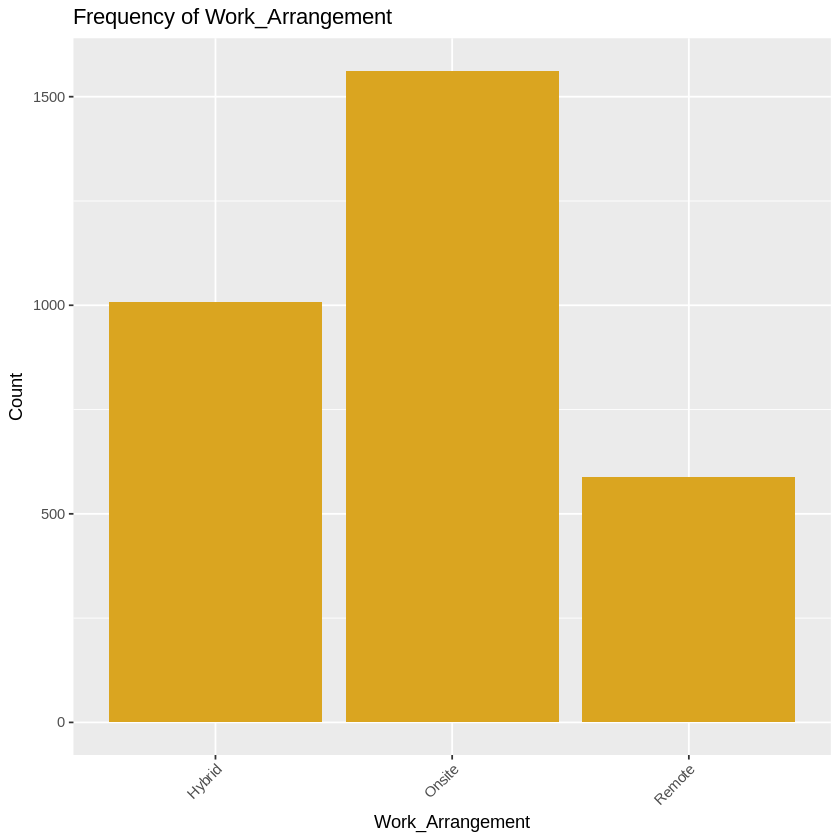

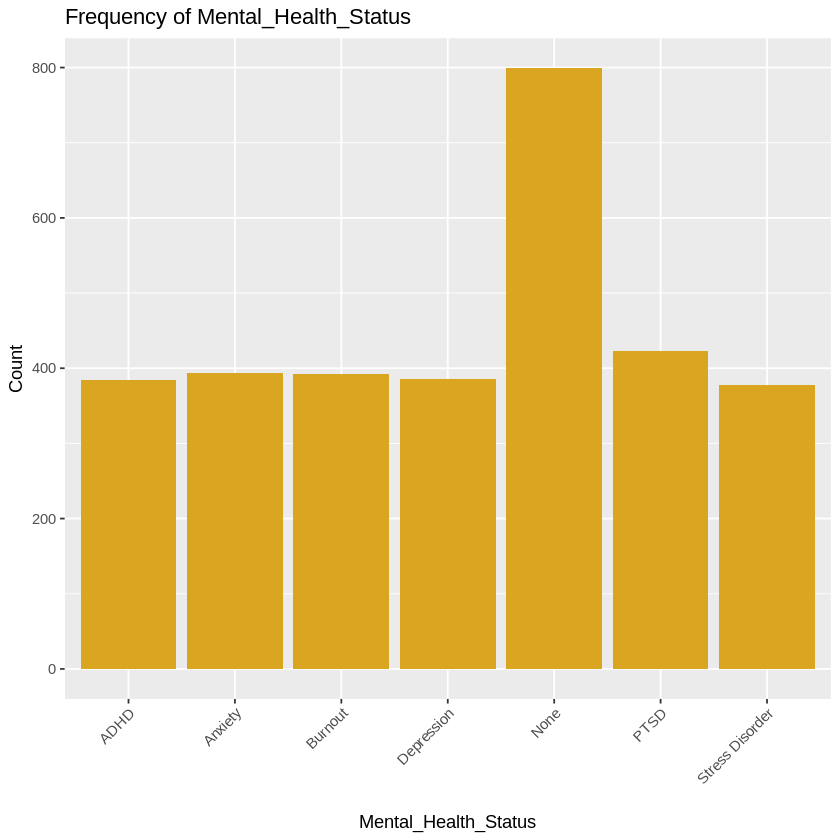

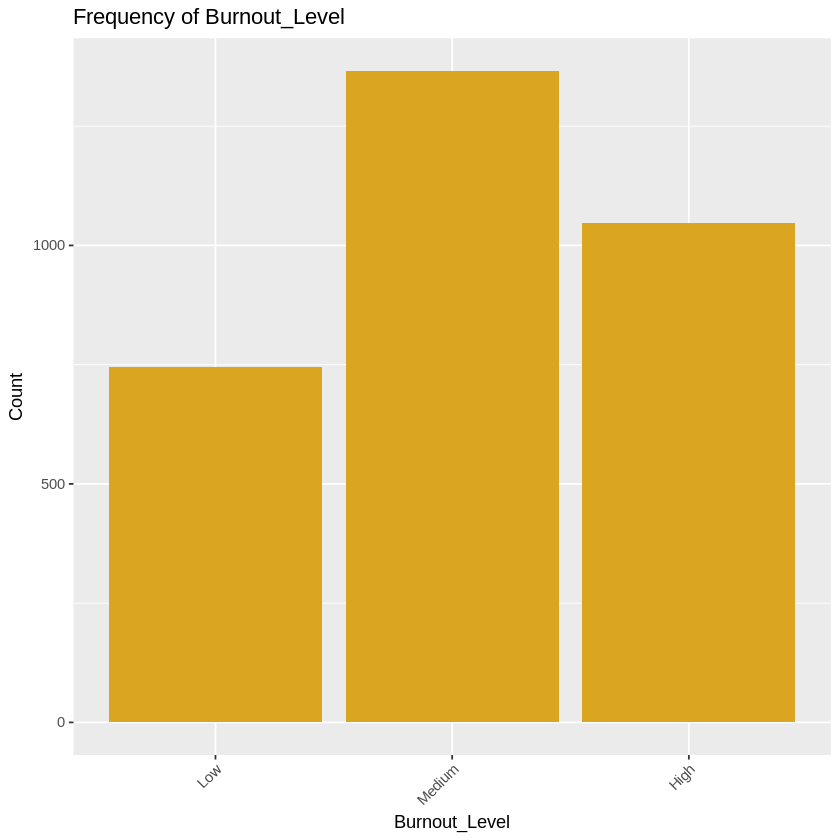

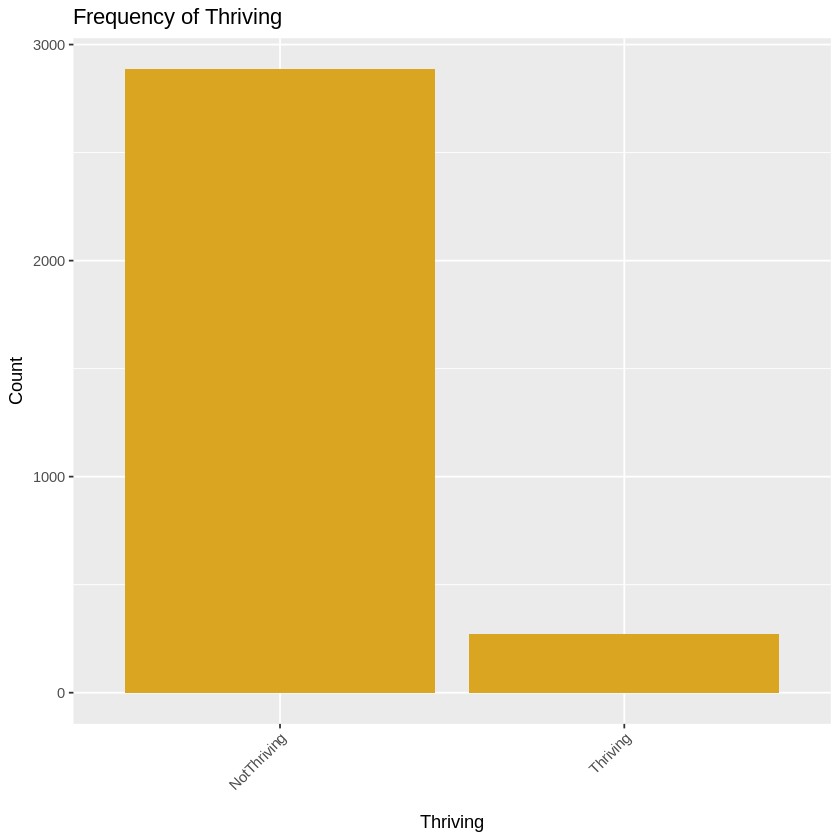

In [ ]:
#CATEGORICAL DISTRIBUTIONS

cat_vars <- c("Gender", "Region", "Industry",
              "Job_Role", "Work_Arrangement",
              "Mental_Health_Status",
              "Burnout_Level", "Thriving")

for (v in cat_vars) {
  print(
    ggplot(data, aes_string(x = v)) +
      geom_bar(fill = "goldenrod") +
      labs(title = paste("Frequency of", v), x = v, y = "Count") +
      theme(axis.text.x = element_text(angle = 45, hjust = 1))
  )
}


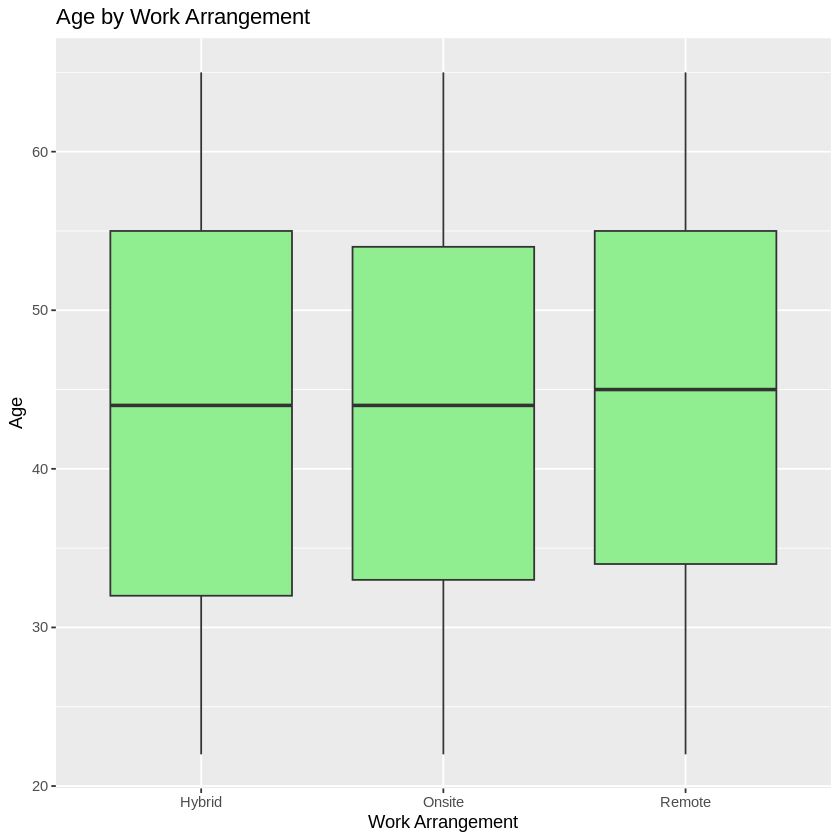

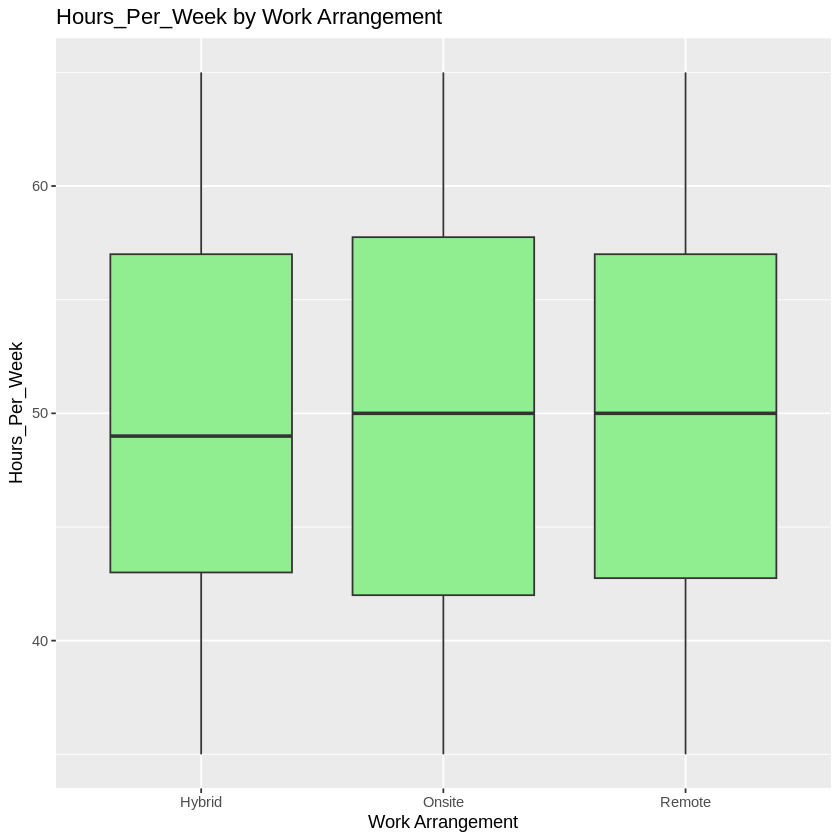

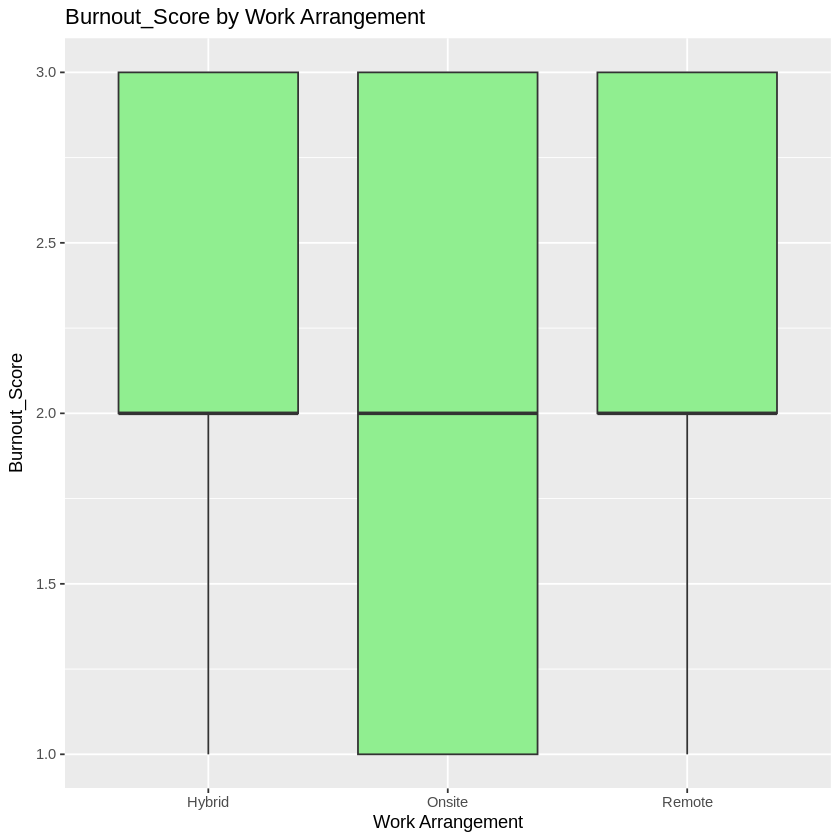

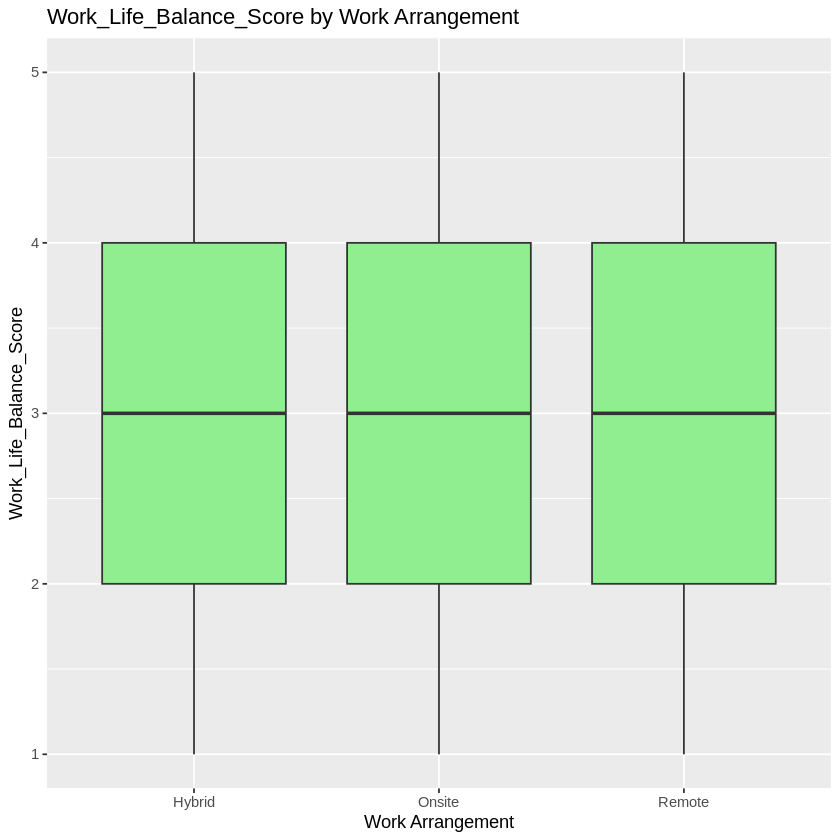

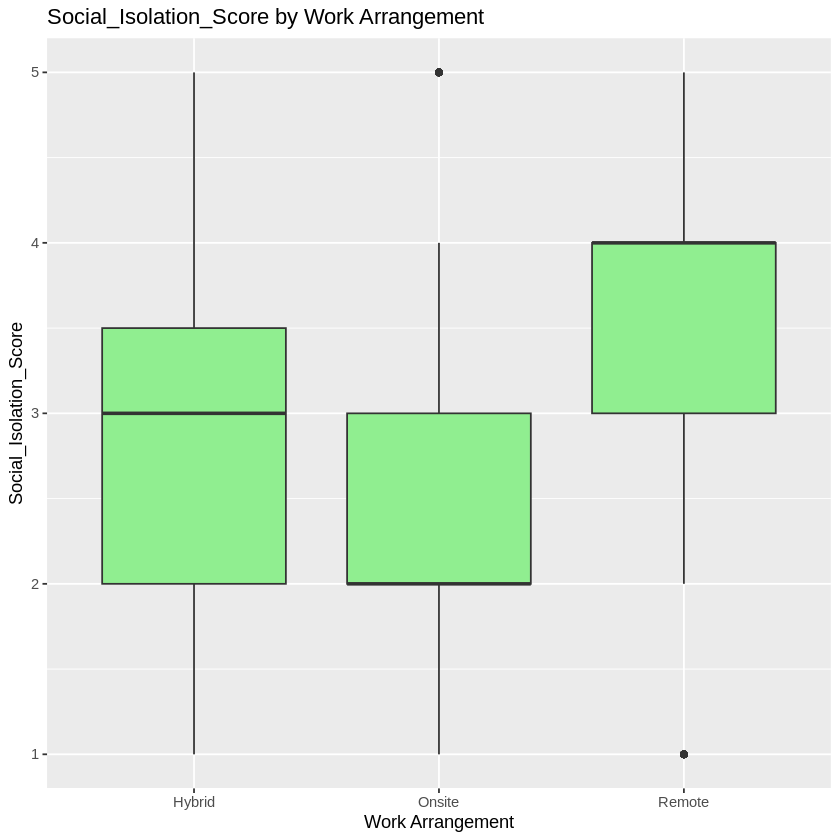

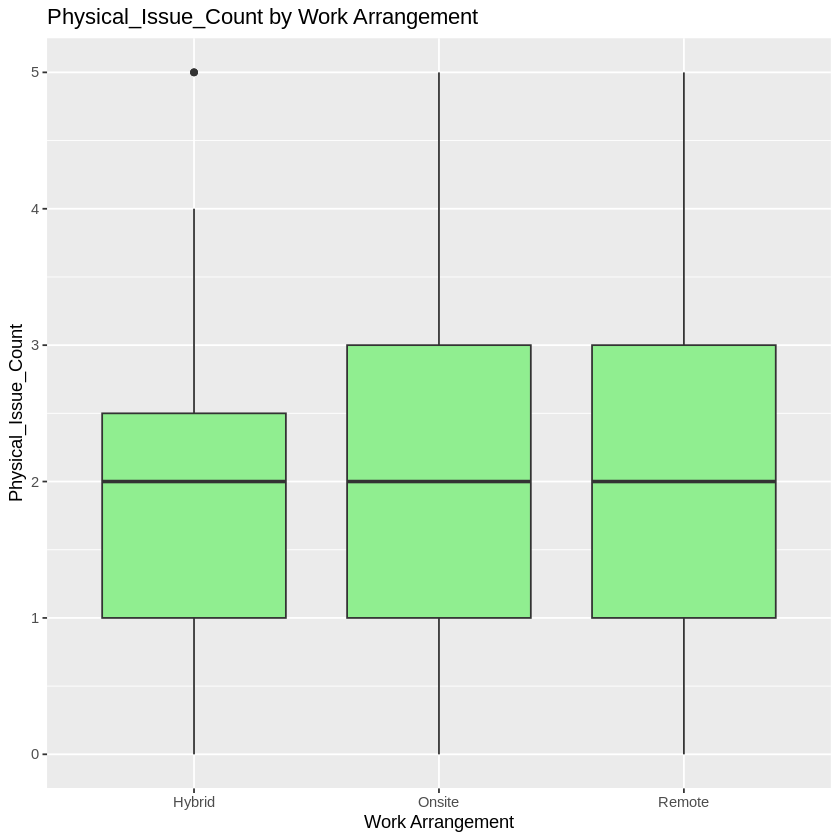

In [ ]:

# NUMERICAL vs WORK ARRANGEMENT

for (v in numeric_vars) {
  print(
    ggplot(data, aes_string(x = "Work_Arrangement", y = v)) +
      geom_boxplot(fill = "lightgreen") +
      labs(title = paste(v, "by Work Arrangement"),
           x = "Work Arrangement", y = v)
  )
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



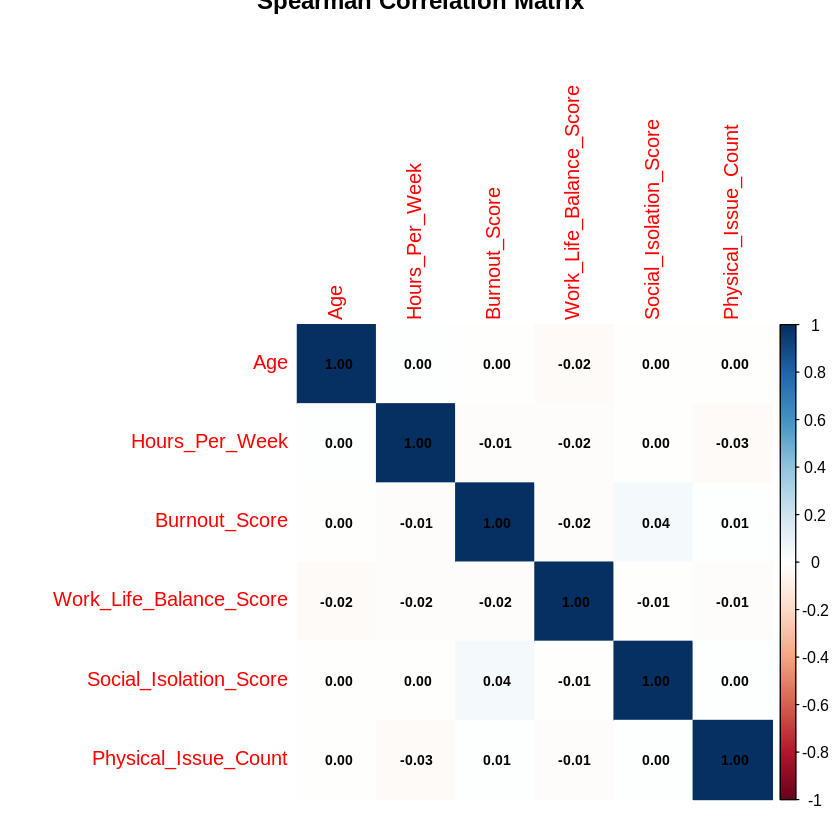

In [ ]:
install.packages("corrplot")

#CORRELATION MATRIX

library(corrplot)

num_data <- data[, numeric_vars]
cor_matrix <- cor(num_data, method = "spearman")

corrplot(cor_matrix, method = "color",
         addCoef.col = "black",
         number.cex = 0.7,
         main = "Spearman Correlation Matrix")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



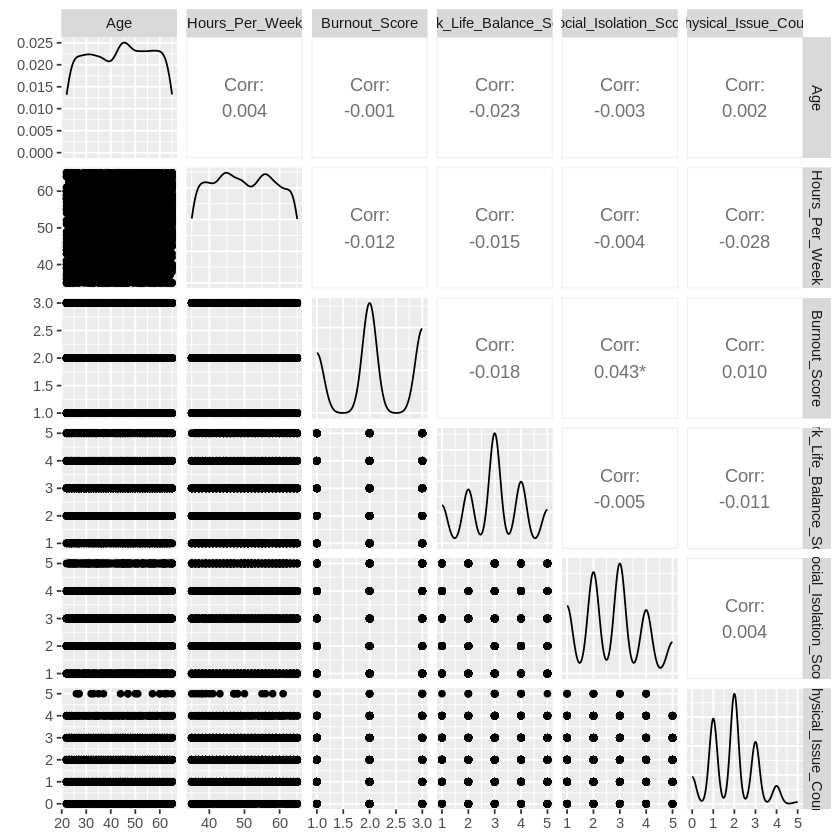

In [ ]:
install.packages("GGally")

library(GGally)

ggpairs(num_data)


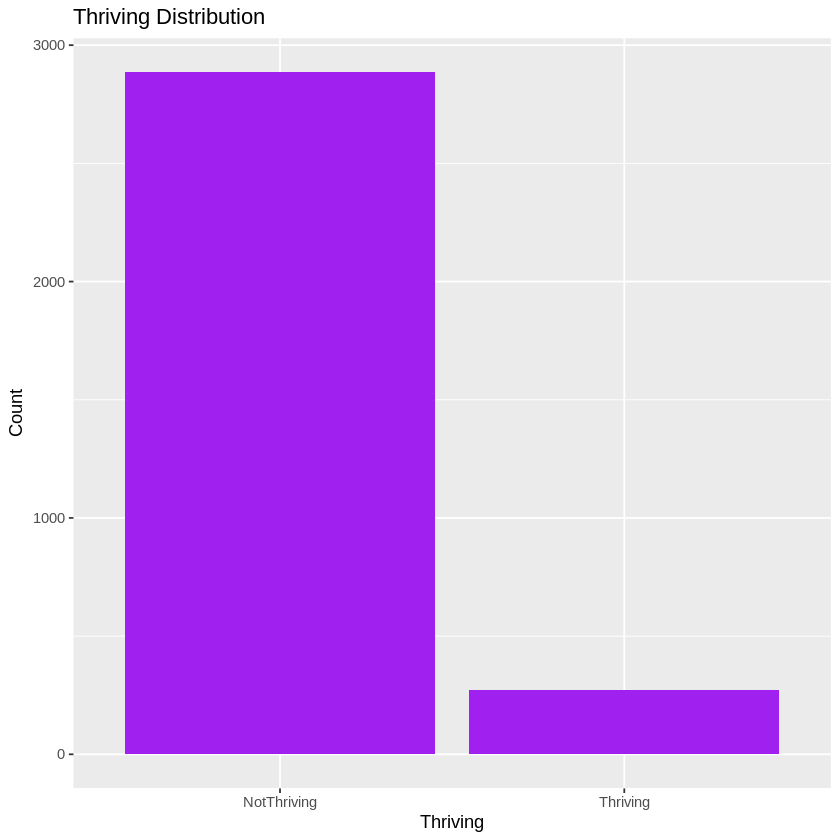

In [ ]:

#THRIVING DISTRIBUTION

ggplot(data, aes(x = Thriving)) +
  geom_bar(fill = "purple") +
  labs(title = "Thriving Distribution", y = "Count")


# Data Transformation for Modeling

In [ ]:
install.packages("fastDummies")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Create copy of dataset
library(data.table)
model_data <- copy(data)


Classify variable types

In [ ]:
nominal_vars <- c("Gender", "Region", "Industry", "Job_Role", "Work_Arrangement","Mental_Health_Status",

                  "Mental_Health_Flag",
                  "Physical_Issue_Flag",
                  "Thriving"
                  )

ordinal_vars <- c("Salary_Range",


                  "Work_Life_Balance_Score", "Social_Isolation_Score",


                  "Burnout_Score"
                  )

numerical_vars <- c("Age", "Hours_Per_Week",

                    "Physical_Issue_Count"
                     )


drop_vars <- c("Survey_Date",
               "Burnout_Level",
               "Physical_Health_Issues"
               )

In [ ]:
# Nominal Categorical
# One-hot encode Nominal Categorical variables
library(fastDummies)
model_data <- dummy_cols(model_data,
                        select_columns = nominal_vars,
                        remove_selected_columns = TRUE,
                        remove_first_dummy = FALSE)


In [ ]:
# Ordinal Categorical
# Label-encode Ordinal Categorical variables
# Ordered Levels
order_Salary_Range <- c("$40K-60K", "$60K-80K", "$80K-100K", "$100K-120K", "$120K+") # Salary_Range


encode_ordinal <- function(model_data, column, levels_order) {
  model_data[[column]] <- factor(model_data[[column]],
                           levels = levels_order,
                           ordered = TRUE)
  model_data[[paste0(column)]] <- as.integer(model_data[[column]])
  return(model_data)
}

# Apply function to variables
model_data <- encode_ordinal(model_data, "Salary_Range", order_Salary_Range)


Standard scale numerical variables

In [ ]:
# Standard Scale Numerical and Ordinal Categorical Variables
unscaled_model_data <- copy(model_data)

# Standard scale numerical variables
vars_to_scale <- c(numerical_vars)
model_data[vars_to_scale] <- scale(model_data[vars_to_scale])


Drop redundant variables

In [ ]:
model_data$Burnout_Level <- NULL
model_data$Survey_Date <- NULL
model_data$Physical_Health_Issues <- NULL

In [ ]:
#replace special characters with underscores
colnames(model_data) <- gsub(" ", "_", colnames(model_data))
colnames(model_data) <- gsub("-", "_", colnames(model_data))

In [ ]:
#data types are numeric for modeling
model_data[] <- lapply(model_data, function(x) {
  if (is.factor(x) || is.character(x)) {
    as.numeric(as.character(x))
  } else {
    x
  }
})


In [ ]:
# Shape of dataset
dim(model_data)

[1] 3157   66

# Train-Test Split

In [ ]:

set.seed(42)

# 80% training, 20% testing
train_index <- sample(seq_len(nrow(model_data)), size = 0.8 * nrow(model_data))

train_df <- model_data[train_index, ]
test_df  <- model_data[-train_index, ]


In [ ]:
dim(train_df)
dim(test_df)

[1] 2525   66

[1] 632  66

# RQ 1 - Which factors most strongly predict Burnout_Level?


In [ ]:
# Feature Selection via LASSO
install.packages("glmnet")
library(glmnet)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Package for checking VIF
install.packages("car")
library(car)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages(c( #"FSelector",
                   "FSelectorRcpp",
                   "vip", "Boruta", "randomForest"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(FSelectorRcpp)       # or library(FSelectorRcpp) if needed
library(vip)
library(Boruta)
library(randomForest)    # required backend for Boruta


#### Feature Selection Methods

In [ ]:
# Assign target variable
target_var <- "Burnout_Score"

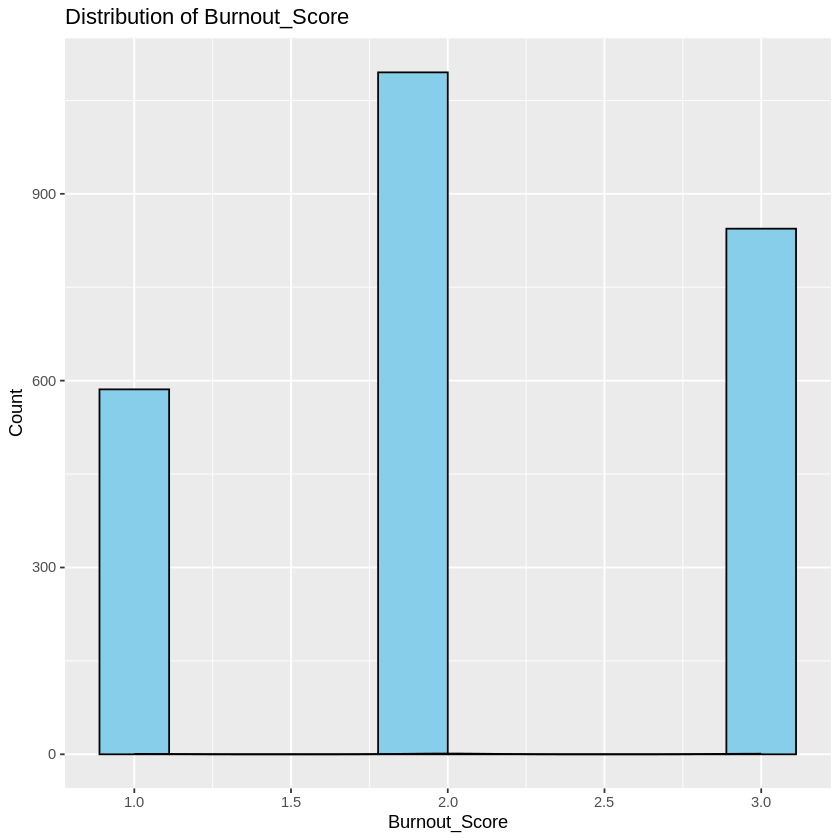

In [ ]:

# Check distributions of TARGET variable
library(ggplot2)

print(
    ggplot(train_df, aes_string(x = target_var)) +
      geom_histogram(bins = 10, color = "black", fill = "skyblue") +
      geom_density(alpha = 0.3, fill = "orange") +
      labs(title = paste("Distribution of", target_var),
           x = target_var, y = "Count")
  )

In [ ]:
# Remove features that can cause data leakage or bias
remove_feats <- c("Thriving_NotThriving", "Thriving_Thriving")

# Build the formula dynamically to EXCLUDE features in remove_feats
all_feats <- colnames(train_df)
predictor_feats <- setdiff(all_feats, c(target_var, remove_feats))


In [ ]:
# formula_str <- paste(target_var,"~", paste(predictor_feats, collapse = " + "))
formula_obj <- as.formula(
  paste(target_var, "~", paste(predictor_feats, collapse = " + "))
)

In [ ]:
# Split predictors and target
x <- model.matrix(formula_obj, data = train_df)[, -1]  # remove intercept
y <- train_df[[target_var]]

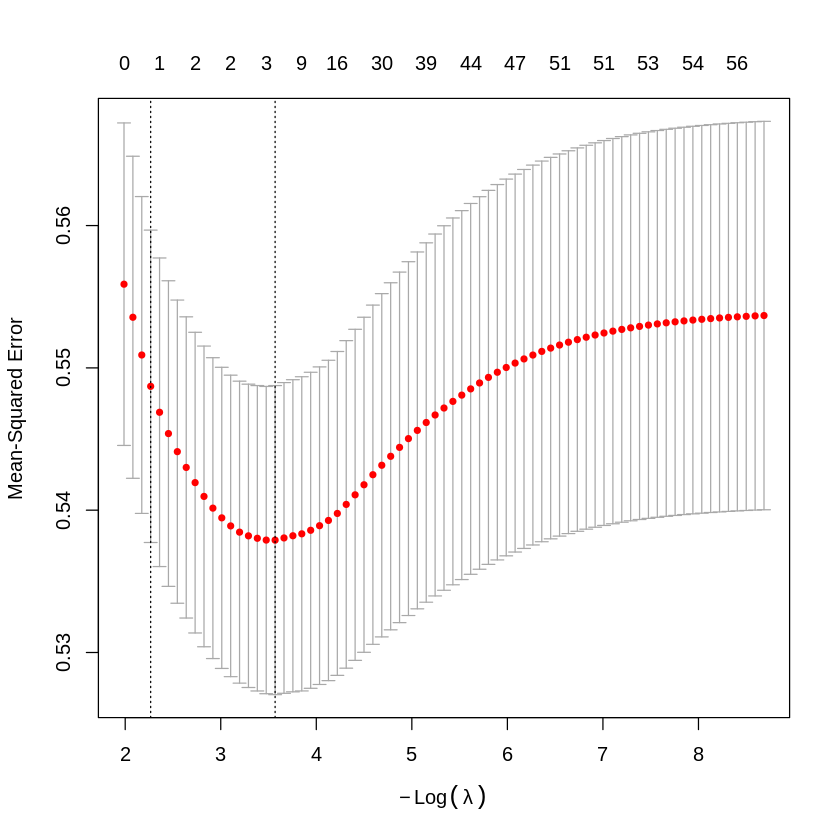

In [ ]:
# Run LASSO with cross-validation
set.seed(42)

cv_lasso <- cv.glmnet(
  x, y,
  alpha = 1,          # LASSO (alpha=1)
  family = "gaussian", # numeric target => linear regression
  type.measure = "mse"   # minimize mean squared error (default for gaussian)

)

plot(cv_lasso)

In [ ]:

coef_lasso <- coef(cv_lasso, s = "lambda.min")
coef_lasso

64 x 1 sparse Matrix of class "dgCMatrix"
                                       lambda.min
(Intercept)                            2.17984336
Age                                    .         
Hours_Per_Week                         .         
Work_Life_Balance_Score                .         
Social_Isolation_Score                 .         
Salary_Range                           .         
Physical_Issue_Count                   .         
Gender_Female                          .         
Gender_Male                            .         
Gender_Non_binary                      .         
Gender_Prefer_not_to_say               .         
Region_Africa                          .         
Region_Asia                            .         
Region_Europe                          .         
Region_North_America                   .         
Region_Oceania                         .         
Region_South_America                   .         
Industry_Customer_Service              .         
Industry

In [ ]:
# Preview which features were selected
m1_selected_features <- rownames(coef_lasso)[coef_lasso[,1] != 0]
feature_set_lasso <- m1_selected_features[m1_selected_features != "(Intercept)"]
feature_set_lasso

[1] "Job_Role_Account_Manager" "Work_Arrangement_Onsite" 
[3] "Work_Arrangement_Remote"

In [ ]:

train_df[[target_var]] <- as.factor(train_df[[target_var]])


formula_mi <- as.formula(
  paste(target_var, "~ .")
)


mi_scores <- information_gain(formula_mi, data = train_df)


sorted_mi_df <- mi_scores[order(-mi_scores$importance), ]


In [ ]:
mi_scores_filtered <- mi_scores[!mi_scores$attributes %in% remove_feats, ]
mi_scores_filtered <- mi_scores_filtered[order(-mi_scores_filtered$importance), ]
head(mi_scores_filtered, 5)

,attributes,importance
,<chr>,<dbl>
51,Work_Arrangement_Onsite,0.01708729
52,Work_Arrangement_Remote,0.01033991
1,Age,0.00000000
2,Hours_Per_Week,0.00000000
3,Work_Life_Balance_Score,0.00000000


In [ ]:
feature_set_mi <- mi_scores_filtered$attributes[
  mi_scores_filtered$importance > 0
]
feature_set_mi

[1] "Work_Arrangement_Onsite" "Work_Arrangement_Remote"

In [ ]:

library(vip)
library(randomForest)

rf_train <- copy(train_df)


# Drop empty factor levels
rf_train[[target_var]] <- droplevels(rf_train[[target_var]])

rf_train[[target_var]] <- as.factor(rf_train[[target_var]])


In [ ]:
# Train RF using all predictors
set.seed(42)

rf_model <- randomForest(
  as.formula(paste(target_var, "~ .")),
  data  = rf_train,
  ntree = 500,
  importance = TRUE
)


In [ ]:
# Get importance values
rf_imp <- importance(rf_model)


In [ ]:
# Build a Feature Importance DataFrame
rf_imp <- importance(rf_model)

rf_imp_df <- data.frame(
  Feature = rownames(rf_imp),
  MeanDecreaseAccuracy = rf_imp[, "MeanDecreaseAccuracy"],
  MeanDecreaseGini     = rf_imp[, "MeanDecreaseGini"],
  row.names = NULL
)

# Sort by Gini importance
rf_imp_df <- rf_imp_df[order(-rf_imp_df$MeanDecreaseGini), ]

# Select Top 15 Features for Plotting
top15_rf <- rf_imp_df[1:15, ]



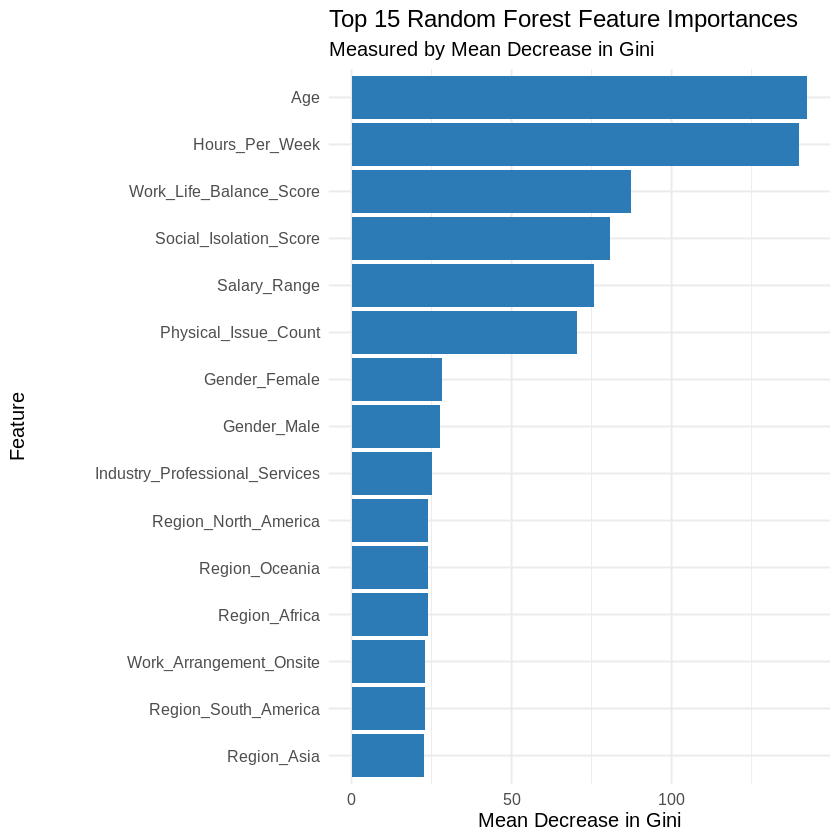

In [ ]:
library(ggplot2)

ggplot(top15_rf,
       aes(x = reorder(Feature, MeanDecreaseGini),
           y = MeanDecreaseGini)) +
  geom_col(fill = "#2C7BB6") +
  coord_flip() +
  labs(
    title = "Top 15 Random Forest Feature Importances",
    subtitle = "Measured by Mean Decrease in Gini",
    x = "Feature",
    y = "Mean Decrease in Gini"
  ) +
  theme_minimal(base_size = 12)


The Mean Decrease in Gini plot reflects how much each variable helps reduce classification uncertainty at tree splits, with larger values indicating greater importance.

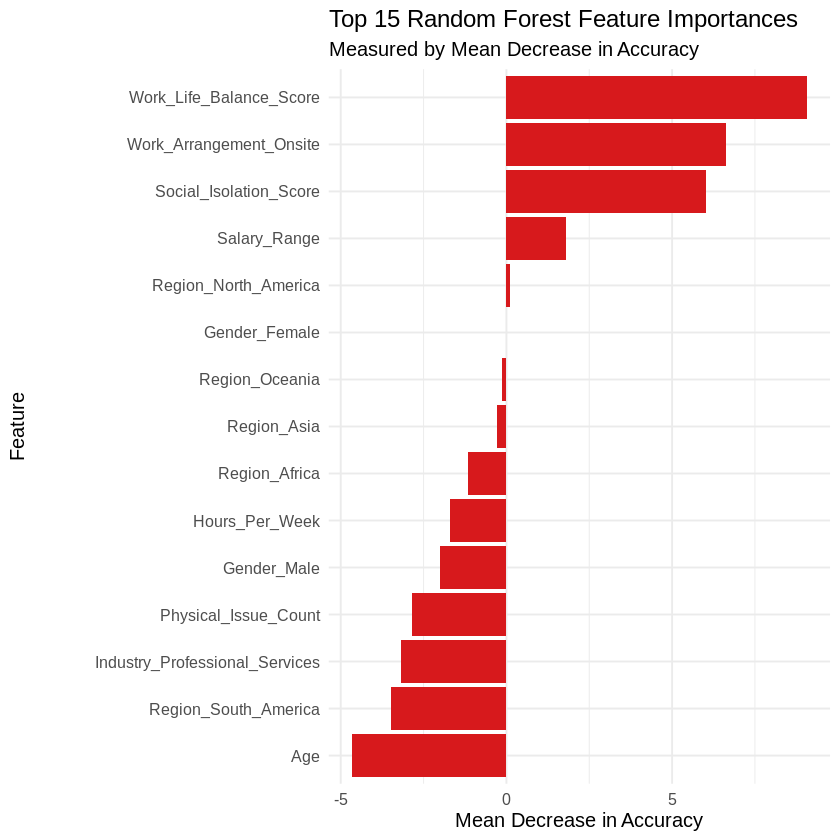

In [ ]:
ggplot(top15_rf,
       aes(x = reorder(Feature, MeanDecreaseAccuracy),
           y = MeanDecreaseAccuracy)) +
  geom_col(fill = "#D7191C") +
  coord_flip() +
  labs(
    title = "Top 15 Random Forest Feature Importances",
    subtitle = "Measured by Mean Decrease in Accuracy",
    x = "Feature",
    y = "Mean Decrease in Accuracy"
  ) +
  theme_minimal(base_size = 12)


In [ ]:
# Top 15 Features based on Mean Decrease Gini + Filtering out negative features based on Mean Decrease Accuracy
select_rf_feats_df <- top15_rf[top15_rf$MeanDecreaseAccuracy > 0, ] # negative Mean Decrease Accuracy Scores harm the model
select_rf_feats_df

# Select Random Forest Feature Set
feature_set_rf <- select_rf_feats_df$Feature
feature_set_rf

,Feature,MeanDecreaseAccuracy,MeanDecreaseGini
,<chr>,<dbl>,<dbl>
3,Work_Life_Balance_Score,9.07879171,87.44319
4,Social_Isolation_Score,6.02504916,80.75011
5,Salary_Range,1.79346565,75.75020
14,Region_North_America,0.09840918,24.02859
51,Work_Arrangement_Onsite,6.63258234,22.83625


[1] "Work_Life_Balance_Score" "Social_Isolation_Score" 
[3] "Salary_Range"            "Region_North_America"   
[5] "Work_Arrangement_Onsite"

#### EDA for Selected Features vs Target Variable (Burnout Score)

In [ ]:
install.packages("corrplot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Preview selected features
feature_set_lasso
feature_set_mi
feature_set_rf

[1] "Job_Role_Account_Manager" "Work_Arrangement_Onsite" 
[3] "Work_Arrangement_Remote"

[1] "Work_Arrangement_Onsite" "Work_Arrangement_Remote"

[1] "Work_Life_Balance_Score" "Social_Isolation_Score" 
[3] "Salary_Range"            "Region_North_America"   
[5] "Work_Arrangement_Onsite"

In [ ]:
# Unique selected features
feature_set_all <- unique(c(feature_set_lasso, feature_set_mi, feature_set_rf))
feature_set_all

length(feature_set_all)

[1] "Job_Role_Account_Manager" "Work_Arrangement_Onsite" 
[3] "Work_Arrangement_Remote"  "Work_Life_Balance_Score" 
[5] "Social_Isolation_Score"   "Salary_Range"            
[7] "Region_North_America"

[1] 7

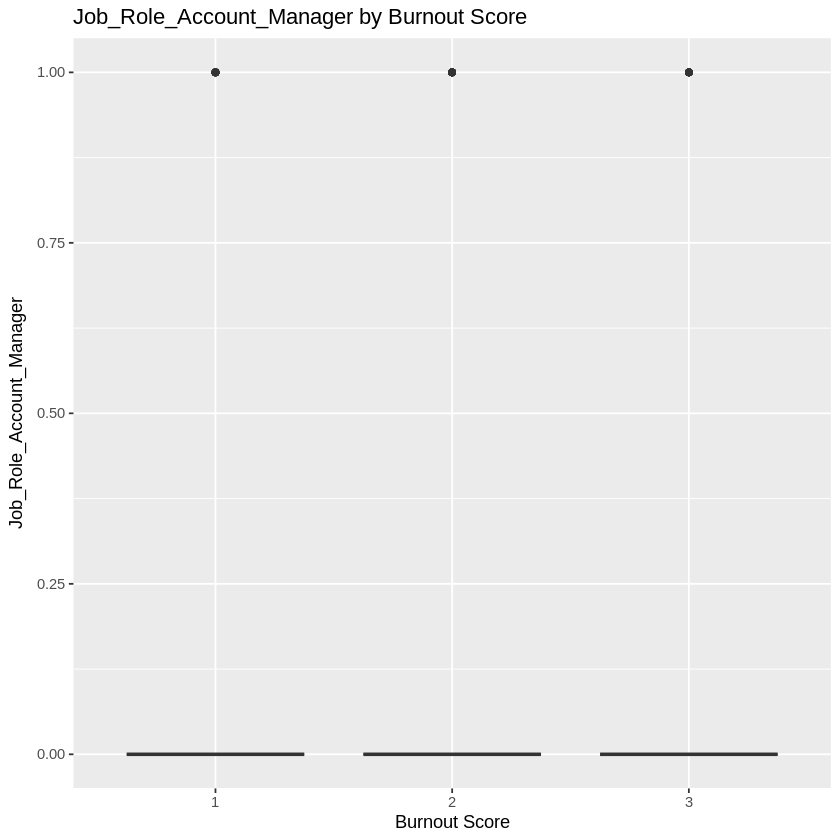

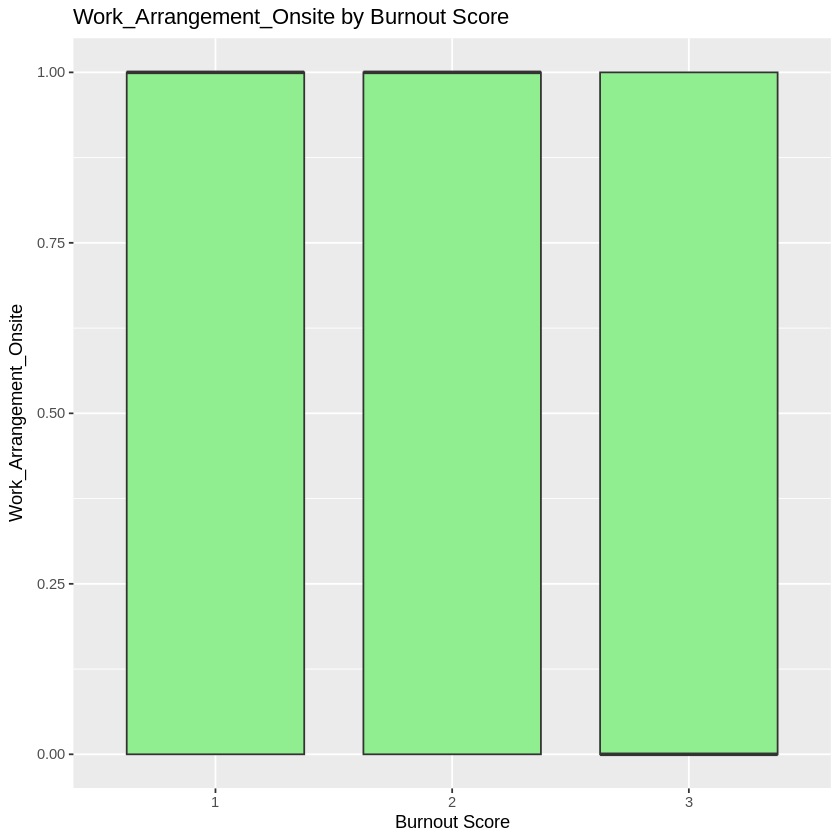

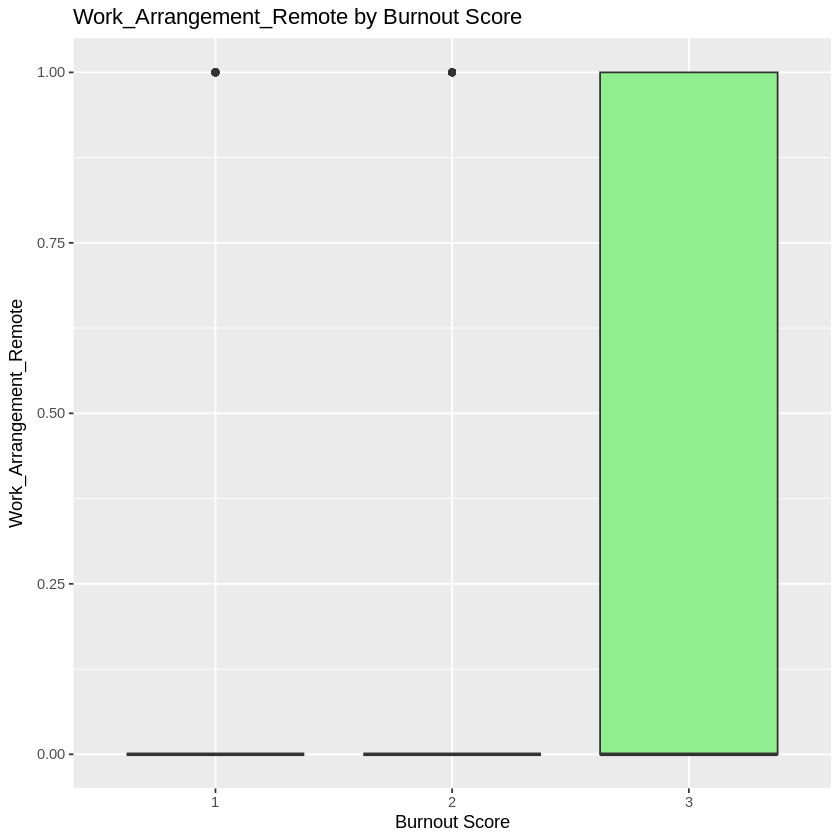

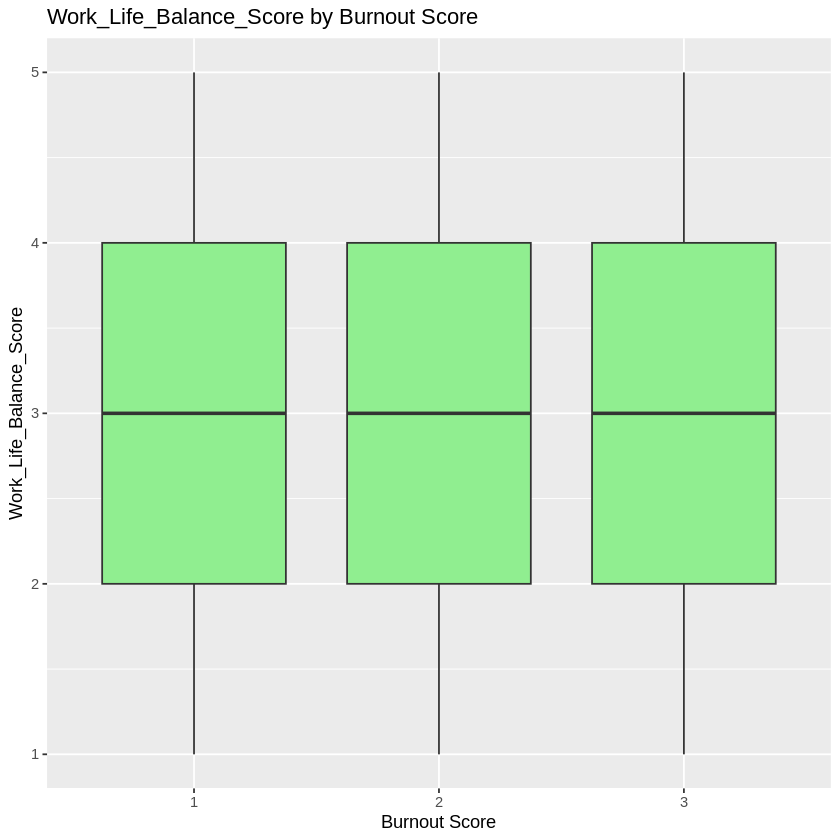

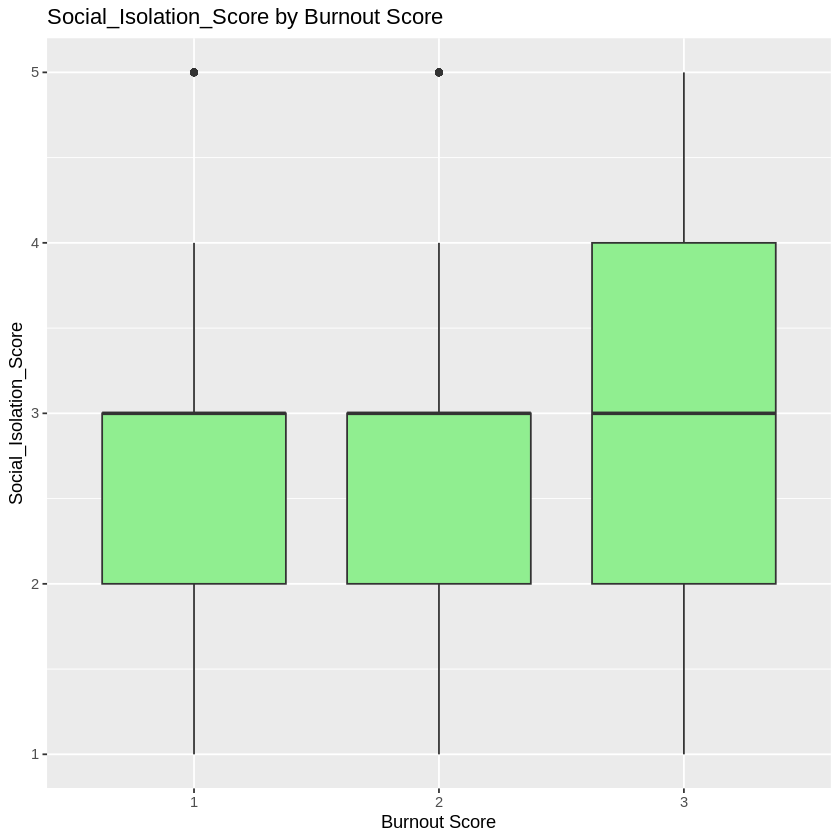

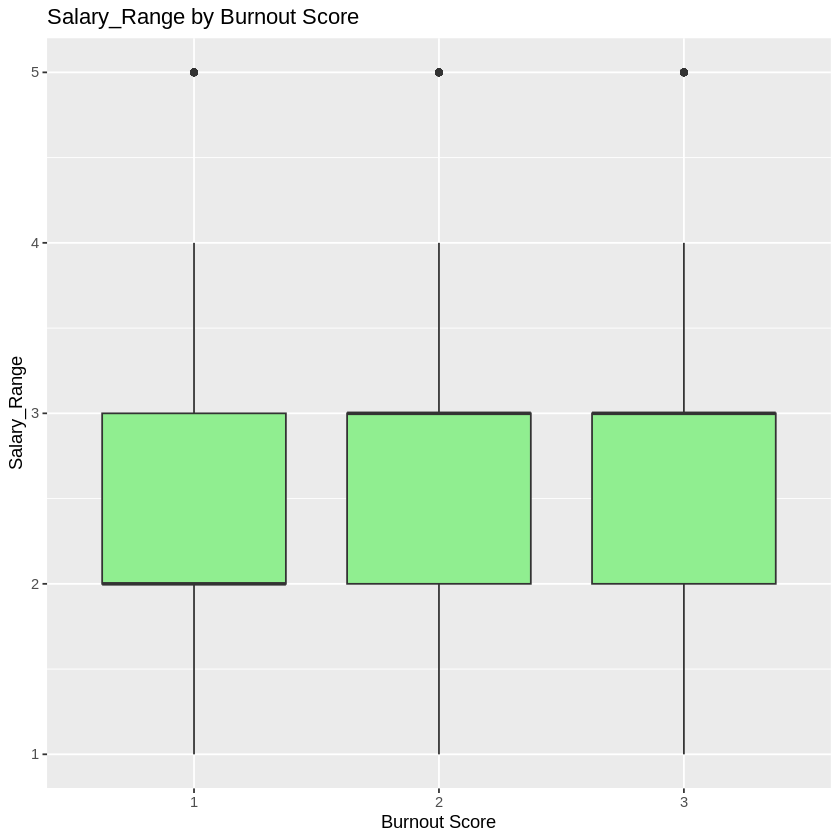

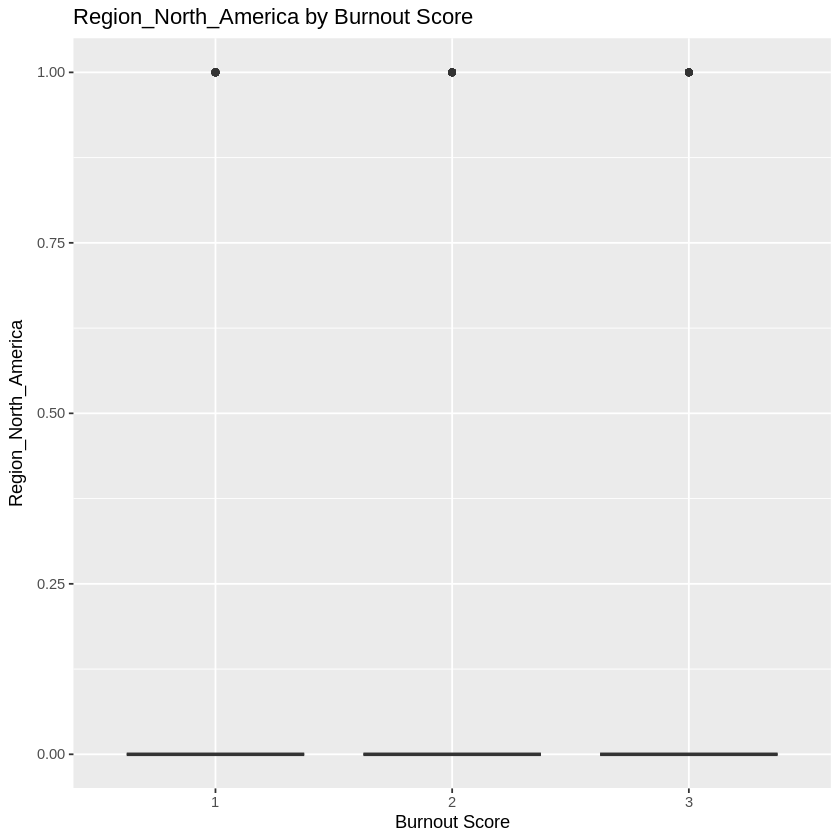

In [ ]:

# Boxplots of Features by Burnout Score
for (v in feature_set_all) {
  print(
    ggplot(train_df, aes_string(x = "Burnout_Score", y = v)) +
      geom_boxplot(fill = "lightgreen") +
      labs(title = paste(v, "by Burnout Score"),
           x = "Burnout Score", y = v)
  )
}


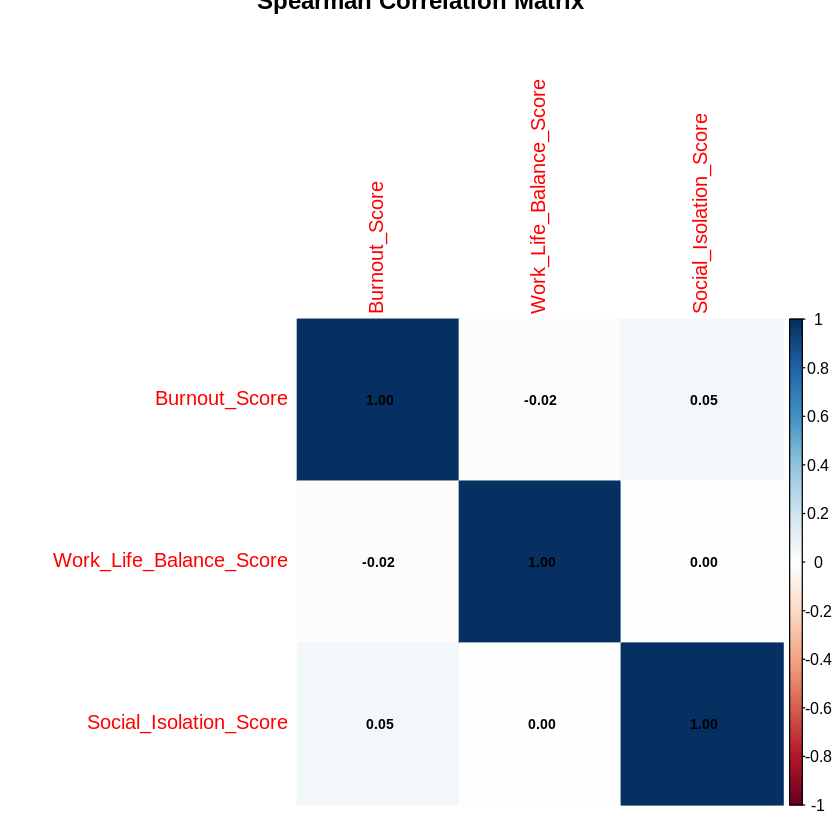

In [ ]:

# Correlation

library(corrplot)

selected_numeric_vars <- c('Burnout_Score','Work_Life_Balance_Score','Social_Isolation_Score')
num_data <- train_df[, selected_numeric_vars]
num_data <- as.data.frame(lapply(num_data, function(x) as.numeric(as.character(x)))) # Convert data to numerical

cor_matrix <- cor(num_data, method = "spearman")

corrplot(cor_matrix, method = "color",
         addCoef.col = "black",
         number.cex = 0.7,
         main = "Spearman Correlation Matrix")


#### Univariate Statistical Significance Tests

In [ ]:
feature_set_all

[1] "Job_Role_Account_Manager" "Work_Arrangement_Onsite" 
[3] "Work_Arrangement_Remote"  "Work_Life_Balance_Score" 
[5] "Social_Isolation_Score"   "Salary_Range"            
[7] "Region_North_America"

In [ ]:
# Binary features
selected_binary_features <- c('Job_Role_Account_Manager','Work_Arrangement_Onsite','Work_Arrangement_Remote','Gender_Female')
selected_binary_features

[1] "Job_Role_Account_Manager" "Work_Arrangement_Onsite" 
[3] "Work_Arrangement_Remote"  "Gender_Female"

In [ ]:
sig_test_df <- copy(train_df)
# Burnout = numeric outcome
sig_test_df$Burnout_Score <- as.numeric(as.character(sig_test_df$Burnout_Score))

# Job role = grouping variable (0/1 factor)
sig_test_df$Job_Role_Account_Manager <- as.factor(sig_test_df$Job_Role_Account_Manager)

In [ ]:
# Function
run_wilcox_tests <- function(df, feature_list, target = "Burnout_Score") {

  results <- lapply(feature_list, function(feat) {

    # Ensure correct types
    y <- as.numeric(as.character(df[[target]]))
    g <- as.factor(df[[feat]])

    # Only test if binary with 2 groups
    if (length(unique(g[!is.na(g)])) == 2) {
      test <- wilcox.test(y ~ g)

      data.frame(
        Feature = feat,
        W = test$statistic,
        p_value = test$p.value,
        stringsAsFactors = FALSE
      )
    } else {
      data.frame(
        Feature = feat,
        W = NA,
        p_value = NA,
        stringsAsFactors = FALSE
      )
    }
  })

  do.call(rbind, results)
}


In [ ]:
wilcox_results <- run_wilcox_tests(
  df = sig_test_df,
  feature_list = selected_binary_features,
  target = "Burnout_Score"
)

# Significant Features
wilcox_results$Significant <- wilcox_results$p_value < 0.05
wilcox_results



,Feature,W,p_value,Significant
,<chr>,<dbl>,<dbl>,<lgl>
W,Job_Role_Account_Manager,146349.5,8.058921e-03,TRUE
W1,Work_Arrangement_Onsite,953977.0,3.251463e-20,TRUE
W2,Work_Arrangement_Remote,380480.0,7.592485e-13,TRUE
W3,Gender_Female,782851.5,4.929780e-01,FALSE


2) **Spearman Correlation** (Ordinal Features vs Ordinal Target (Burnout Level))

Used to test for significance between ordinal (level-encoded) variables and Burnout_Score.

In [ ]:
selected_num_feats <- c('Work_Life_Balance_Score','Social_Isolation_Score','Salary_Range')

In [ ]:
run_spearman_tests <- function(df, feature_list, target = "Burnout_Score") {

  results <- lapply(feature_list, function(feat) {

    x <- as.numeric(as.character(df[[feat]]))
    y <- as.numeric(as.character(df[[target]]))

    # Remove missing values safely
    valid_idx <- complete.cases(x, y)
    x <- x[valid_idx]
    y <- y[valid_idx]

    # Run Spearman only if variable has variation
    if (length(unique(x)) > 1) {
      test <- cor.test(x, y, method = "spearman", exact = FALSE)

      data.frame(
        Feature = feat,
        Spearman_Rho = test$estimate,
        p_value = test$p.value,
        stringsAsFactors = FALSE
      )
    } else {
      data.frame(
        Feature = feat,
        Spearman_Rho = NA,
        p_value = NA,
        stringsAsFactors = FALSE
      )
    }
  })

  do.call(rbind, results)
}


In [ ]:
spearman_results <- run_spearman_tests(
  df = sig_test_df,
  feature_list = selected_num_feats,
  target = "Burnout_Score"
)

spearman_results$Significant <- spearman_results$p_value < 0.05
spearman_results


,Feature,Spearman_Rho,p_value,Significant
,<chr>,<dbl>,<dbl>,<lgl>
rho,Work_Life_Balance_Score,-0.016450299,0.408654419,FALSE
rho1,Social_Isolation_Score,0.054571399,0.006090572,TRUE
rho2,Salary_Range,-0.009815652,0.622013975,FALSE


#### Multivariate Statistical Significance Tests

In [ ]:
# Brant Test for Proportional Odds Assumption
install.packages("brant")
install.packages("caret")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("pscl")   # run once

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(MASS)
library(caret)
library(brant)
library(pscl)

In [ ]:
# Convert target variable in train_df to factor
train_df[[target_var]] <- factor(
  train_df[[target_var]],
  levels = c(1, 2, 3, 4, 5),    # keep the natural order
  ordered = TRUE
)


In [ ]:
# Convert target variable in test_df to factor
test_df[[target_var]] <- factor(
  test_df[[target_var]],
  levels  = levels(train_df[[target_var]]),  # match training levels
  ordered = TRUE
)


Analyze statistical significance by running an **Ordinal Logistic Regression** on four unique feature sets:
* LASSO-selected features
* Mutual Information features
* Random Forest features
* LASSO + Mutual Information + Random Forest combined features

In [ ]:
feature_set_lasso
feature_set_mi
feature_set_rf
feature_set_all

[1] "Job_Role_Account_Manager" "Work_Arrangement_Onsite" 
[3] "Work_Arrangement_Remote"

[1] "Work_Arrangement_Onsite" "Work_Arrangement_Remote"

[1] "Work_Life_Balance_Score" "Social_Isolation_Score" 
[3] "Salary_Range"            "Region_North_America"   
[5] "Work_Arrangement_Onsite"

[1] "Job_Role_Account_Manager" "Work_Arrangement_Onsite" 
[3] "Work_Arrangement_Remote"  "Work_Life_Balance_Score" 
[5] "Social_Isolation_Score"   "Salary_Range"            
[7] "Region_North_America"

  1. **Model 1**: Ordinal Model with LASSO-selected features

In [ ]:
# Build formula dynamically
formula_ord <- as.formula(
  paste(target_var, "~", paste(feature_set_lasso, collapse = " + "))
)

In [ ]:
# Fit ordinal logistic regression
model_polr <- polr(formula_ord, data = train_df, Hess = TRUE)
summary(model_polr)


Call:
polr(formula = formula_ord, data = train_df, Hess = TRUE)

Coefficients:
                           Value Std. Error t value
Job_Role_Account_Manager -0.4553     0.1836  -2.480
Work_Arrangement_Onsite  -0.5677     0.0844  -6.727
Work_Arrangement_Remote   0.3571     0.1100   3.247

Intercepts:
    Value    Std. Error t value 
1|2  -1.4678   0.0742   -19.7844
2|3   0.4799   0.0678     7.0793
3|4  24.3953   0.0678   359.8771
4|5  25.3761   0.0678   374.3462

Residual Deviance: 5288.125 
AIC: 5302.125 

In [ ]:
# P-values
# Extract coefficient table
(ctable <- coef(summary(model_polr)))

# Compute p-values from t-values
pvals <- 2 * (1 - pnorm(abs(ctable[, "t value"])))

# Combine into final significance table
polr_results <- cbind(ctable, "p value" = pvals)

polr_results


,Value,Std. Error,t value
Job_Role_Account_Manager,-0.4552867,0.18355358,-2.480402
Work_Arrangement_Onsite,-0.5677479,0.08439771,-6.727053
Work_Arrangement_Remote,0.3570939,0.10998546,3.246737
1|2,-1.4678427,0.07419191,-19.784403
2|3,0.4798896,0.06778782,7.079290
3|4,24.3952827,0.06778782,359.877096
4|5,25.3761120,0.06778782,374.346204


,Value,Std. Error,t value,p value
Job_Role_Account_Manager,-0.4552867,0.18355358,-2.480402,1.312342e-02
Work_Arrangement_Onsite,-0.5677479,0.08439771,-6.727053,1.731348e-11
Work_Arrangement_Remote,0.3570939,0.10998546,3.246737,1.167360e-03
1|2,-1.4678427,0.07419191,-19.784403,0.000000e+00
2|3,0.4798896,0.06778782,7.079290,1.448841e-12
3|4,24.3952827,0.06778782,359.877096,0.000000e+00
4|5,25.3761120,0.06778782,374.346204,0.000000e+00


Model diagnostics:

In [ ]:
# Check Brant Test
brant(model_polr)

Warning message in matrix(model$zeta, nrow = 1, ncol = J - 1, byrow = T):
“data length differs from size of matrix: [4 != 1 x 2]”


------------------------------------------------------------ 
Test for			X2	df	probability 
------------------------------------------------------------ 
Omnibus				1.29	3	0.73
Job_Role_Account_Manager	0.23	1	0.63
Work_Arrangement_Onsite	1.02	1	0.31
Work_Arrangement_Remote	0.27	1	0.6
------------------------------------------------------------ 

H0: Parallel Regression Assumption holds


The Brant test shows that neither the overall model nor any of the individual predictors violate the proportional odds assumption (all p-values > 0.05). Therefore, the parallel regression assumption holds, and your ordinal logistic regression model using polr() is appropriate.

In [ ]:
# Check VIF
vif_values <- vif(model_polr)
vif_values


Job_Role_Account_Manager  Work_Arrangement_Onsite  Work_Arrangement_Remote 
                1.002177                 1.252774                 1.254670

VIF values must be < 5

In [ ]:
# Check Model Fit (Pseudo R^2)
# Use McFadded R^2
pR2(model_polr)


fitting null model for pseudo-r2


llh       llhNull            G2      McFadden          r2ML 
-2.644063e+03 -2.695707e+03  1.032887e+02  1.915800e-02  4.008104e-02 
         r2CU 
 4.545467e-02

In [ ]:
# Check Predictive Performance
# Predict classes on the test set
test_df$pred_class <- predict(model_polr,
                              newdata = test_df,
                              type   = "class")

# (Optional) Predict class probabilities
test_df$pred_prob <- predict(model_polr,
                             newdata = test_df,
                             type   = "probs")

In [ ]:
# (Additional) How much the odds of moving into higher burnout change for each feature.
exp(coef(model_polr)) # 'exp' converts model estimate coefficients into log-odds units

Job_Role_Account_Manager  Work_Arrangement_Onsite  Work_Arrangement_Remote 
               0.6342661                0.5668005                1.4291701

| Feature                  | β (log-odds) | exp(β)     | Interpretation                                                                                         |
| ------------------------ | ------------ | ---------- | ------------------------------------------------------------------------------------------------------ |
| Job_Role_Account_Manager | -0.455       | ≈ **0.63** | Being an Account Manager **reduces the odds** of being in a *higher burnout category* by about **37%** |
| Work_Arrangement_Onsite  | -0.568       | ≈ **0.57** | Onsite work **reduces the odds** of higher burnout by about **43%**                                    |
| Work_Arrangement_Remote  | 0.357        | ≈ **1.43** | Remote work **increases the odds** of higher burnout by about **43%**                                  |


In [ ]:
# Model Performance Metrics
# 3. Confusion matrix + metrics
cm <- confusionMatrix(
  data      = test_df$pred_class,
  reference = test_df[[target_var]]
)

cm          # prints confusion matrix and:
            # - Accuracy
            # - Kappa
            # - Sensitivity / Specificity by class
            # - Balanced accuracy, etc.

# 4. If you want to pull specific metrics:
accuracy <- cm$overall["Accuracy"]
kappa    <- cm$overall["Kappa"]
by_class <- cm$byClass   # per-level sensitivity, specificity, etc.

accuracy
kappa
by_class

Confusion Matrix and Statistics

          Reference
Prediction   1   2   3   4   5
         1   0   0   0   0   0
         2 145 219 146   0   0
         3  14  52  56   0   0
         4   0   0   0   0   0
         5   0   0   0   0   0

Overall Statistics
                                          
               Accuracy : 0.4351          
                 95% CI : (0.3961, 0.4748)
    No Information Rate : 0.4288          
    P-Value [Acc > NIR] : 0.3886          
                                          
                  Kappa : 0.0463          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: 1 Class: 2 Class: 3 Class: 4 Class: 5
Sensitivity            0.0000   0.8081  0.27723       NA       NA
Specificity            1.0000   0.1939  0.84651        1        1
Pos Pred Value            NaN   0.4294  0.45902       NA       NA
Neg Pred Value         0.7484   0.5738  0.71373       NA       NA
P

Accuracy 
0.4351266

Kappa 
0.0462696

,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
Class: 1,0.0000000,1.0000000,NaN,0.7484177,NA,0.0000000,NA,0.2515823,0.00000000,0.000000,0.5000000
Class: 2,0.8081181,0.1939058,0.4294118,0.5737705,0.4294118,0.8081181,0.5608195,0.4287975,0.34651899,0.806962,0.5010119
Class: 3,0.2772277,0.8465116,0.4590164,0.7137255,0.4590164,0.2772277,0.3456790,0.3196203,0.08860759,0.193038,0.5618697
Class: 4,NA,1.0000000,NA,NA,NA,NA,NA,0.0000000,0.00000000,0.000000,NA
Class: 5,NA,1.0000000,NA,NA,NA,NA,NA,0.0000000,0.00000000,0.000000,NA


  2. **Model 2**: Ordinal Model with Mutual Information-selected features

In [ ]:
# Build formula dynamically
formula_ord <- as.formula(
  paste(target_var, "~", paste(feature_set_mi, collapse = " + "))
)

In [ ]:
# Fit ordinal logistic regression
model_polr <- polr(formula_ord, data = train_df, Hess = TRUE)
summary(model_polr)


Call:
polr(formula = formula_ord, data = train_df, Hess = TRUE)

Coefficients:
                          Value Std. Error t value
Work_Arrangement_Onsite -0.5629    0.08434  -6.674
Work_Arrangement_Remote  0.3699    0.10980   3.369

Intercepts:
    Value    Std. Error t value 
1|2  -1.4413   0.0733   -19.6638
2|3   0.5026   0.0671     7.4846
3|4  24.2367   0.0671   360.9437
4|5  25.2175   0.0671   375.5507

Residual Deviance: 5294.281 
AIC: 5306.281 

In [ ]:
# P-values
# Extract coefficient table
ctable <- coef(summary(model_polr))

# Compute p-values from t-values
pvals <- 2 * (1 - pnorm(abs(ctable[, "t value"])))

# Combine into final significance table
polr_results <- cbind(ctable, "p value" = pvals)

polr_results


,Value,Std. Error,t value,p value
Work_Arrangement_Onsite,-0.5628630,0.08434062,-6.673688,2.494538e-11
Work_Arrangement_Remote,0.3699219,0.10980426,3.368921,7.546314e-04
1|2,-1.4413146,0.07329794,-19.663779,0.000000e+00
2|3,0.5025743,0.06714815,7.484560,7.172041e-14
3|4,24.2367018,0.06714815,360.943710,0.000000e+00
4|5,25.2175311,0.06714815,375.550654,0.000000e+00


Model diagnostics:

In [ ]:
# Check Brant Test
brant(model_polr)

Warning message in matrix(model$zeta, nrow = 1, ncol = J - 1, byrow = T):
“data length differs from size of matrix: [4 != 1 x 2]”


------------------------------------------------------------ 
Test for			X2	df	probability 
------------------------------------------------------------ 
Omnibus				1.04	2	0.59
Work_Arrangement_Onsite	1.03	1	0.31
Work_Arrangement_Remote	0.27	1	0.6
------------------------------------------------------------ 

H0: Parallel Regression Assumption holds


In [ ]:
# Check VIF
vif_values <- vif(model_polr)
vif_values


Work_Arrangement_Onsite Work_Arrangement_Remote 
               1.251887                1.251887

In [ ]:
# Check Predictive Performance
# Predict classes on the test set
test_df$pred_class <- predict(model_polr,
                              newdata = test_df,
                              type   = "class")

# (Optional) Predict class probabilities
test_df$pred_prob <- predict(model_polr,
                             newdata = test_df,
                             type   = "probs")

In [ ]:
# (Additional) How much the odds of moving into higher burnout change for each feature.
exp(coef(model_polr)) # 'exp' converts model estimate coefficients into log-odds units

Work_Arrangement_Onsite Work_Arrangement_Remote 
               0.569576                1.447621

| Feature                     | Odds Ratio (exp(β)) | Interpretation                                                                                                                                                    |
| --------------------------- | ------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Work_Arrangement_Onsite** | **0.57**            | Employees working onsite have **about 43% lower odds** of being in a higher burnout category compared to non-onsite workers, holding other variables constant.    |
| **Work_Arrangement_Remote** | **1.45**            | Employees working remotely have **about 45% higher odds** of being in a higher burnout category compared to non-remote workers, holding other variables constant. |


In [ ]:
# Model Performance Metrics
# 3. Confusion matrix + metrics
cm <- confusionMatrix(
  data      = test_df$pred_class,
  reference = test_df[[target_var]]
)

cm          # prints confusion matrix and:
            # - Accuracy
            # - Kappa
            # - Sensitivity / Specificity by class
            # - Balanced accuracy, etc.

# 4. If you want to pull specific metrics:
accuracy <- cm$overall["Accuracy"]
kappa    <- cm$overall["Kappa"]
by_class <- cm$byClass   # per-level sensitivity, specificity, etc.

accuracy
kappa
by_class

Confusion Matrix and Statistics

          Reference
Prediction   1   2   3   4   5
         1   0   0   0   0   0
         2 143 217 144   0   0
         3  16  54  58   0   0
         4   0   0   0   0   0
         5   0   0   0   0   0

Overall Statistics
                                          
               Accuracy : 0.4351          
                 95% CI : (0.3961, 0.4748)
    No Information Rate : 0.4288          
    P-Value [Acc > NIR] : 0.3886          
                                          
                  Kappa : 0.0479          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: 1 Class: 2 Class: 3 Class: 4 Class: 5
Sensitivity            0.0000   0.8007  0.28713       NA       NA
Specificity            1.0000   0.2050  0.83721        1        1
Pos Pred Value            NaN   0.4306  0.45312       NA       NA
Neg Pred Value         0.7484   0.5781  0.71429       NA       NA
P

Accuracy 
0.4351266

Kappa 
0.04793573

,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
Class: 1,0.0000000,1.0000000,NaN,0.7484177,NA,0.0000000,NA,0.2515823,0.00000000,0.0000000,0.5000000
Class: 2,0.8007380,0.2049861,0.4305556,0.5781250,0.4305556,0.8007380,0.5600000,0.4287975,0.34335443,0.7974684,0.5028621
Class: 3,0.2871287,0.8372093,0.4531250,0.7142857,0.4531250,0.2871287,0.3515152,0.3196203,0.09177215,0.2025316,0.5621690
Class: 4,NA,1.0000000,NA,NA,NA,NA,NA,0.0000000,0.00000000,0.0000000,NA
Class: 5,NA,1.0000000,NA,NA,NA,NA,NA,0.0000000,0.00000000,0.0000000,NA


  3. **Model 3**: Ordinal Model with Random Forest-selected features

In [ ]:
# Build formula dynamically
formula_ord <- as.formula(
  paste(target_var, "~", paste(feature_set_rf, collapse = " + "))
)

In [ ]:
# Fit ordinal logistic regression
model_polr <- polr(formula_ord, data = train_df, Hess = TRUE)
summary(model_polr)


Call:
polr(formula = formula_ord, data = train_df, Hess = TRUE)

Coefficients:
                           Value Std. Error t value
Work_Life_Balance_Score -0.02406    0.03230 -0.7449
Social_Isolation_Score   0.01140    0.03262  0.3496
Salary_Range            -0.01375    0.03339 -0.4118
Region_North_America    -0.01126    0.10386 -0.1085
Work_Arrangement_Onsite -0.68370    0.07801 -8.7640

Intercepts:
    Value   Std. Error t value
1|2 -1.6435  0.1751    -9.3888
2|3  0.2949  0.1716     1.7189
3|4 12.7453 14.5291     0.8772
4|5 13.7261 14.5291     0.9447

Residual Deviance: 5304.854 
AIC: 5322.854 

In [ ]:
# P-values
# Extract coefficient table
ctable <- coef(summary(model_polr))

# Compute p-values from t-values
pvals <- 2 * (1 - pnorm(abs(ctable[, "t value"])))

# Combine into final significance table
polr_results <- cbind(ctable, "p value" = pvals)

polr_results


,Value,Std. Error,t value,p value
Work_Life_Balance_Score,-0.02405960,0.03229898,-0.7449028,0.45633051
Social_Isolation_Score,0.01140413,0.03261770,0.3496301,0.72661632
Salary_Range,-0.01375058,0.03339005,-0.4118168,0.68047372
Region_North_America,-0.01126470,0.10385591,-0.1084647,0.91362705
Work_Arrangement_Onsite,-0.68369505,0.07801186,-8.7639883,0.00000000
1|2,-1.64352685,0.17505254,-9.3887633,0.00000000
2|3,0.29494648,0.17159034,1.7188990,0.08563276
3|4,12.74531947,14.52907041,0.8772288,0.38036236
4|5,13.72614872,14.52907041,0.9447369,0.34479322


Model diagnostics:

In [ ]:
# Check Brant Test
brant(model_polr)

Warning message in matrix(model$zeta, nrow = 1, ncol = J - 1, byrow = T):
“data length differs from size of matrix: [4 != 1 x 2]”


------------------------------------------------------------ 
Test for			X2	df	probability 
------------------------------------------------------------ 
Omnibus				2.38	5	0.79
Work_Life_Balance_Score	0.87	1	0.35
Social_Isolation_Score	0.3	1	0.59
Salary_Range			0.18	1	0.67
Region_North_America		0.47	1	0.49
Work_Arrangement_Onsite	0.34	1	0.56
------------------------------------------------------------ 

H0: Parallel Regression Assumption holds


In [ ]:
# Check VIF
vif_values <- vif(model_polr)
vif_values


Work_Life_Balance_Score  Social_Isolation_Score            Salary_Range 
               1.000343                1.073026                1.002419 
   Region_North_America Work_Arrangement_Onsite 
               1.002193                1.072349

In [ ]:
# Check Predictive Performance
# Predict classes on the test set
test_df$pred_class <- predict(model_polr,
                              newdata = test_df,
                              type   = "class")

# (Optional) Predict class probabilities
test_df$pred_prob <- predict(model_polr,
                             newdata = test_df,
                             type   = "probs")

In [ ]:
# (Additional) How much the odds of moving into higher burnout change for each feature.
exp(coef(model_polr)) # 'exp' converts model estimate coefficients into log-odds units

Work_Life_Balance_Score  Social_Isolation_Score            Salary_Range 
              0.9762275               1.0114694               0.9863435 
   Region_North_America Work_Arrangement_Onsite 
              0.9887985               0.5047485

| Feature                     | Odds Ratio (exp(β)) | Interpretation                                                                                                                                                                 |
| --------------------------- | ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Work_Life_Balance_Score** | **0.98**            | A one-unit increase in work–life balance score is associated with about a **2% decrease in the odds** of being in a higher burnout category, holding other variables constant. |
| **Social_Isolation_Score**  | **1.01**            | A one-unit increase in social isolation score is associated with about a **1% increase in the odds** of higher burnout, indicating a very small but positive effect.           |
| **Salary_Range**            | **0.99**            | A one-unit increase in salary range is associated with about a **1% decrease in the odds** of being in a higher burnout category, which is a very weak protective effect.      |
| **Gender_Female**           | **1.09**            | Female employees have about a **9% higher odds** of being in a higher burnout category compared to non-female employees, holding other variables constant.                     |
| **Work_Arrangement_Onsite** | **0.50**            | Employees working onsite have about a **50% lower odds** of being in a higher burnout category compared to non-onsite workers, holding other variables constant.               |


In [ ]:
# Model Performance Metrics
# 3. Confusion matrix + metrics
cm <- confusionMatrix(
  data      = test_df$pred_class,
  reference = test_df[[target_var]]
)

cm          # prints confusion matrix and:
            # - Accuracy
            # - Kappa
            # - Sensitivity / Specificity by class
            # - Balanced accuracy, etc.

# 4. If you want to pull specific metrics:
accuracy <- cm$overall["Accuracy"]
kappa    <- cm$overall["Kappa"]
by_class <- cm$byClass   # per-level sensitivity, specificity, etc.

accuracy
kappa
by_class

Confusion Matrix and Statistics

          Reference
Prediction   1   2   3   4   5
         1   0   0   0   0   0
         2 142 233 173   0   0
         3  17  38  29   0   0
         4   0   0   0   0   0
         5   0   0   0   0   0

Overall Statistics
                                          
               Accuracy : 0.4146          
                 95% CI : (0.3758, 0.4541)
    No Information Rate : 0.4288          
    P-Value [Acc > NIR] : 0.7772          
                                          
                  Kappa : 5e-04           
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: 1 Class: 2 Class: 3 Class: 4 Class: 5
Sensitivity            0.0000   0.8598  0.14356       NA       NA
Specificity            1.0000   0.1274  0.87209        1        1
Pos Pred Value            NaN   0.4252  0.34524       NA       NA
Neg Pred Value         0.7484   0.5476  0.68431       NA       NA
P

Accuracy 
0.414557

Kappa 
0.000461641

,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
Class: 1,0.0000000,1.0000000,NaN,0.7484177,NA,0.0000000,NA,0.2515823,0.00000000,0.0000000,0.5000000
Class: 2,0.8597786,0.1274238,0.4251825,0.5476190,0.4251825,0.8597786,0.5689866,0.4287975,0.36867089,0.8670886,0.4936012
Class: 3,0.1435644,0.8720930,0.3452381,0.6843066,0.3452381,0.1435644,0.2027972,0.3196203,0.04588608,0.1329114,0.5078287
Class: 4,NA,1.0000000,NA,NA,NA,NA,NA,0.0000000,0.00000000,0.0000000,NA
Class: 5,NA,1.0000000,NA,NA,NA,NA,NA,0.0000000,0.00000000,0.0000000,NA


  4. **Model 4**: Ordinal Model with LASSO + MI + RF features combined

In [ ]:
# Build formula dynamically
formula_ord <- as.formula(
  paste(target_var, "~", paste(feature_set_all, collapse = " + "))
)

In [ ]:
# Fit ordinal logistic regression
model_polr <- polr(formula_ord, data = train_df, Hess = TRUE)
summary(model_polr)


Call:
polr(formula = formula_ord, data = train_df, Hess = TRUE)

Coefficients:
                            Value Std. Error t value
Job_Role_Account_Manager -0.46325    0.18371 -2.5216
Work_Arrangement_Onsite  -0.57165    0.08526 -6.7049
Work_Arrangement_Remote   0.36841    0.11300  3.2603
Work_Life_Balance_Score  -0.02726    0.03235 -0.8426
Social_Isolation_Score   -0.01536    0.03356 -0.4578
Salary_Range             -0.01136    0.03346 -0.3397
Region_North_America     -0.02347    0.10420 -0.2252

Intercepts:
    Value   Std. Error t value
1|2 -1.6257  0.1769    -9.1901
2|3  0.3227  0.1735     1.8597
3|4 14.4715 33.5774     0.4310
4|5 15.4523 33.5774     0.4602

Residual Deviance: 5287.038 
AIC: 5309.038 

In [ ]:
# P-values
# Extract coefficient table
ctable <- coef(summary(model_polr))

# Compute p-values from t-values
pvals <- 2 * (1 - pnorm(abs(ctable[, "t value"])))

# Combine into final significance table
polr_results <- cbind(ctable, "p value" = pvals)

polr_results


,Value,Std. Error,t value,p value
Job_Role_Account_Manager,-0.46325109,0.18371043,-2.5216374,1.168100e-02
Work_Arrangement_Onsite,-0.57165486,0.08525972,-6.7048640,2.015943e-11
Work_Arrangement_Remote,0.36840955,0.11299733,3.2603385,1.112793e-03
Work_Life_Balance_Score,-0.02725546,0.03234769,-0.8425783,3.994643e-01
Social_Isolation_Score,-0.01536384,0.03356346,-0.4577551,6.471284e-01
Salary_Range,-0.01136489,0.03346005,-0.3396554,7.341160e-01
Region_North_America,-0.02346658,0.10419621,-0.2252153,8.218118e-01
1|2,-1.62566497,0.17689282,-9.1901129,0.000000e+00
2|3,0.32269645,0.17352443,1.8596600,6.293364e-02
3|4,14.47150935,33.57742450,0.4309893,6.664762e-01


Model diagnostics:

In [ ]:
# Check Brant Test
brant(model_polr)

Warning message in matrix(model$zeta, nrow = 1, ncol = J - 1, byrow = T):
“data length differs from size of matrix: [4 != 1 x 2]”


------------------------------------------------------------ 
Test for			X2	df	probability 
------------------------------------------------------------ 
Omnibus				3.52	7	0.83
Job_Role_Account_Manager	0.19	1	0.66
Work_Arrangement_Onsite	0.75	1	0.39
Work_Arrangement_Remote	0.45	1	0.5
Work_Life_Balance_Score	0.88	1	0.35
Social_Isolation_Score	0.73	1	0.39
Salary_Range			0.16	1	0.69
Region_North_America		0.47	1	0.49
------------------------------------------------------------ 

H0: Parallel Regression Assumption holds


In [ ]:
# Check VIF
vif_values <- vif(model_polr)
vif_values


Job_Role_Account_Manager  Work_Arrangement_Onsite  Work_Arrangement_Remote 
                1.004420                 1.278332                 1.324377 
 Work_Life_Balance_Score   Social_Isolation_Score             Salary_Range 
                1.001568                 1.131893                 1.003042 
    Region_North_America 
                1.003234

In [ ]:
# Check Model Fit (Pseudo R^2)
# Use McFadded R^2
pR2(model_polr)


fitting null model for pseudo-r2


llh       llhNull            G2      McFadden          r2ML 
-2.643519e+03 -2.695707e+03  1.043753e+02  1.935954e-02  4.049404e-02 
         r2CU 
 4.592303e-02

In [ ]:
# Check Predictive Performance
# Predict classes on the test set
test_df$pred_class <- predict(model_polr,
                              newdata = test_df,
                              type   = "class")

# (Optional) Predict class probabilities
test_df$pred_prob <- predict(model_polr,
                             newdata = test_df,
                             type   = "probs")

In [ ]:
# (Additional) How much the odds of moving into higher burnout change for each feature.
exp(coef(model_polr)) # 'exp' converts model estimate coefficients into log-odds units

Job_Role_Account_Manager  Work_Arrangement_Onsite  Work_Arrangement_Remote 
               0.6292346                0.5645903                1.4454339 
 Work_Life_Balance_Score   Social_Isolation_Score             Salary_Range 
               0.9731126                0.9847536                0.9886994 
    Region_North_America 
               0.9768066

| Feature                      | Odds Ratio (exp(β)) | Interpretation                                                                                                                                                      |
| ---------------------------- | ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Job_Role_Account_Manager** | **0.63**            | Account Managers have about a **37% lower odds** of being in a higher burnout category compared to employees in other roles, holding other variables constant.      |
| **Work_Arrangement_Onsite**  | **0.56**            | Employees working onsite have about a **44% lower odds** of being in a higher burnout category compared to non-onsite workers, holding other variables constant.    |
| **Work_Arrangement_Remote**  | **1.44**            | Employees working remotely have about a **44% higher odds** of being in a higher burnout category compared to non-remote workers, holding other variables constant. |
| **Work_Life_Balance_Score**  | **0.97**            | A one-unit increase in work–life balance score is associated with about a **3% decrease in the odds** of higher burnout, indicating a small protective effect.      |
| **Social_Isolation_Score**   | **0.99**            | A one-unit increase in social isolation score is associated with about a **1% decrease in the odds** of higher burnout, indicating a very weak protective effect.   |
| **Salary_Range**             | **0.99**            | A one-unit increase in salary range is associated with about a **1% decrease in the odds** of being in a higher burnout category, a very weak protective effect.    |
| **Gender_Female**            | **1.09**            | Female employees have about a **9% higher odds** of being in a higher burnout category compared to non-female employees, holding other variables constant.          |


In [ ]:
# Model Performance Metrics
# 3. Confusion matrix + metrics
cm <- confusionMatrix(
  data      = test_df$pred_class,
  reference = test_df[[target_var]]
)

cm          # prints confusion matrix and:
            # - Accuracy
            # - Kappa
            # - Sensitivity / Specificity by class
            # - Balanced accuracy, etc.

# 4. If you want to pull specific metrics:
accuracy <- cm$overall["Accuracy"]
kappa    <- cm$overall["Kappa"]
by_class <- cm$byClass   # per-level sensitivity, specificity, etc.

accuracy
kappa
by_class

Confusion Matrix and Statistics

          Reference
Prediction   1   2   3   4   5
         1   0   0   0   0   0
         2 145 219 146   0   0
         3  14  52  56   0   0
         4   0   0   0   0   0
         5   0   0   0   0   0

Overall Statistics
                                          
               Accuracy : 0.4351          
                 95% CI : (0.3961, 0.4748)
    No Information Rate : 0.4288          
    P-Value [Acc > NIR] : 0.3886          
                                          
                  Kappa : 0.0463          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: 1 Class: 2 Class: 3 Class: 4 Class: 5
Sensitivity            0.0000   0.8081  0.27723       NA       NA
Specificity            1.0000   0.1939  0.84651        1        1
Pos Pred Value            NaN   0.4294  0.45902       NA       NA
Neg Pred Value         0.7484   0.5738  0.71373       NA       NA
P

Accuracy 
0.4351266

Kappa 
0.0462696

,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
Class: 1,0.0000000,1.0000000,NaN,0.7484177,NA,0.0000000,NA,0.2515823,0.00000000,0.000000,0.5000000
Class: 2,0.8081181,0.1939058,0.4294118,0.5737705,0.4294118,0.8081181,0.5608195,0.4287975,0.34651899,0.806962,0.5010119
Class: 3,0.2772277,0.8465116,0.4590164,0.7137255,0.4590164,0.2772277,0.3456790,0.3196203,0.08860759,0.193038,0.5618697
Class: 4,NA,1.0000000,NA,NA,NA,NA,NA,0.0000000,0.00000000,0.000000,NA
Class: 5,NA,1.0000000,NA,NA,NA,NA,NA,0.0000000,0.00000000,0.000000,NA


# RQ 2 - Which features identify employees at risk of burnout?


In [ ]:
# Load packages
library(dplyr)
library(ggplot2)
library(broom)   # for tidy() on test outputs


# Make sure key variables are in correct types
data$Burnout_Level <- factor(
  data$Burnout_Level,
  levels = c("Low", "Medium", "High"),
  ordered = TRUE
)

data$Hours_Per_Week          <- as.numeric(data$Hours_Per_Week)
data$Work_Life_Balance_Score <- as.numeric(data$Work_Life_Balance_Score)
data$Social_Isolation_Score  <- as.numeric(data$Social_Isolation_Score)

# If Physical_Issue_Count is not present, recreate it
if (!"Physical_Issue_Count" %in% names(data)) {
  clean_string <- function(x) {
    x <- ifelse(is.na(x), "", x)
    tolower(trimws(x))
  }
  count_issues <- function(x) {
    x_clean <- clean_string(x)
    if (x_clean == "" || x_clean == "none" || x_clean == "no issues") {
      return(0L)
    } else {
      length(strsplit(x_clean, ";")[[1]])
    }
  }
  data$Physical_Issue_Count <- vapply(
    data$Physical_Health_Issues,
    count_issues,
    FUN.VALUE = integer(1)
  )
}

In [ ]:
# High burnout = AtRisk, Low/Medium = NotAtRisk
data$Burnout_Risk <- ifelse(data$Burnout_Level == "High", 1, 0)
data$Burnout_Risk <- factor(
  data$Burnout_Risk,
  levels = c(0, 1),
  labels = c("NotAtRisk", "AtRisk")
)

table(data$Burnout_Risk)



NotAtRisk    AtRisk 
     2111      1046 

In [ ]:
# Group summaries by Burnout_Risk
eda_summary <- data %>%
  group_by(Burnout_Risk) %>%
  summarise(
    n = n(),
    mean_hours   = mean(Hours_Per_Week, na.rm = TRUE),
    med_hours    = median(Hours_Per_Week, na.rm = TRUE),
    mean_wlb     = mean(Work_Life_Balance_Score, na.rm = TRUE),
    med_wlb      = median(Work_Life_Balance_Score, na.rm = TRUE),
    mean_isol    = mean(Social_Isolation_Score, na.rm = TRUE),
    med_isol     = median(Social_Isolation_Score, na.rm = TRUE),
    mean_phys    = mean(Physical_Issue_Count, na.rm = TRUE),
    med_phys     = median(Physical_Issue_Count, na.rm = TRUE)
  )

eda_summary


Burnout_Risk,n,mean_hours,med_hours,mean_wlb,med_wlb,mean_isol,med_isol,mean_phys,med_phys
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NotAtRisk,2111,49.95405,50,3.000000,3,2.675983,3,1.87352,2
AtRisk,1046,49.80593,50,2.989484,3,2.762906,3,1.89675,2


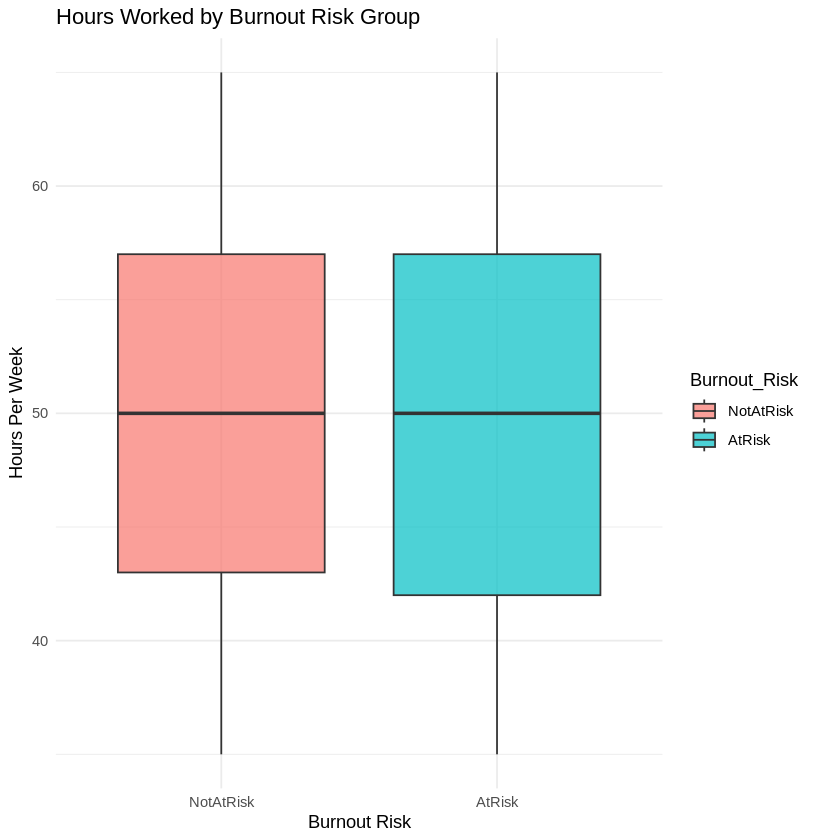

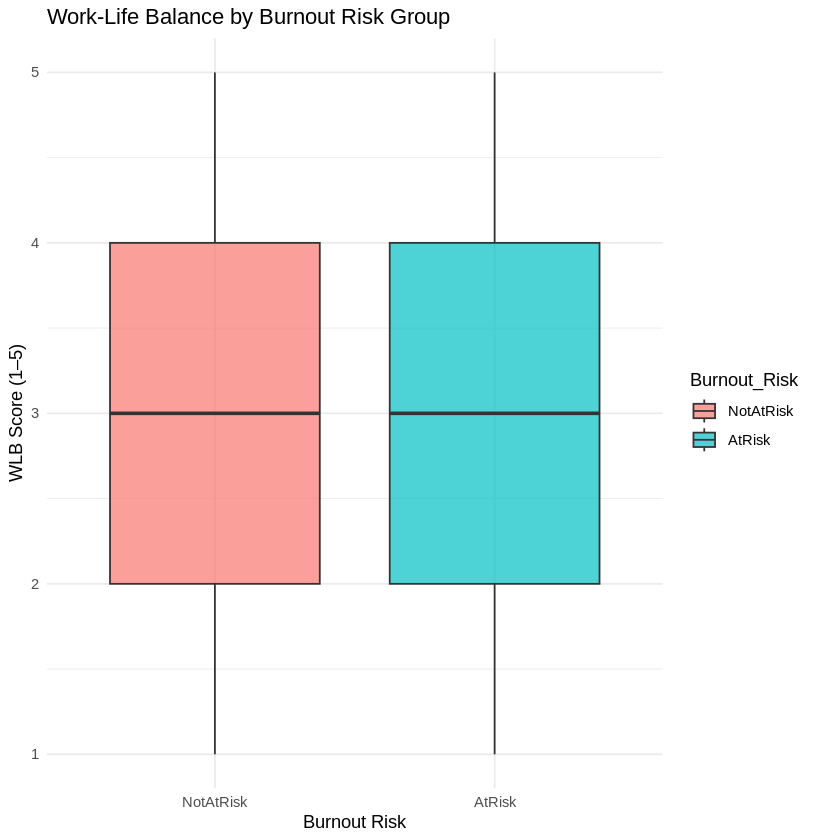

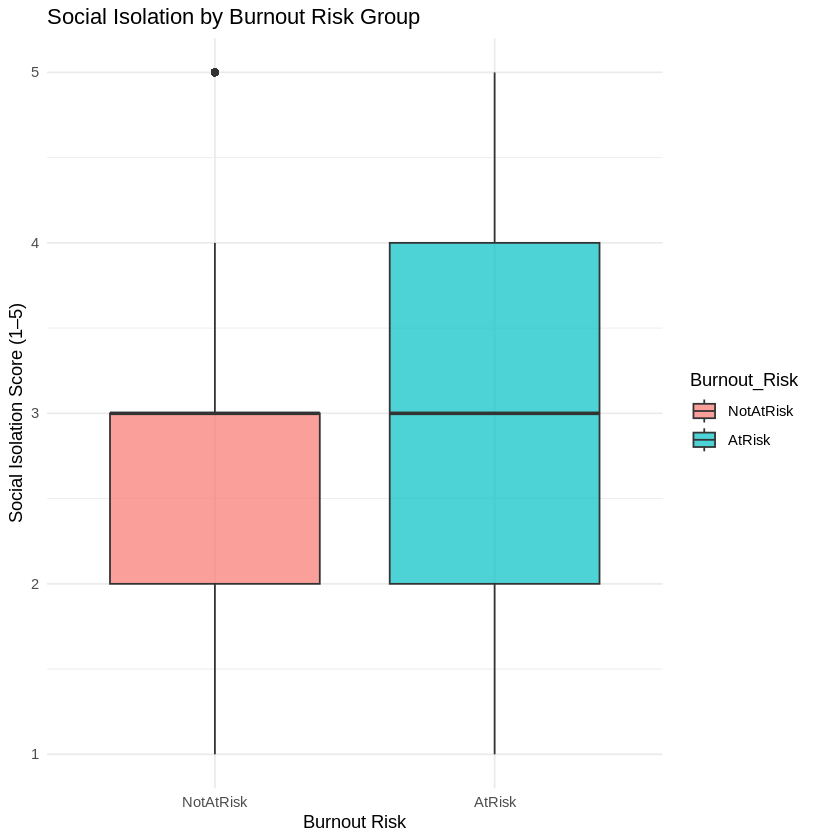

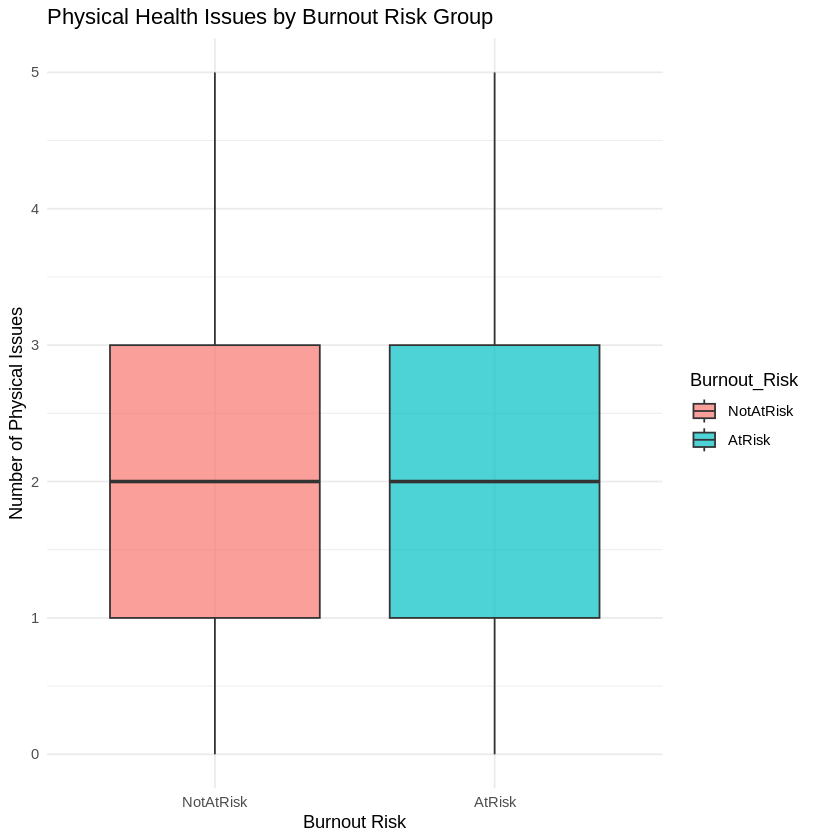

In [ ]:
# 1. Hours vs Burnout_Risk
ggplot(data, aes(x = Burnout_Risk, y = Hours_Per_Week, fill = Burnout_Risk)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Hours Worked by Burnout Risk Group",
       x = "Burnout Risk",
       y = "Hours Per Week") +
  theme_minimal()

# 2. Work-Life Balance vs Burnout_Risk
ggplot(data, aes(x = Burnout_Risk, y = Work_Life_Balance_Score, fill = Burnout_Risk)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Work-Life Balance by Burnout Risk Group",
       x = "Burnout Risk",
       y = "WLB Score (1–5)") +
  theme_minimal()

# 3. Social Isolation vs Burnout_Risk
ggplot(data, aes(x = Burnout_Risk, y = Social_Isolation_Score, fill = Burnout_Risk)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Social Isolation by Burnout Risk Group",
       x = "Burnout Risk",
       y = "Social Isolation Score (1–5)") +
  theme_minimal()

# 4. Physical Issues vs Burnout_Risk
ggplot(data, aes(x = Burnout_Risk, y = Physical_Issue_Count, fill = Burnout_Risk)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Physical Health Issues by Burnout Risk Group",
       x = "Burnout Risk",
       y = "Number of Physical Issues") +
  theme_minimal()


In [ ]:
# Wilcoxon rank-sum tests (Mann–Whitney)
w_hours <- wilcox.test(Hours_Per_Week ~ Burnout_Risk, data = data)
w_wlb   <- wilcox.test(Work_Life_Balance_Score ~ Burnout_Risk, data = data)
w_isol  <- wilcox.test(Social_Isolation_Score ~ Burnout_Risk, data = data)
w_phys  <- wilcox.test(Physical_Issue_Count ~ Burnout_Risk, data = data)

w_hours
w_wlb
w_isol
w_phys



	Wilcoxon rank sum test with continuity correction

data:  Hours_Per_Week by Burnout_Risk
W = 1115067, p-value = 0.6476
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  Work_Life_Balance_Score by Burnout_Risk
W = 1111425, p-value = 0.7513
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  Social_Isolation_Score by Burnout_Risk
W = 1063088, p-value = 0.08016
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  Physical_Issue_Count by Burnout_Risk
W = 1096702, p-value = 0.7507
alternative hypothesis: true location shift is not equal to 0


In [ ]:
# Work arrangement vs Burnout_Risk
table_WA_BR <- table(data$Work_Arrangement, data$Burnout_Risk)
chisq_WA_BR <- chisq.test(table_WA_BR)

table_WA_BR
chisq_WA_BR


        
         NotAtRisk AtRisk
  Hybrid       647    360
  Onsite      1149    413
  Remote       315    273


	Pearson's Chi-squared test

data:  table_WA_BR
X-squared = 81.607, df = 2, p-value < 2.2e-16


In [ ]:
# Tidy Wilcoxon results
tidy_hours <- tidy(w_hours) %>% mutate(Variable = "Hours_Per_Week")
tidy_wlb   <- tidy(w_wlb)   %>% mutate(Variable = "Work_Life_Balance_Score")
tidy_isol  <- tidy(w_isol)  %>% mutate(Variable = "Social_Isolation_Score")
tidy_phys  <- tidy(w_phys)  %>% mutate(Variable = "Physical_Issue_Count")

wilcox_summary <- bind_rows(tidy_hours, tidy_wlb, tidy_isol, tidy_phys) %>%
  dplyr::select(Variable, statistic, p.value)

wilcox_summary

Variable,statistic,p.value
<chr>,<dbl>,<dbl>
Hours_Per_Week,1115067,0.64758227
Work_Life_Balance_Score,1111425,0.75127619
Social_Isolation_Score,1063088,0.08015559
Physical_Issue_Count,1096702,0.75068736


In [ ]:
library(dplyr)
library(broom)

# List of numeric predictors you compared
num_vars <- c("Hours_Per_Week",
              "Work_Life_Balance_Score",
              "Social_Isolation_Score",
              "Physical_Issue_Count")

# Function to run Wilcoxon and tidy the output
run_wilcox <- function(var){
  test <- wilcox.test(data[[var]] ~ data$Burnout_Risk)
  tibble(
    Variable = var,
    W = round(test$statistic, 0),
    p_value = round(test$p.value, 4),
    Interpretation = ifelse(test$p.value < 0.05,
                            "Significant",
                            "Not Significant")
  )
}

# Apply to all variables and combine results
wilcox_table <- bind_rows(lapply(num_vars, run_wilcox))
wilcox_table


Variable,W,p_value,Interpretation
<chr>,<dbl>,<dbl>,<chr>
Hours_Per_Week,1115067,0.6476,Not Significant
Work_Life_Balance_Score,1111425,0.7513,Not Significant
Social_Isolation_Score,1063088,0.0802,Not Significant
Physical_Issue_Count,1096702,0.7507,Not Significant


In [ ]:
tidy_chisq_WA <- tidy(chisq_WA_BR) %>% mutate(Variable = "Work_Arrangement")

chisq_summary <- tidy_chisq_WA %>%
  dplyr::select(Variable, statistic, p.value, parameter)

chisq_summary


Variable,statistic,p.value,parameter
<chr>,<dbl>,<dbl>,<int>
Work_Arrangement,81.60682,1.902412e-18,2



	Pearson's Chi-squared test

data:  tab_WA_BR
X-squared = 81.607, df = 2, p-value < 2.2e-16


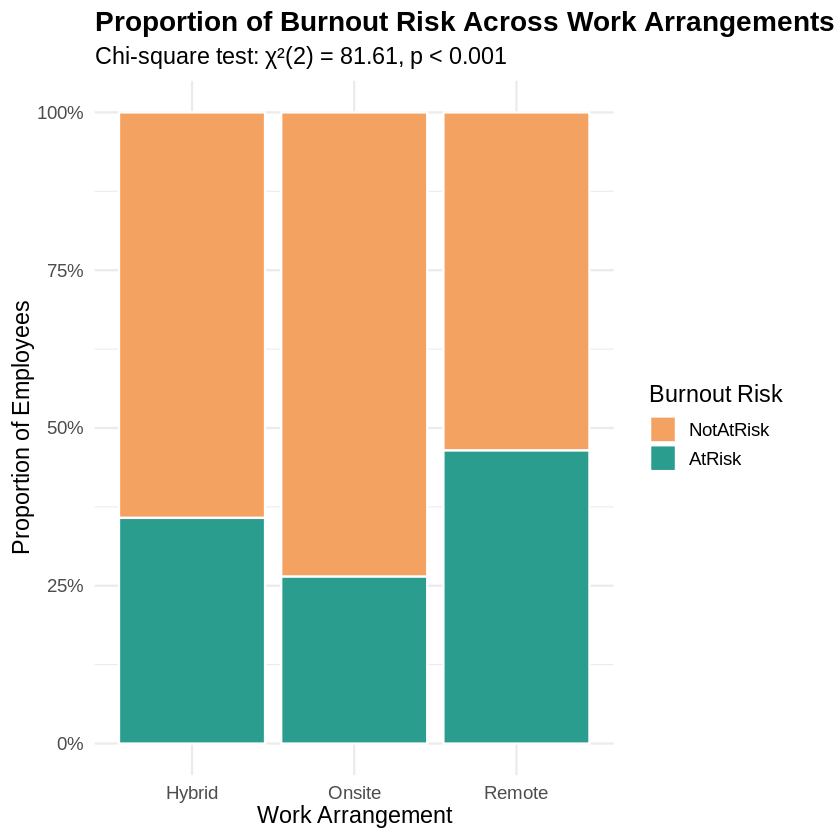

In [ ]:
library(dplyr)
library(ggplot2)
library(scales)

# 1. Contingency table
tab_WA_BR <- table(data$Work_Arrangement, data$Burnout_Risk)

# 2. Chi-square test
chi_WA_BR <- chisq.test(tab_WA_BR)

chi_WA_BR

# 3. Prepare data for ggplot (proportions within each Work Arrangement)
plot_df <- as.data.frame(tab_WA_BR)
colnames(plot_df) <- c("Work_Arrangement", "Burnout_Risk", "Count")

plot_df <- plot_df %>%
  group_by(Work_Arrangement) %>%
  mutate(Proportion = Count / sum(Count))

# 4. Nice label for p-value
p_lab <- ifelse(chi_WA_BR$p.value < 0.001,
                "p < 0.001",
                paste0("p = ", round(chi_WA_BR$p.value, 3)))

# 5. Plot
ggplot(plot_df,
       aes(x = Work_Arrangement,
           y = Proportion,
           fill = Burnout_Risk)) +
  geom_col(color = "white") +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("#f4a261", "#2a9d8f")) +  # optional colors
  labs(
    title    = "Proportion of Burnout Risk Across Work Arrangements",
    subtitle = paste0("Chi-square test: \u03C7\u00B2(",
                      chi_WA_BR$parameter, ") = ",
                      round(chi_WA_BR$statistic, 2), ", ",
                      p_lab),
    x = "Work Arrangement",
    y = "Proportion of Employees",
    fill = "Burnout Risk"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title    = element_text(face = "bold"),
    legend.position = "right"
  )


Work Arrangement is highly significantly associated with burnout risk.
There is almost zero chance that this difference is due to randomness.

Employees in different work arrangements (Onsite, Remote, Hybrid)
have significantly different probabilities of being At Risk of burnout.

In [ ]:
install.packages("MASS")
library(MASS)

# ordinal logistic regression (proportional odds model)
ord_model <- polr(
  Burnout_Level ~ Hours_Per_Week +
                  Work_Life_Balance_Score +
                  Social_Isolation_Score +
                  Physical_Issue_Count +
                  Work_Arrangement,
  data = data,
  Hess = TRUE
)

summary(ord_model)

# Convert coefficients to odds ratios
exp(coef(ord_model))


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Call:
polr(formula = Burnout_Level ~ Hours_Per_Week + Work_Life_Balance_Score + 
    Social_Isolation_Score + Physical_Issue_Count + Work_Arrangement, 
    data = data, Hess = TRUE)

Coefficients:
                            Value Std. Error t value
Hours_Per_Week          -0.002515   0.003736 -0.6733
Work_Life_Balance_Score -0.021825   0.028703 -0.7604
Social_Isolation_Score  -0.038998   0.030036 -1.2984
Physical_Issue_Count     0.012370   0.031648  0.3909
Work_ArrangementOnsite  -0.519548   0.076525 -6.7893
Work_ArrangementRemote   0.450831   0.100271  4.4961

Intercepts:
            Value   Std. Error t value
Low|Medium  -1.6534  0.2410    -6.8605
Medium|High  0.2800  0.2389     1.1720

Residual Deviance: 6632.558 
AIC: 6648.558 

Hours_Per_Week Work_Life_Balance_Score  Social_Isolation_Score 
              0.9974880               0.9784114               0.9617530 
   Physical_Issue_Count  Work_ArrangementOnsite  Work_ArrangementRemote 
              1.0124472               0.5947893               1.5696155

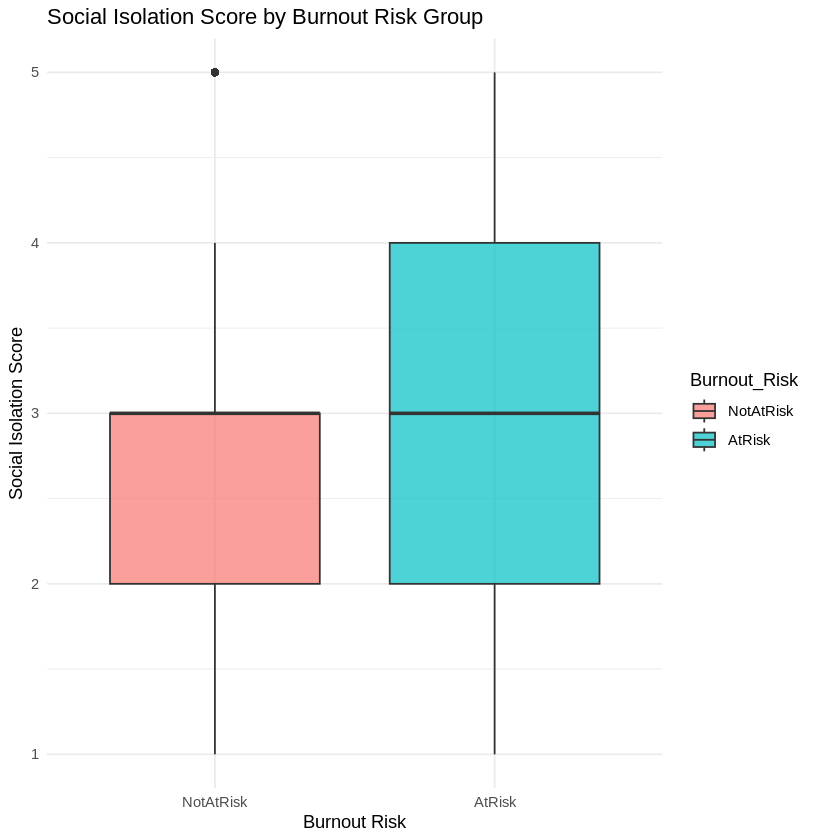

In [ ]:
#Boxplot: Social Isolation Score vs Burnout Risk
ggplot(data, aes(Burnout_Risk, Social_Isolation_Score, fill = Burnout_Risk)) +
  geom_boxplot(alpha = 0.7) +
  labs(title="Social Isolation Score by Burnout Risk Group",
       x="Burnout Risk", y="Social Isolation Score") +
  theme_minimal()


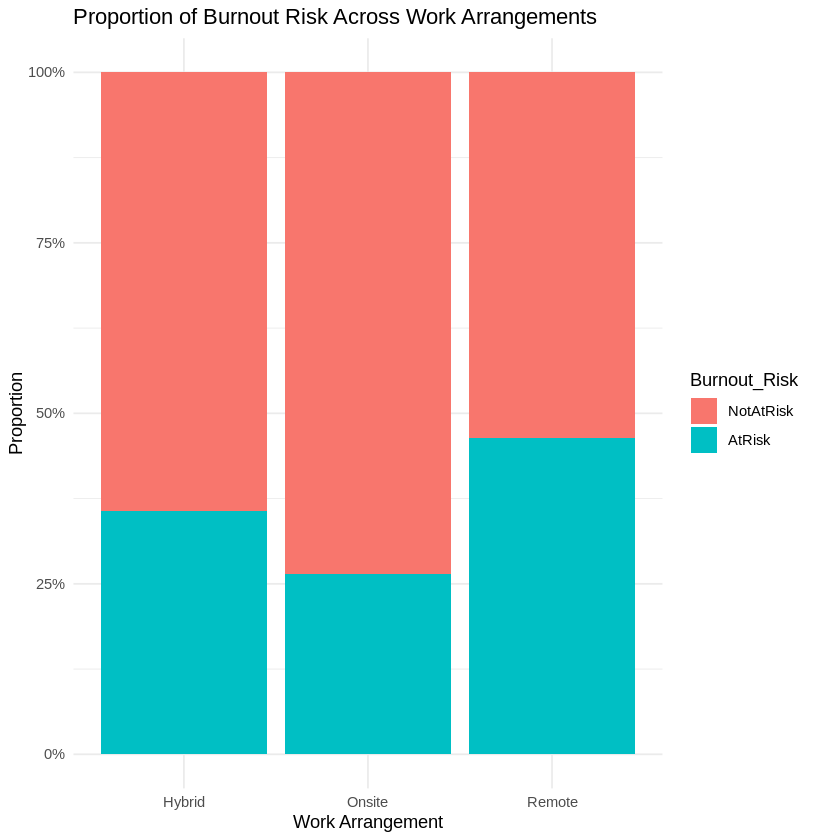

In [ ]:
#Bar Plot: Work Arrangement vs Burnout Risk
ggplot(data, aes(Work_Arrangement, fill = Burnout_Risk)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion of Burnout Risk Across Work Arrangements",
       x = "Work Arrangement", y = "Proportion") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal()


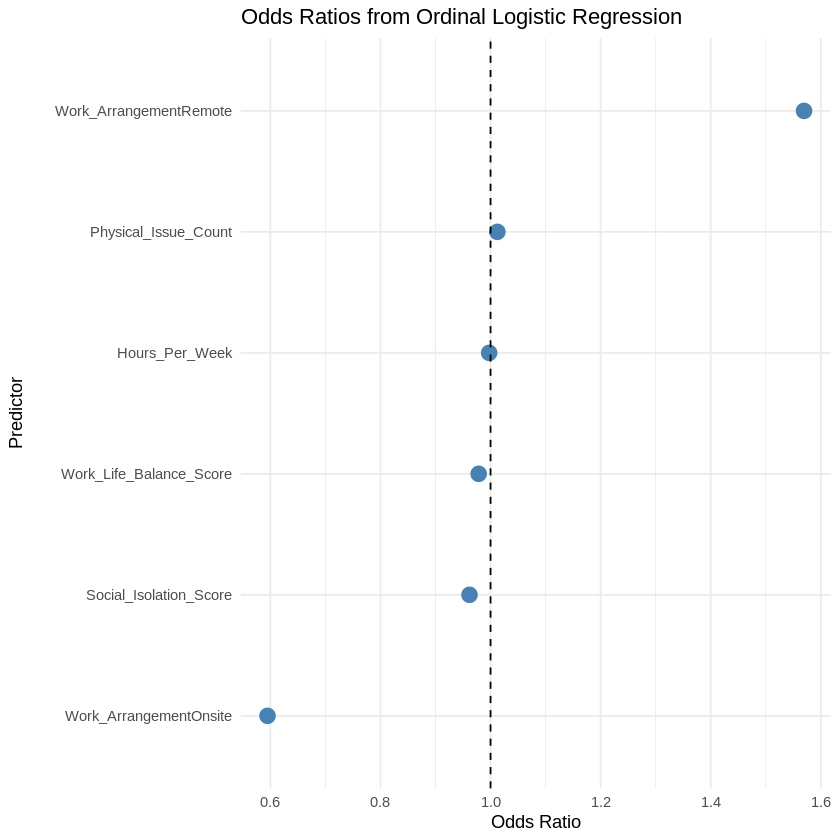

In [ ]:
#Ordinal Logistic Regression Odds Ratios Plot
library(broom)
library(ggplot2)

ord_tidy <- tidy(ord_model) %>% filter(term != "Low|Medium" & term != "Medium|High")
ord_tidy$OR <- exp(ord_tidy$estimate)

ggplot(ord_tidy, aes(x = reorder(term, OR), y = OR)) +
  geom_point(size=4, color="steelblue") +
  geom_hline(yintercept = 1, linetype = "dashed") +
  coord_flip() +
  labs(title="Odds Ratios from Ordinal Logistic Regression",
       x="Predictor", y="Odds Ratio") +
  theme_minimal()


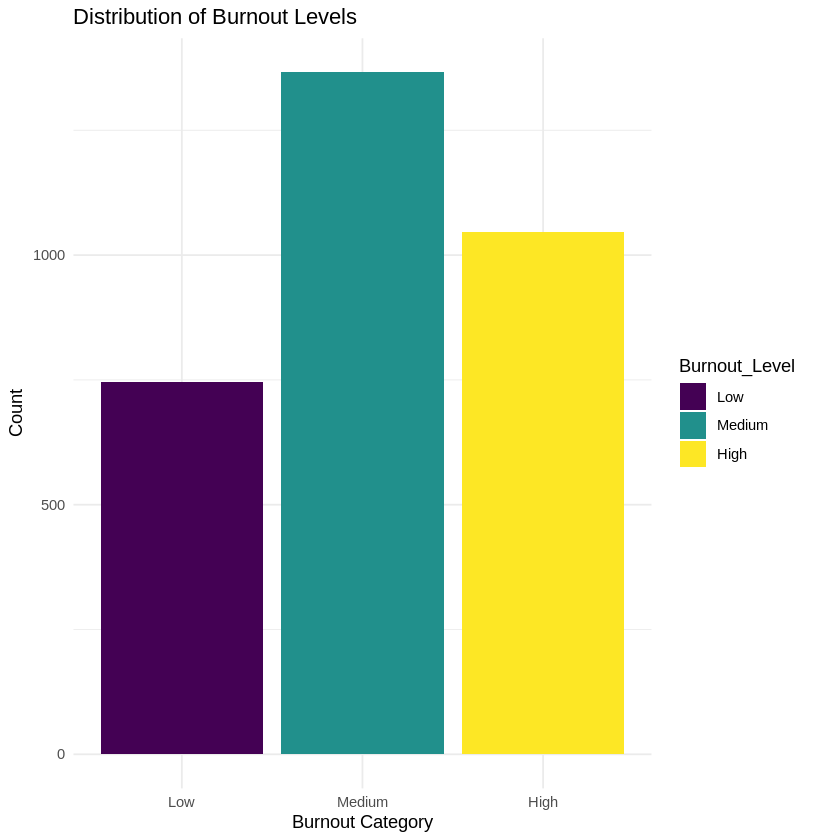

In [ ]:
ggplot(data, aes(Burnout_Level, fill = Burnout_Level)) +
  geom_bar() +
  labs(title="Distribution of Burnout Levels",
       x="Burnout Category", y="Count") +
  theme_minimal()


# RQ 3- Does work arrangement influence work life balance and social isolation?


### EDA

In [ ]:
install.packages("FSA")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘colorspace’, ‘fracdiff’, ‘timeDate’, ‘tseries’, ‘urca’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘Rdpack’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘zoo’, ‘car’, ‘dunn.test’, ‘FlexParamCurve’, ‘lmtest’, ‘plotrix’




In [ ]:
# Remove rows with missing values in the variables used for RQ2
rq2_vars <- c("Work_Arrangement", "Work_Life_Balance_Score", "Social_Isolation_Score")
data_rq2 <- data[complete.cases(data[, rq2_vars]), rq2_vars]

# Check structure after preprocessing
str(data_rq2)
summary(data_rq2)

'data.frame':	3157 obs. of  3 variables:
 $ Work_Arrangement       : Factor w/ 3 levels "Hybrid","Onsite",..: 2 2 2 2 1 2 2 2 3 2 ...
 $ Work_Life_Balance_Score: int  3 4 3 1 5 4 4 3 2 5 ...
 $ Social_Isolation_Score : int  2 2 2 2 4 3 2 2 4 1 ...


 Work_Arrangement Work_Life_Balance_Score Social_Isolation_Score
 Hybrid:1007      Min.   :1.000           Min.   :1.000         
 Onsite:1562      1st Qu.:2.000           1st Qu.:2.000         
 Remote: 588      Median :3.000           Median :3.000         
                  Mean   :2.997           Mean   :2.705         
                  3rd Qu.:4.000           3rd Qu.:4.000         
                  Max.   :5.000           Max.   :5.000         

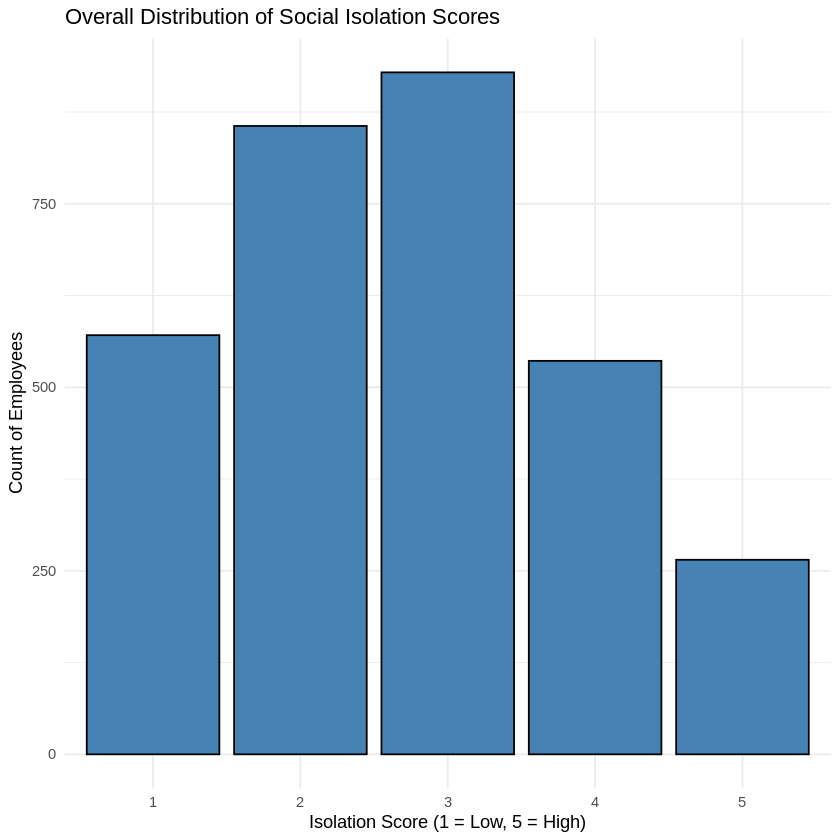

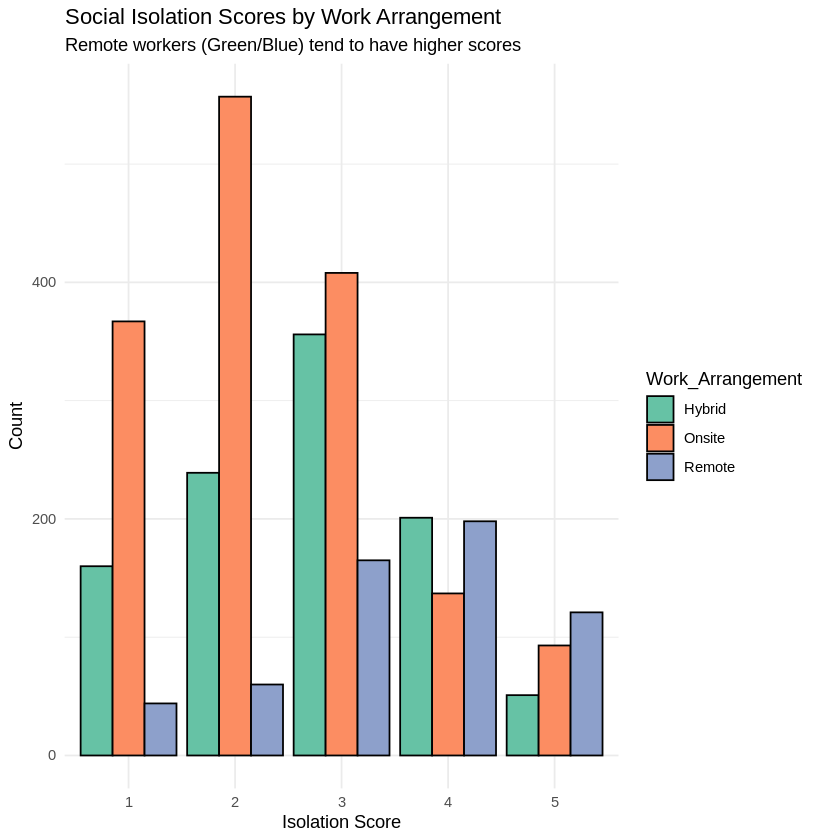

In [ ]:
library(ggplot2)

# A. Simple Overall Distribution
ggplot(data_rq2, aes(x = as.factor(Social_Isolation_Score))) +
  geom_bar(fill = "steelblue", color = "black") +
  labs(title = "Overall Distribution of Social Isolation Scores",
       x = "Isolation Score (1 = Low, 5 = High)",
       y = "Count of Employees") +
  theme_minimal()

# B. Distribution Split by Work Arrangement (Best for your Report)
ggplot(data_rq2, aes(x = as.factor(Social_Isolation_Score), fill = Work_Arrangement)) +
  geom_bar(position = "dodge", color = "black") +
  labs(title = "Social Isolation Scores by Work Arrangement",
       subtitle = "Remote workers (Green/Blue) tend to have higher scores",
       x = "Isolation Score",
       y = "Count") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set2") # Optional: Nice color palette

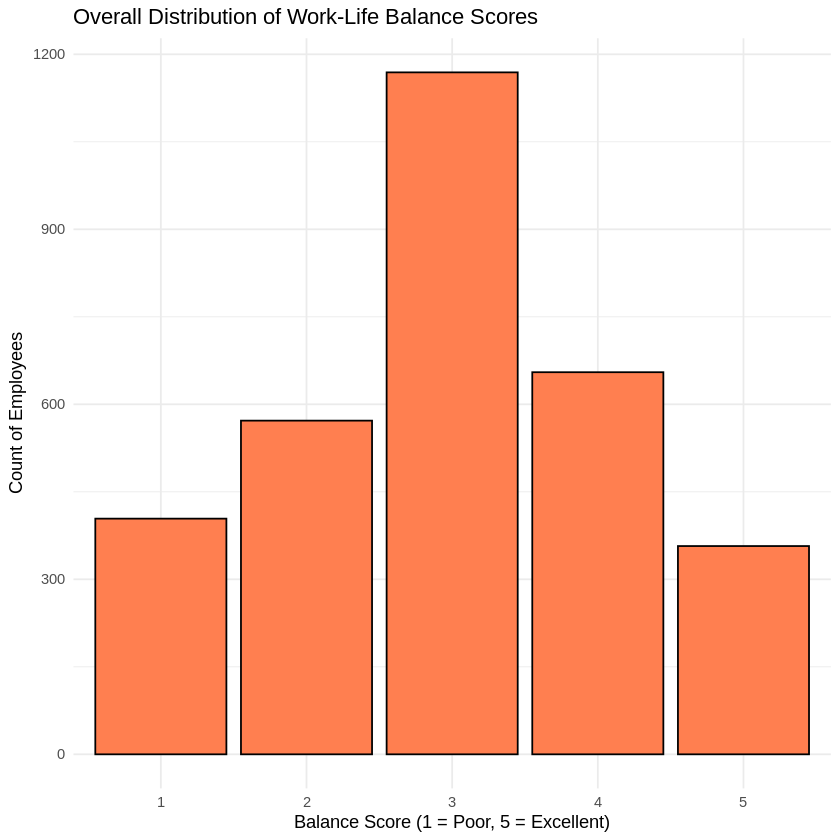

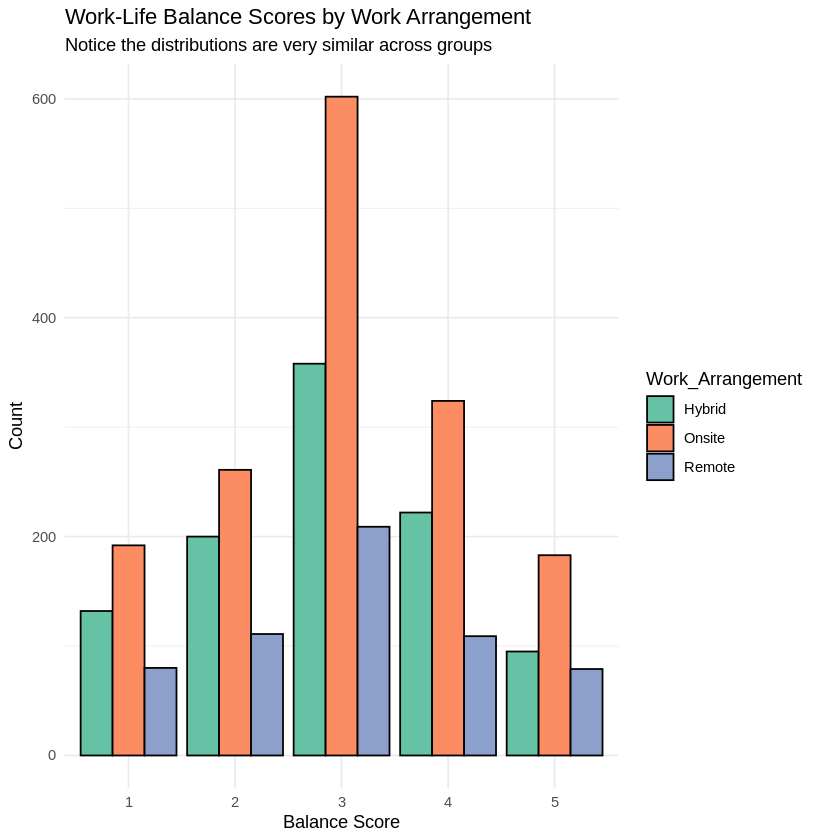

In [ ]:
# A. Simple Overall Distribution
ggplot(data_rq2, aes(x = as.factor(Work_Life_Balance_Score))) +
  geom_bar(fill = "coral", color = "black") +
  labs(title = "Overall Distribution of Work-Life Balance Scores",
       x = "Balance Score (1 = Poor, 5 = Excellent)",
       y = "Count of Employees") +
  theme_minimal()

# B. Distribution Split by Work Arrangement
ggplot(data_rq2, aes(x = as.factor(Work_Life_Balance_Score), fill = Work_Arrangement)) +
  geom_bar(position = "dodge", color = "black") +
  labs(title = "Work-Life Balance Scores by Work Arrangement",
       subtitle = "Notice the distributions are very similar across groups",
       x = "Balance Score",
       y = "Count") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set2")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




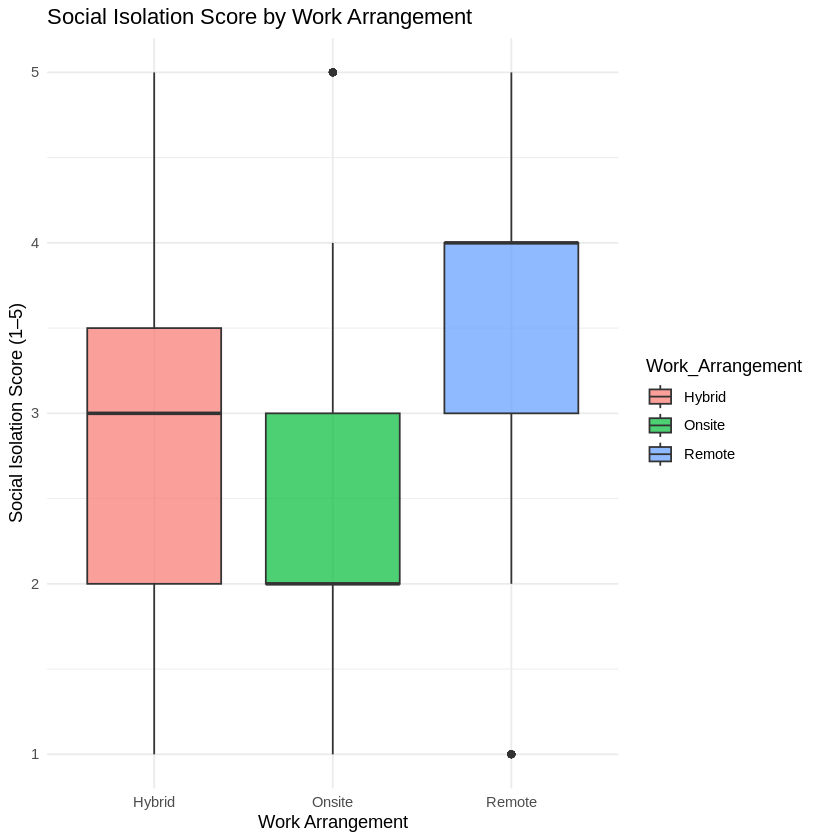

In [ ]:
library(ggplot2)
library(dplyr)

# Convert to numeric for plotting
data$ISO_num <- as.numeric(data$Social_Isolation_Score)

ggplot(data, aes(x = Work_Arrangement, y = ISO_num, fill = Work_Arrangement)) +
  geom_boxplot(alpha = 0.7) +
  scale_y_continuous(breaks = 1:5) +
  labs(
    title = "Social Isolation Score by Work Arrangement",
    x = "Work Arrangement",
    y = "Social Isolation Score (1–5)"
  ) +
  theme_minimal()


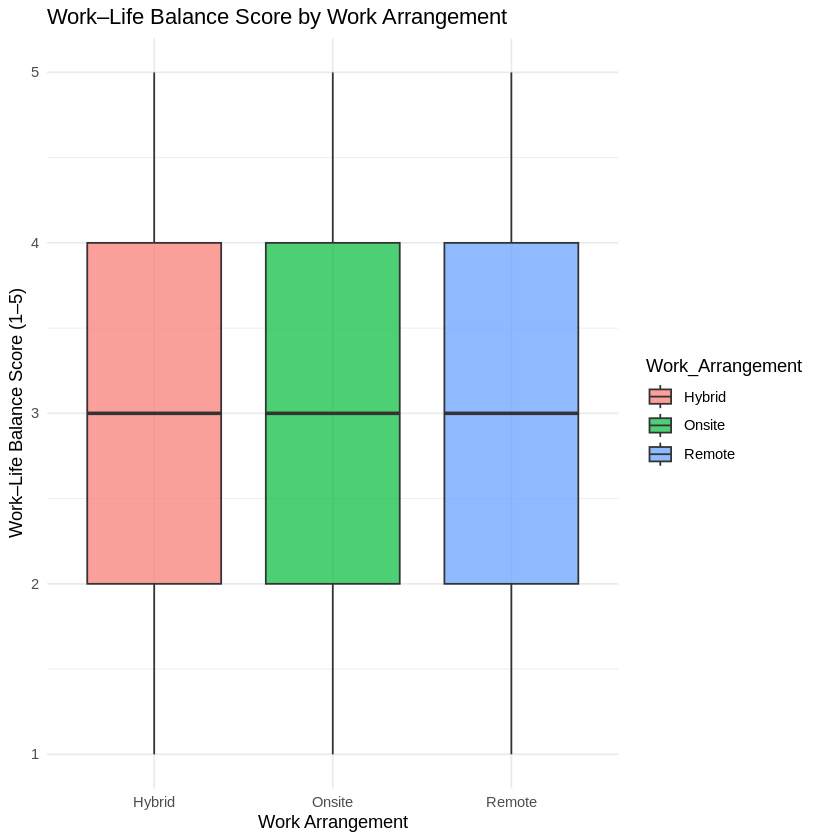

In [ ]:
data$WLB_num <- as.numeric(data$Work_Life_Balance_Score)


ggplot(data, aes(x = Work_Arrangement, y = WLB_num, fill = Work_Arrangement)) +
 geom_boxplot(alpha = 0.7) +
 scale_y_continuous(breaks = 1:5) +
 labs(
   title = "Work–Life Balance Score by Work Arrangement",
   x = "Work Arrangement",
   y = "Work–Life Balance Score (1–5)"
 ) +
 theme_minimal()

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



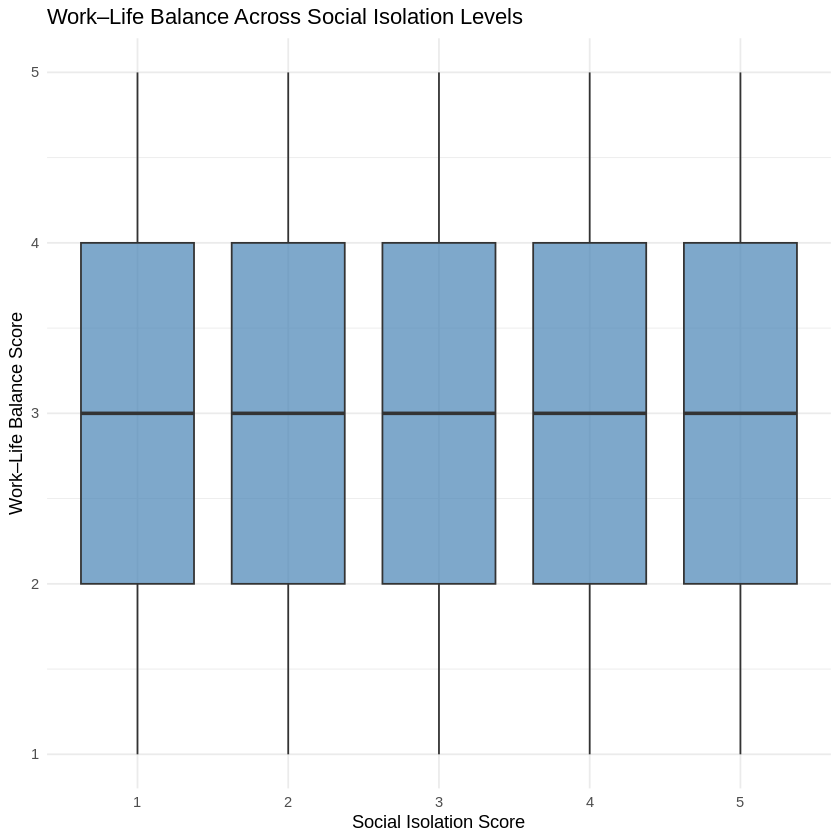

In [ ]:
# Install required packages (run once)
install.packages("ggplot2")

# Load library
library(ggplot2)

# Ensure variables are treated correctly
data$Social_Isolation_Score <- factor(
  data$Social_Isolation_Score,
  levels = 1:5,
  ordered = TRUE
)

# Boxplot
ggplot(data, aes(x = Social_Isolation_Score, y = Work_Life_Balance_Score)) +
  geom_boxplot(fill = "steelblue", alpha = 0.7) +
  labs(
    title = "Work–Life Balance Across Social Isolation Levels",
    x = "Social Isolation Score",
    y = "Work–Life Balance Score"
  ) +
  theme_minimal()


## Methods

### Method 1: Kruskal–Wallis test

H0​:All population distributions are identical.

H1​:At least one population distribution differs.

In [ ]:
# Kruskal–Wallis test for Work–Life Balance Score
kruskal.test(Work_Life_Balance_Score ~ Work_Arrangement, data = data_rq2)
# Kruskal–Wallis test for Social Isolation Score
kruskal.test(Social_Isolation_Score ~ Work_Arrangement, data = data_rq2)


	Kruskal-Wallis rank sum test

data:  Work_Life_Balance_Score by Work_Arrangement
Kruskal-Wallis chi-squared = 2.8094, df = 2, p-value = 0.2454



	Kruskal-Wallis rank sum test

data:  Social_Isolation_Score by Work_Arrangement
Kruskal-Wallis chi-squared = 382.42, df = 2, p-value < 2.2e-16


### Method 2: Dunn Post-Hoc Test

In [ ]:
# Post-hoc Dunn test for Social Isolation Score
library(FSA)

dunnTest(Social_Isolation_Score ~ Work_Arrangement,
         data = data_rq2,
         method = "bonferroni")

## FSA v0.10.0. See citation('FSA') if used in publication.
## Run fishR() for related website and fishR('IFAR') for related book.

Dunn (1964) Kruskal-Wallis multiple comparison

  p-values adjusted with the Bonferroni method.




       Comparison         Z      P.unadj        P.adj
1 Hybrid - Onsite   8.39938 4.488428e-17 1.346528e-16
2 Hybrid - Remote -11.57868 5.285220e-31 1.585566e-30
3 Onsite - Remote -19.43661 3.783689e-84 1.135107e-83

### Method 3: Ordinal Logistic Regression

In [ ]:
# Convert the outcome to an ordered factor
data_rq2$Social_Isolation_Score <- ordered(
  data_rq2$Social_Isolation_Score,
  levels = sort(unique(data_rq2$Social_Isolation_Score))
)
str(data_rq2$Social_Isolation_Score)

 Ord.factor w/ 5 levels "1"<"2"<"3"<"4"<..: 2 2 2 2 4 3 2 2 4 1 ...


In [ ]:
# Install if needed: install.packages("MASS")
library(MASS)

model_iso <- polr(Social_Isolation_Score ~ Work_Arrangement,
                  data = data_rq2,
                  Hess = TRUE)

summary(model_iso)

# Compute p-values
ct_iso <- coef(summary(model_iso))
p_values_iso <- 2 * (1 - pnorm(abs(ct_iso[, "t value"])))
cbind(ct_iso, "p value" = p_values_iso)

# Odds ratios + 95% CI
exp(coef(model_iso))
exp(confint(model_iso))



Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select




Call:
polr(formula = Social_Isolation_Score ~ Work_Arrangement, data = data_rq2, 
    Hess = TRUE)

Coefficients:
                         Value Std. Error t value
Work_ArrangementOnsite -0.6462    0.07321  -8.826
Work_ArrangementRemote  1.2048    0.09569  12.591

Intercepts:
    Value    Std. Error t value 
1|2  -1.7513   0.0684   -25.6184
2|3  -0.3428   0.0592    -5.7937
3|4   1.0896   0.0623    17.4850
4|5   2.5170   0.0824    30.5598

Residual Deviance: 9255.991 
AIC: 9267.991 

,Value,Std. Error,t value,p value
Work_ArrangementOnsite,-0.6461522,0.07321331,-8.825611,0.000000e+00
Work_ArrangementRemote,1.2048111,0.09568549,12.591367,0.000000e+00
1|2,-1.7512830,0.06836049,-25.618351,0.000000e+00
2|3,-0.3427593,0.05916058,-5.793711,6.884791e-09
3|4,1.0895636,0.06231417,17.485006,0.000000e+00
4|5,2.5170292,0.08236419,30.559752,0.000000e+00


Work_ArrangementOnsite Work_ArrangementRemote 
             0.5240584              3.3361289

Waiting for profiling to be done...



,2.5 %,97.5 %
Work_ArrangementOnsite,0.4539035,0.6048035
Work_ArrangementRemote,2.7669248,4.0263851


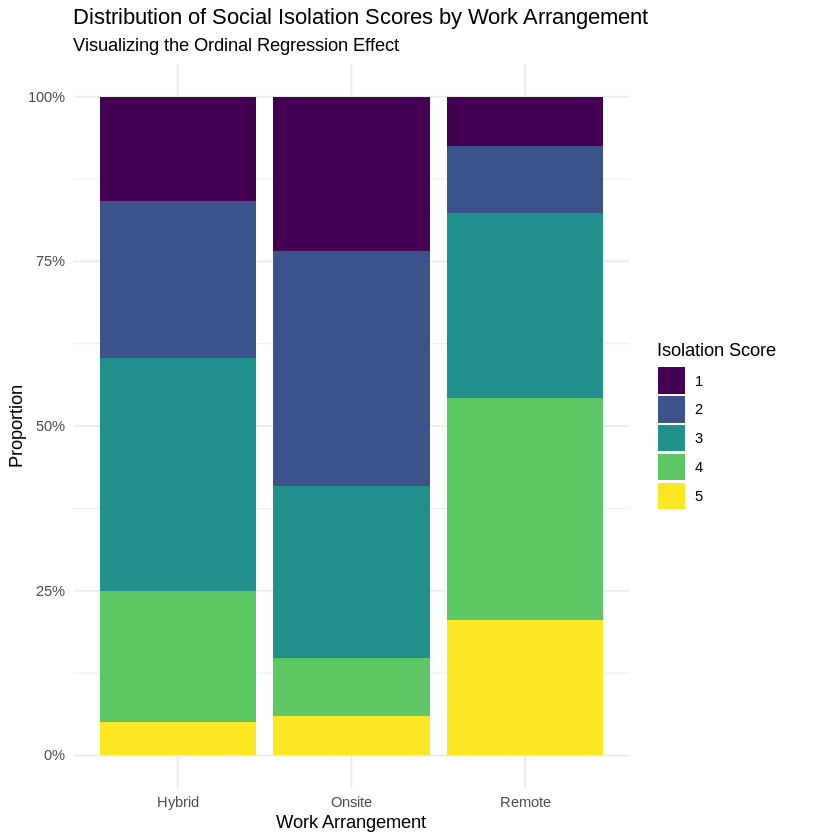

In [ ]:
# Load necessary libraries
library(ggplot2)
library(dplyr)
library(scales) # For formatting percentages

# 1. Prepare the data: Calculate counts and percentages
plot_data <- data_rq2 %>%
  count(Work_Arrangement, Social_Isolation_Score) %>%
  group_by(Work_Arrangement) %>%
  mutate(percentage = n / sum(n))

# 2. Create the Stacked Bar Chart
ggplot(plot_data, aes(x = Work_Arrangement, y = percentage, fill = as.factor(Social_Isolation_Score))) +
  geom_bar(stat = "identity", position = "fill") + # 'fill' stacks bars to 100%
  scale_y_continuous(labels = percent) +           # Format y-axis as %
  scale_fill_viridis_d(option = "viridis") +       # Optional: Use a nice color palette (requires viridis package or remove this line)
  labs(
    title = "Distribution of Social Isolation Scores by Work Arrangement",
    subtitle = "Visualizing the Ordinal Regression Effect",
    x = "Work Arrangement",
    y = "Proportion",
    fill = "Isolation Score"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

### Method 4: Ordinal Logistic Regression- Add More Predictors

In [ ]:
# If they're stored as numbers 1–5
data$Work_Life_Balance_Score <- ordered(
  data$Work_Life_Balance_Score,
  levels = sort(unique(data$Work_Life_Balance_Score))
)

data$Social_Isolation_Score <- ordered(
  data$Social_Isolation_Score,
  levels = sort(unique(data$Social_Isolation_Score))
)


In [ ]:
# Multivariable Ordinal Logistic Regression
# We add Age, Gender, and Hours_Per_Week to the formula
model_iso_multi <- polr(Social_Isolation_Score ~ Work_Arrangement + Age + Gender + Hours_Per_Week,
                        data = data,
                        Hess = TRUE)

summary(model_iso_multi)

# Check p-values again
ct_multi <- coef(summary(model_iso_multi))
p_values_multi <- 2 * (1 - pnorm(abs(ct_multi[, "t value"])))
cbind(ct_multi, "p value" = p_values_multi)

# Compare models (AIC) to see if adding variables improved the model
AIC(model_iso, model_iso_multi)

Call:
polr(formula = Social_Isolation_Score ~ Work_Arrangement + Age + 
    Gender + Hours_Per_Week, data = data, Hess = TRUE)

Coefficients:
                             Value Std. Error t value
Work_ArrangementOnsite  -0.6441419   0.073254 -8.7933
Work_ArrangementRemote   1.2058351   0.095720 12.5975
Age                     -0.0012276   0.002525 -0.4862
GenderMale               0.0417677   0.065111  0.6415
GenderNon-binary        -0.0811083   0.194786 -0.4164
GenderPrefer not to say  0.0517675   0.319788  0.1619
Hours_Per_Week          -0.0009768   0.003567 -0.2739

Intercepts:
    Value   Std. Error t value
1|2 -1.8342  0.2229    -8.2298
2|3 -0.4256  0.2202    -1.9330
3|4  1.0071  0.2207     4.5622
4|5  2.4351  0.2269    10.7319

Residual Deviance: 9254.941 
AIC: 9276.941 

,Value,Std. Error,t value,p value
Work_ArrangementOnsite,-0.6441418905,0.073254048,-8.7932600,0.000000e+00
Work_ArrangementRemote,1.2058350965,0.095720377,12.5974754,0.000000e+00
Age,-0.0012275974,0.002524779,-0.4862198,6.268113e-01
GenderMale,0.0417676570,0.065110550,0.6414883,5.212055e-01
GenderNon-binary,-0.0811082870,0.194786075,-0.4163967,6.771197e-01
GenderPrefer not to say,0.0517674829,0.319787602,0.1618808,8.713997e-01
Hours_Per_Week,-0.0009768333,0.003566887,-0.2738616,7.841910e-01
1|2,-1.8342164468,0.222876053,-8.2297601,2.220446e-16
2|3,-0.4256086971,0.220177551,-1.9330249,5.323313e-02
3|4,1.0070969577,0.220746925,4.5622242,5.061456e-06


,df,AIC
,<dbl>,<dbl>
model_iso,6,9267.991
model_iso_multi,11,9276.941


# RQ 4 - Does the optimal number of working hours for job satisfaction differ by burnout level?

In [ ]:
# Satisfaction proxy variable (rename for clarity if you want)
data$Work_Life_Balance_Score <- as.numeric(data$Work_Life_Balance_Score)

# Convert Hours properly
data$Hours_Per_Week <- as.numeric(data$Hours_Per_Week)

# Convert burnout
data$Burnout_Level <- factor(data$Burnout_Level,
                             levels = c("Low","Medium","High"),
                             ordered = TRUE)

# Work Arrangement
data$Work_Arrangement <- factor(data$Work_Arrangement)

# Quadratic term
data$Hours_Sq <- data$Hours_Per_Week^2


In [ ]:
data$Job_Satisfaction <- data$Work_Life_Balance_Score

In [ ]:
quad_model <- lm(Job_Satisfaction ~ Hours_Per_Week + Hours_Sq, data = data)
summary(quad_model)


Call:
lm(formula = Job_Satisfaction ~ Hours_Per_Week + Hours_Sq, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.04137 -0.98167  0.01231  0.99673  2.02094 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     3.3576786  0.7103833   4.727 2.38e-06 ***
Hours_Per_Week -0.0128581  0.0290412  -0.443    0.658    
Hours_Sq        0.0001092  0.0002896   0.377    0.706    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.164 on 3154 degrees of freedom
Multiple R-squared:  0.0002664,	Adjusted R-squared:  -0.0003675 
F-statistic: 0.4203 on 2 and 3154 DF,  p-value: 0.6569


In [ ]:
interaction_burnout <- lm(
  Job_Satisfaction ~ Hours_Per_Week * Burnout_Level + Hours_Sq * Burnout_Level,
  data = data
)
summary(interaction_burnout)


Call:
lm(formula = Job_Satisfaction ~ Hours_Per_Week * Burnout_Level + 
    Hours_Sq * Burnout_Level, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.29681 -0.97311  0.01814  1.00123  2.09666 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     3.6821901  0.7292623   5.049 4.69e-07 ***
Hours_Per_Week                 -0.0253495  0.0298076  -0.850   0.3951    
Burnout_Level.L                -2.6554177  1.3435793  -1.976   0.0482 *  
Burnout_Level.Q                 1.3875504  1.1771727   1.179   0.2386    
Hours_Sq                        0.0002287  0.0002972   0.769   0.4417    
Hours_Per_Week:Burnout_Level.L  0.1061519  0.0549099   1.933   0.0533 .  
Hours_Per_Week:Burnout_Level.Q -0.0522448  0.0481235  -1.086   0.2777    
Burnout_Level.L:Hours_Sq       -0.0010459  0.0005475  -1.910   0.0562 .  
Burnout_Level.Q:Hours_Sq        0.0004905  0.0004798   1.022   0.3068    
---
Signif. codes:  0 ‘**

In [ ]:
interaction_work <- lm(
  Job_Satisfaction ~ Hours_Per_Week * Work_Arrangement + Hours_Sq * Work_Arrangement,
  data = data
)
summary(interaction_work)


Call:
lm(formula = Job_Satisfaction ~ Hours_Per_Week * Work_Arrangement + 
    Hours_Sq * Work_Arrangement, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.15162 -0.95174  0.01368  0.96702  2.18401 

Coefficients:
                                        Estimate Std. Error t value Pr(>|t|)   
(Intercept)                            3.9303450  1.2993853   3.025  0.00251 **
Hours_Per_Week                        -0.0410826  0.0530960  -0.774  0.43914   
Work_ArrangementOnsite                -0.2525268  1.6306327  -0.155  0.87694   
Work_ArrangementRemote                -2.6889945  2.1157599  -1.271  0.20385   
Hours_Sq                               0.0004164  0.0005299   0.786  0.43211   
Hours_Per_Week:Work_ArrangementOnsite  0.0217403  0.0666631   0.326  0.74435   
Hours_Per_Week:Work_ArrangementRemote  0.1048935  0.0864172   1.214  0.22491   
Work_ArrangementOnsite:Hours_Sq       -0.0002933  0.0006651  -0.441  0.65927   
Work_ArrangementRemote:Hours_Sq       -

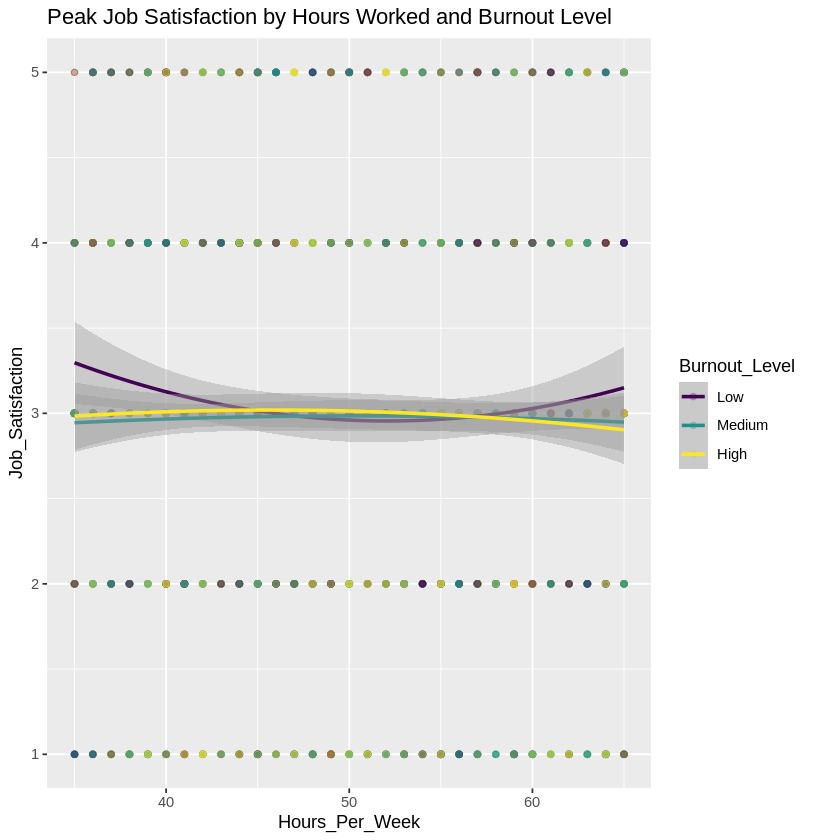

In [ ]:
library(ggplot2)

ggplot(data, aes(Hours_Per_Week, Job_Satisfaction, color = Burnout_Level)) +
  geom_point(alpha = .3) +
  geom_smooth(method = "lm", formula = y ~ poly(x, 2)) +
  ggtitle("Peak Job Satisfaction by Hours Worked and Burnout Level")

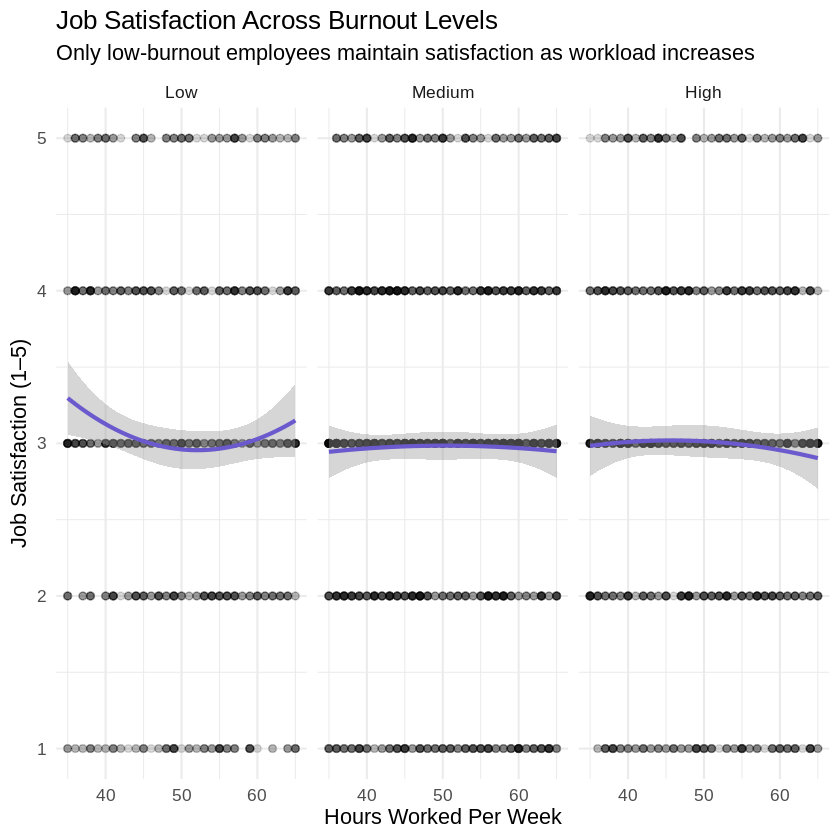

In [ ]:
library(ggplot2)

ggplot(data, aes(Hours_Per_Week, Job_Satisfaction)) +
  geom_point(alpha = .15) +
  geom_smooth(method = "lm", formula = y ~ poly(x, 2), color = "#6A5ACD") +
  facet_wrap(~ Burnout_Level) +
  labs(
    title = "Job Satisfaction Across Burnout Levels",
    subtitle = "Only low-burnout employees maintain satisfaction as workload increases",
    x = "Hours Worked Per Week",
    y = "Job Satisfaction (1–5)"
  ) +
  theme_minimal(base_size = 13)

`geom_smooth()` using formula = 'y ~ x'


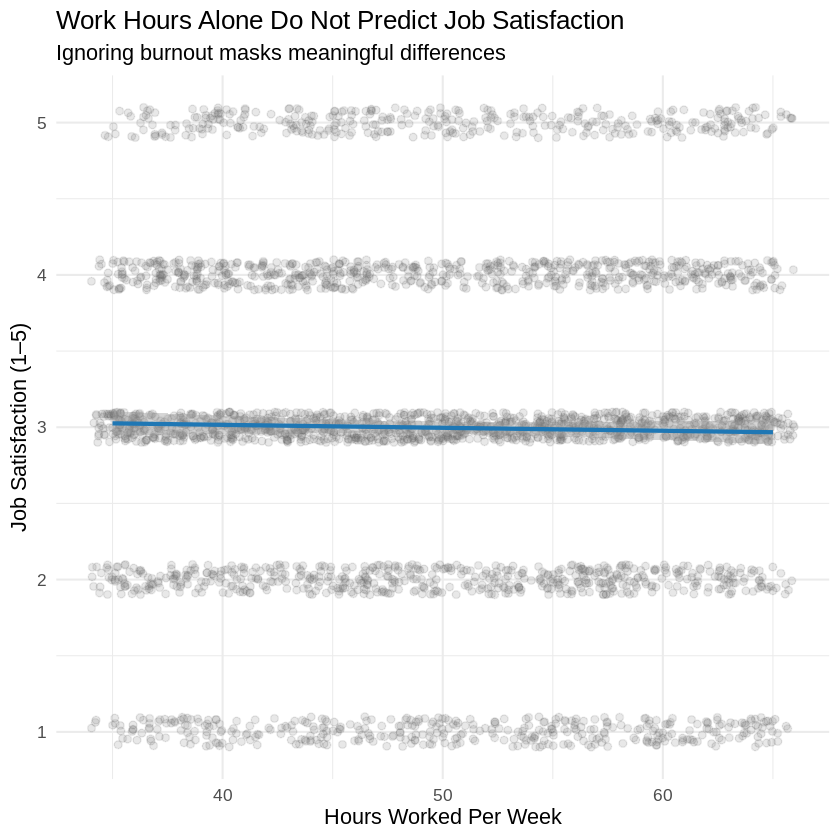

In [ ]:
library(ggplot2)

ggplot(data, aes(x = Hours_Per_Week, y = Job_Satisfaction)) +
  geom_jitter(alpha = 0.15, width = 1, height = 0.1, color = "gray40") +
  geom_smooth(method = "lm", se = TRUE, color = "#1f77b4", linewidth = 1.2) +
  labs(
    title = "Work Hours Alone Do Not Predict Job Satisfaction",
    subtitle = "Ignoring burnout masks meaningful differences",
    x = "Hours Worked Per Week",
    y = "Job Satisfaction (1–5)"
  ) +
  theme_minimal(base_size = 13)

#RQ 5 - Which factors predict whether employees thrive?

## Model A

### Setup

In [ ]:

install.packages("tidyverse")
install.packages("caret")
install.packages("pROC")
library(pROC)
library(tidyverse)
library(caret)

#binary outcome: 1 = Thriving, 0 = NotThriving
data <- data %>%
  mutate(
    Thriving_bin = ifelse(Thriving == "Thriving", 1, 0),
    Thriving_bin = factor(Thriving_bin, levels = c(0, 1))
  )

table(data$Thriving_bin)

make_split <- function(df, outcome = "Thriving_bin", p = 0.7, seed = 123){
  set.seed(seed)
  idx <- createDataPartition(df[[outcome]], p = p, list = FALSE)
  list(
    train = df[idx, ],
    test  = df[-idx, ]
  )
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




   0    1 
2885  272 

0 = NotThriving (2885 people)

1 = Thriving (272 people)

### Predict thriving from internal well-being factors

In [ ]:
# Model A predictors: internal well-being +  workload
predictors_A <- c(
  "Burnout_Score",
  "Work_Life_Balance_Score",
  "Social_Isolation_Score",
  "Mental_Health_Flag",
  "Hours_Per_Week",
  "Age",
  "Work_Arrangement"
)

# Build modeling dataframe for Model A
model_A_df <- data %>%
  dplyr::select(Thriving_bin, dplyr::all_of(predictors_A)) %>%
  tidyr::drop_na()

# Check
str(model_A_df)
table(model_A_df$Thriving_bin)

#Train–test split for Model A
set.seed(123)
train_idx_A <- createDataPartition(model_A_df$Thriving_bin, p = 0.7, list = FALSE)
train_A <- model_A_df[train_idx_A, ]
test_A  <- model_A_df[-train_idx_A, ]

# Check class balance in train/test
table(train_A$Thriving_bin)
table(test_A$Thriving_bin)


'data.frame':	3157 obs. of  8 variables:
 $ Thriving_bin           : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 2 1 1 1 ...
 $ Burnout_Score          : num  3 3 3 2 2 2 2 3 2 2 ...
 $ Work_Life_Balance_Score: int  3 4 3 1 5 4 4 3 2 5 ...
 $ Social_Isolation_Score : int  2 2 2 2 4 3 2 2 4 1 ...
 $ Mental_Health_Flag     : Factor w/ 2 levels "NoCondition",..: 2 2 2 2 1 2 1 2 2 2 ...
 $ Hours_Per_Week         : num  64 37 36 63 65 61 62 55 47 55 ...
 $ Age                    : num  27 37 32 40 30 52 50 63 30 37 ...
 $ Work_Arrangement       : Factor w/ 3 levels "Hybrid","Onsite",..: 2 2 2 2 1 2 2 2 3 2 ...



   0    1 
2885  272 


   0    1 
2020  191 


  0   1 
865  81 

####Logistic Regression Model

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = Thriving_bin ~ ., family = binomial, data = train_A)

Coefficients:
                                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)                      4.572867   1.212237   3.772 0.000162 ***
Burnout_Score                   -2.426233   0.243527  -9.963  < 2e-16 ***
Work_Life_Balance_Score          1.299759   0.147837   8.792  < 2e-16 ***
Social_Isolation_Score          -1.276900   0.155194  -8.228  < 2e-16 ***
Mental_Health_FlagHasCondition -24.296457 929.167927  -0.026 0.979139    
Hours_Per_Week                  -0.007284   0.015063  -0.484 0.628683    
Age                             -0.007770   0.009904  -0.784 0.432759    
Work_ArrangementOnsite          -0.513738   0.291288  -1.764 0.077786 .  
Work_ArrangementRemote          -0.943561   0.406535  -2.321 0.020288 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1300.49  on 2210  degrees 

Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 846  25
         1  19  56
                                         
               Accuracy : 0.9535         
                 95% CI : (0.9381, 0.966)
    No Information Rate : 0.9144         
    P-Value [Acc > NIR] : 2.241e-06      
                                         
                  Kappa : 0.6926         
                                         
 Mcnemar's Test P-Value : 0.451          
                                         
            Sensitivity : 0.69136        
            Specificity : 0.97803        
         Pos Pred Value : 0.74667        
         Neg Pred Value : 0.97130        
             Prevalence : 0.08562        
         Detection Rate : 0.05920        
   Detection Prevalence : 0.07928        
      Balanced Accuracy : 0.83470        
                                         
       'Positive' Class : 1              
                                         

Area under the curve: 0.982

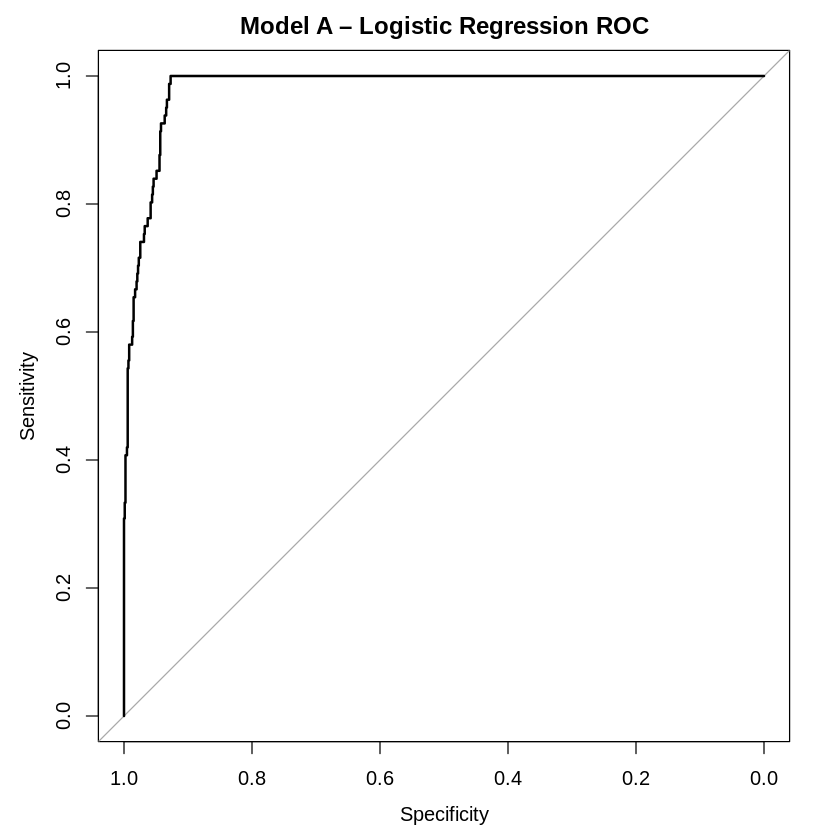

In [ ]:
logit_A <- glm(
  Thriving_bin ~ .,
  data   = train_A,
  family = binomial
)

summary(logit_A)

# Predict probabilities on test set
logit_A_prob <- predict(logit_A, newdata = test_A, type = "response")

# Classify
logit_A_pred <- ifelse(logit_A_prob > 0.5, "1", "0") %>%
  factor(levels = c("0", "1"))

# Evaluate
cm_logit_A <- confusionMatrix(logit_A_pred, test_A$Thriving_bin, positive = "1")
cm_logit_A

# ROC + AUC
roc_logit_A <- roc(response = test_A$Thriving_bin,
                   predictor = logit_A_prob,
                   levels = c("0", "1"),
                   direction = "<")

auc_logit_A <- auc(roc_logit_A)
auc_logit_A
plot(roc_logit_A, main = "Model A – Logistic Regression ROC")


This result is too good to be true. Results show that burnout, work–life balance, and social isolation are the strongest predictors of thriving. The model performs very well, with high accuracy and AUC, meaning it separates thriving and non-thriving employees effectively. Since thriving was created using these same variables, this model mainly confirms that the definition of thriving is consistent rather than fully predictive.
                                          


## Model B

In [ ]:
# Model B predictors: demographics, job context
predictors_B <- c(
  "Age",
  "Hours_Per_Week",
  "Job_Role",
  "Industry",
  "Work_Arrangement",
  "Gender",
  "Region",
  "Salary_Range",
  "Physical_Issue_Count"
)

model_B_df <- data %>%
  select(Thriving_bin, all_of(predictors_B)) %>%
  drop_na()

splits_B <- make_split(model_B_df, outcome = "Thriving_bin", p = 0.7)
train_B  <- splits_B$train
test_B   <- splits_B$test

table(train_B$Thriving_bin)



   0    1 
2020  191 


Call:
glm(formula = Thriving_bin ~ ., family = binomial, data = train_B)

Coefficients:
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                          -4.089791   0.888969  -4.601 4.21e-06 ***
Age                                  -0.007334   0.006194  -1.184  0.23639    
Hours_Per_Week                        0.015408   0.008821   1.747  0.08069 .  
Job_RoleBusiness Analyst              0.909238   0.627860   1.448  0.14757    
Job_RoleConsultant                    0.950337   0.627741   1.514  0.13005    
Job_RoleContent Writer                0.112485   0.730830   0.154  0.87768    
Job_RoleCustomer Service Manager      1.076582   0.610850   1.762  0.07800 .  
Job_RoleData Analyst                  0.681842   0.637114   1.070  0.28453    
Job_RoleData Scientist                0.637892   0.627930   1.016  0.30969    
Job_RoleDevOps Engineer               0.541753   0.627031   0.864  0.38759    
Job_RoleDigital Marketing Specialist  1.33

Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 865  81
         1   0   0
                                          
               Accuracy : 0.9144          
                 95% CI : (0.8947, 0.9314)
    No Information Rate : 0.9144          
    P-Value [Acc > NIR] : 0.5295          
                                          
                  Kappa : 0               
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.00000         
            Specificity : 1.00000         
         Pos Pred Value :     NaN         
         Neg Pred Value : 0.91438         
             Prevalence : 0.08562         
         Detection Rate : 0.00000         
   Detection Prevalence : 0.00000         
      Balanced Accuracy : 0.50000         
                                          
       'Positive' Class : 1               
                              

Area under the curve: 0.5634

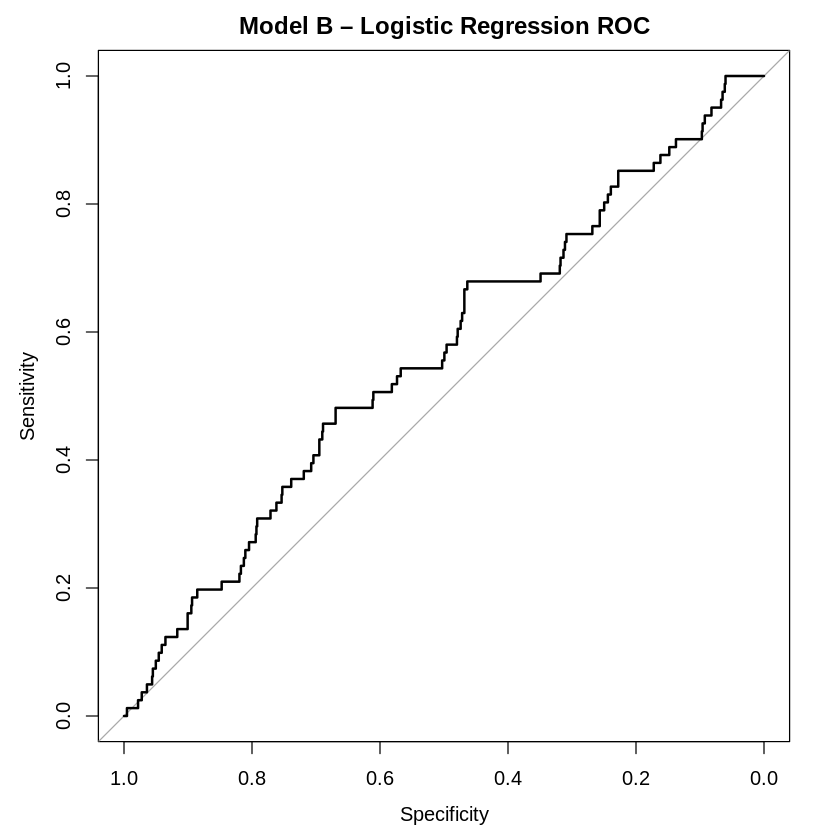

In [ ]:
# Logistic regression
logit_B <- glm(
  Thriving_bin ~ .,
  data   = train_B,
  family = binomial
)

summary(logit_B)

# Predict on test set
logit_B_prob <- predict(logit_B, newdata = test_B, type = "response")

logit_B_pred <- ifelse(logit_B_prob > 0.5, "1", "0") %>%
  factor(levels = c("0", "1"))

cm_logit_B <- confusionMatrix(logit_B_pred, test_B$Thriving_bin, positive = "1")
cm_logit_B

# ROC + AUC
roc_logit_B <- roc(test_B$Thriving_bin, logit_B_prob,
                   levels = c("0", "1"), direction = "<")
auc_logit_B <- auc(roc_logit_B)
auc_logit_B
plot(roc_logit_B, main = "Model B – Logistic Regression ROC")


Weighted Logistic Regression


Call:
glm(formula = Thriving_bin ~ ., family = binomial, data = train_B, 
    weights = ifelse(train_B$Thriving_bin == "1", 7, 1))

Coefficients:
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                          -2.008279   0.412201  -4.872 1.10e-06 ***
Age                                  -0.005130   0.002960  -1.733 0.083031 .  
Hours_Per_Week                        0.014066   0.004349   3.234 0.001220 ** 
Job_RoleBusiness Analyst              0.843505   0.284305   2.967 0.003008 ** 
Job_RoleConsultant                    0.942808   0.287997   3.274 0.001062 ** 
Job_RoleContent Writer                0.213857   0.319699   0.669 0.503538    
Job_RoleCustomer Service Manager      1.078464   0.277517   3.886 0.000102 ***
Job_RoleData Analyst                  0.682625   0.286727   2.381 0.017278 *  
Job_RoleData Scientist                0.635875   0.285433   2.228 0.025897 *  
Job_RoleDevOps Engineer               0.482875   0.280655   1.7

Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 705  60
         1 160  21
                                         
               Accuracy : 0.7674         
                 95% CI : (0.7392, 0.794)
    No Information Rate : 0.9144         
    P-Value [Acc > NIR] : 1              
                                         
                  Kappa : 0.0476         
                                         
 Mcnemar's Test P-Value : 2.479e-11      
                                         
            Sensitivity : 0.25926        
            Specificity : 0.81503        
         Pos Pred Value : 0.11602        
         Neg Pred Value : 0.92157        
             Prevalence : 0.08562        
         Detection Rate : 0.02220        
   Detection Prevalence : 0.19133        
      Balanced Accuracy : 0.53714        
                                         
       'Positive' Class : 1              
                                         

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.5631

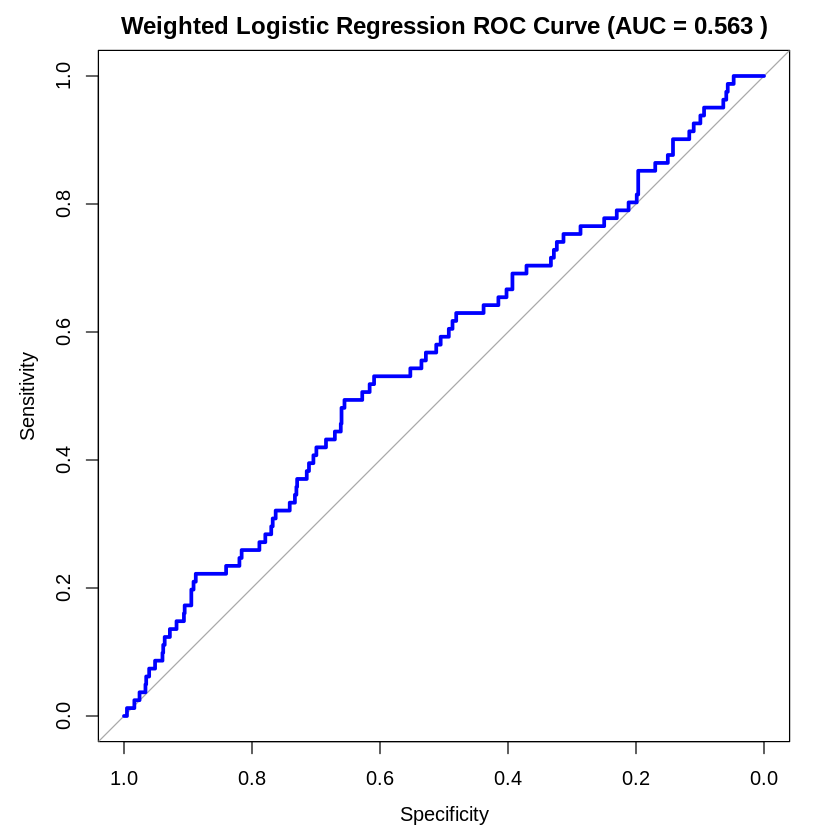

In [ ]:
logit_w2 <- glm(
  Thriving_bin ~ .,
  data=train_B,
  family=binomial,
  weights=ifelse(train_B$Thriving_bin == "1", 7, 1)
)
summary(logit_w2)


# Predictions

logit_prob_w2 <- predict(logit_w2, newdata=test_B, type="response")
logit_pred_w2 <- ifelse(logit_prob_w2 > 0.5, "1", "0") %>%
  factor(levels=c("0","1"))


# Model Evaluation

conf_matrix_w2 <- confusionMatrix(logit_pred_w2, test_B$Thriving_bin, positive="1")
conf_matrix_w2


# ROC + AUC

roc_w2 <- roc(test_B$Thriving_bin, logit_prob_w2)
auc_w2 <- auc(roc_w2); auc_w2

plot(roc_w2, col="blue", lwd=3,
     main=paste("Weighted Logistic Regression ROC Curve (AUC =", round(auc_w2,3),")"))

Even after applying class-weighted logistic regression, the model struggles to detect thriving employees.
AUC is approx 0.56 shows that thriving is not easily predictable from demographic & job-role variables.
Worklife balance, burnout score, and isolation remain the most influential factors; demographics alone are weak predictors.